In [1]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn openpyxl

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
import os

project_folder = "DABA_Return_Validation_Project"

os.makedirs(project_folder, exist_ok=True)

print("Project folder created:", project_folder)

Project folder created: DABA_Return_Validation_Project


In [4]:
import random

random.seed(42)
np.random.seed(42)

n = 500

categories = [
    "Electronics",
    "Clothing",
    "Home Appliances",
    "Beauty",
    "Footwear",
    "Furniture"
]

conditions = [
    "New",
    "Opened",
    "Used",
    "Damaged"
]

reasons = [
    "Damaged Product",
    "Wrong Product",
    "Size Issue",
    "Quality Issue",
    "Changed Mind",
    "Not Needed",
    "Defective Product",
    "Late Delivery"
]

payment_methods = [
    "UPI",
    "Credit Card",
    "Debit Card",
    "Cash on Delivery",
    "Net Banking"
]

data = []

for i in range(1, n + 1):

    category = random.choice(categories)
    condition = random.choice(conditions)
    reason = random.choice(reasons)
    payment = random.choice(payment_methods)

    days_after_delivery = random.randint(1, 30)

    product_price = random.randint(300, 50000)

    customer_rating = random.randint(1, 5)

    previous_returns = random.randint(0, 8)

    damaged = 1 if condition == "Damaged" else 0

    used = 1 if condition == "Used" else 0

    within_policy_period = 1 if days_after_delivery <= 14 else 0

    # Basic return approval logic for synthetic data
    if reason in ["Damaged Product", "Wrong Product", "Defective Product"]:
        approval_probability = 0.80
    elif within_policy_period == 1:
        approval_probability = 0.65
    else:
        approval_probability = 0.25

    if condition == "Used":
        approval_probability -= 0.20

    if condition == "Damaged":
        approval_probability += 0.10

    approval_probability = max(
        0.05,
        min(0.95, approval_probability)
    )

    approved = np.random.binomial(
        1,
        approval_probability
    )

    data.append([
        i,
        category,
        days_after_delivery,
        condition,
        reason,
        payment,
        product_price,
        customer_rating,
        previous_returns,
        within_policy_period,
        approved
    ])

columns = [
    "return_id",
    "product_category",
    "days_after_delivery",
    "product_condition",
    "return_reason",
    "payment_method",
    "product_price",
    "customer_rating",
    "previous_returns",
    "within_policy_period",
    "return_approved"
]

df = pd.DataFrame(
    data,
    columns=columns
)

print("Dataset created successfully!")
print("Number of records:", len(df))

Dataset created successfully!
Number of records: 500


In [5]:
df.head(10)

,return_id,product_category,days_after_delivery,product_condition,return_reason,payment_method,product_price,customer_rating,previous_returns,within_policy_period,return_approved
0,1,Furniture,8,New,Damaged Product,Debit Card,14928,2,1,1,1
1,2,Furniture,1,New,Defective Product,UPI,6440,2,3,1,0
2,3,Footwear,14,New,Quality Issue,Net Banking,14746,4,4,1,0
3,4,Electronics,9,Opened,Defective Product,Debit Card,10489,2,5,1,1
4,5,Electronics,12,New,Defective Product,UPI,22841,5,4,1,1
5,6,Electronics,3,Damaged,Wrong Product,Cash on Delivery,36478,3,5,1,1
6,7,Footwear,22,Opened,Wrong Product,UPI,15235,3,1,0,1
7,8,Clothing,15,New,Defective Product,Debit Card,41960,3,2,0,0
8,9,Home Appliances,23,Used,Quality Issue,Debit Card,45096,1,2,0,0
9,10,Footwear,13,Opened,Size Issue,Cash on Delivery,17991,5,3,1,0


In [6]:
excel_path = "return_dataset.xlsx"

df.to_excel(
    excel_path,
    index=False
)

print("Excel file created successfully!")

Excel file created successfully!


In [7]:
from google.colab import files

files.download("return_dataset.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 500
Columns: 11


In [9]:
print(df.columns.tolist())

['return_id', 'product_category', 'days_after_delivery', 'product_condition', 'return_reason', 'payment_method', 'product_price', 'customer_rating', 'previous_returns', 'within_policy_period', 'return_approved']


In [10]:
missing_values = df.isnull().sum()

print(missing_values)

return_id               0
product_category        0
days_after_delivery     0
product_condition       0
return_reason           0
payment_method          0
product_price           0
customer_rating         0
previous_returns        0
within_policy_period    0
return_approved         0
dtype: int64


In [11]:
duplicates = df.duplicated().sum()

print("Duplicate records:", duplicates)

Duplicate records: 0


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   return_id             500 non-null    int64 
 1   product_category      500 non-null    object
 2   days_after_delivery   500 non-null    int64 
 3   product_condition     500 non-null    object
 4   return_reason         500 non-null    object
 5   payment_method        500 non-null    object
 6   product_price         500 non-null    int64 
 7   customer_rating       500 non-null    int64 
 8   previous_returns      500 non-null    int64 
 9   within_policy_period  500 non-null    int64 
 10  return_approved       500 non-null    int64 
dtypes: int64(7), object(4)
memory usage: 43.1+ KB


In [13]:
df.describe()

,return_id,days_after_delivery,product_price,customer_rating,previous_returns,within_policy_period,return_approved
count,500.000000,500.00000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,250.500000,15.25400,25514.122000,3.060000,3.958000,0.472000,0.558000
std,144.481833,8.73373,14511.906457,1.382832,2.489303,0.499715,0.497122
min,1.000000,1.00000,326.000000,1.000000,0.000000,0.000000,0.000000
25%,125.750000,8.00000,13317.250000,2.000000,2.000000,0.000000,0.000000
50%,250.500000,15.00000,26055.500000,3.000000,4.000000,0.000000,1.000000
75%,375.250000,23.00000,38546.750000,4.000000,6.000000,1.000000,1.000000
max,500.000000,30.00000,49762.000000,5.000000,8.000000,1.000000,1.000000


In [14]:
category_analysis = df.groupby(
    "product_category"
).agg(
    total_requests=("return_id", "count"),
    approved_returns=("return_approved", "sum"),
    average_price=("product_price", "mean"),
    average_previous_returns=("previous_returns", "mean")
)

category_analysis["approval_rate"] = (
    category_analysis["approved_returns"]
    / category_analysis["total_requests"]
    * 100
)

category_analysis = category_analysis.sort_values(
    "approval_rate",
    ascending=False
)

category_analysis

,total_requests,approved_returns,average_price,average_previous_returns,approval_rate
product_category,,,,,
Furniture,77,52,26825.662338,3.831169,67.532468
Electronics,93,52,24293.720430,3.978495,55.913978
Beauty,77,43,26163.610390,3.948052,55.844156
Home Appliances,84,46,25464.857143,4.000000,54.761905
Footwear,86,47,25290.162791,3.569767,54.651163
Clothing,83,39,25344.204819,4.421687,46.987952


In [15]:
category_counts = df[
    "product_category"
].value_counts()

print(category_counts)

product_category
Electronics        93
Footwear           86
Home Appliances    84
Clothing           83
Furniture          77
Beauty             77
Name: count, dtype: int64


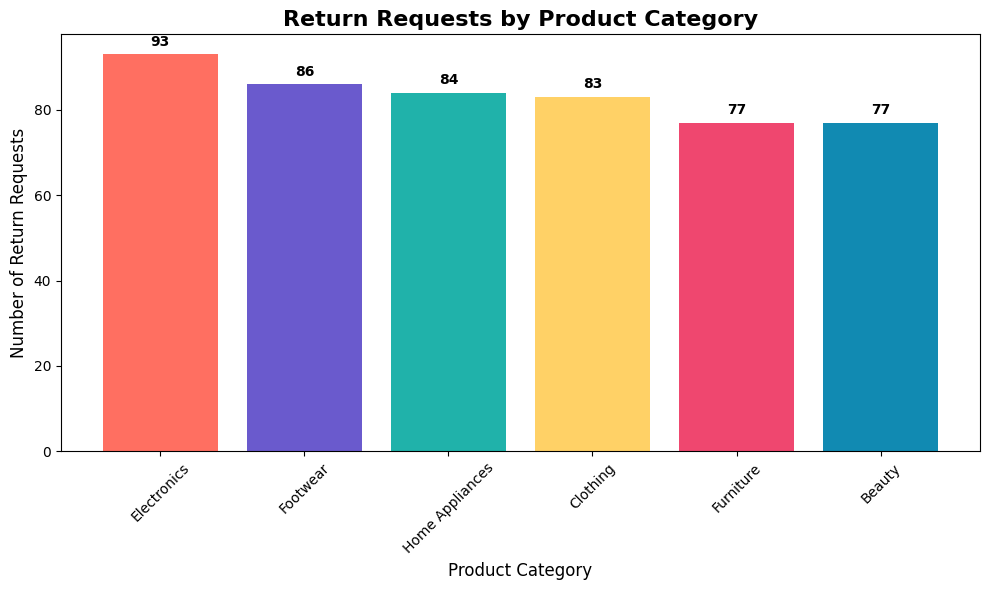

In [16]:
plt.figure(figsize=(10, 6))

category_counts = df["product_category"].value_counts()

bars = plt.bar(
    category_counts.index,
    category_counts.values,
    color=["#FF6F61", "#6A5ACD", "#20B2AA", "#FFD166", "#EF476F", "#118AB2"]
)

plt.title("Return Requests by Product Category", fontsize=16, fontweight="bold")
plt.xlabel("Product Category", fontsize=12)
plt.ylabel("Number of Return Requests", fontsize=12)

plt.xticks(rotation=45)

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 2,
        str(int(height)),
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

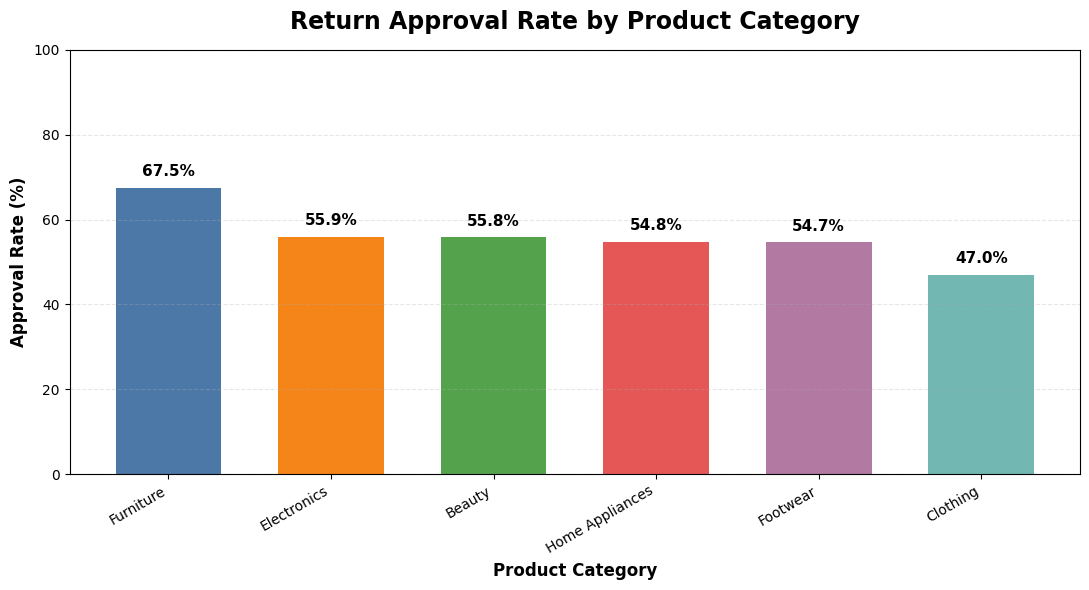

In [17]:
plt.figure(figsize=(11, 6))

bars = plt.bar(
    category_analysis.index,
    category_analysis["approval_rate"],
    color=[
        "#4C78A8",
        "#F58518",
        "#54A24B",
        "#E45756",
        "#B279A2",
        "#72B7B2"
    ],
    width=0.65
)

plt.title(
    "Return Approval Rate by Product Category",
    fontsize=17,
    fontweight="bold",
    pad=15
)

plt.xlabel("Product Category", fontsize=12, fontweight="bold")
plt.ylabel("Approval Rate (%)", fontsize=12, fontweight="bold")

plt.xticks(rotation=30, ha="right")
plt.ylim(0, 100)

# Percentage value on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 2,
        f"{height:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

# Professional grid
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [18]:
reason_analysis = df[
    "return_reason"
].value_counts()

print(reason_analysis)

return_reason
Defective Product    81
Size Issue           72
Wrong Product        69
Not Needed           62
Damaged Product      60
Quality Issue        55
Late Delivery        54
Changed Mind         47
Name: count, dtype: int64


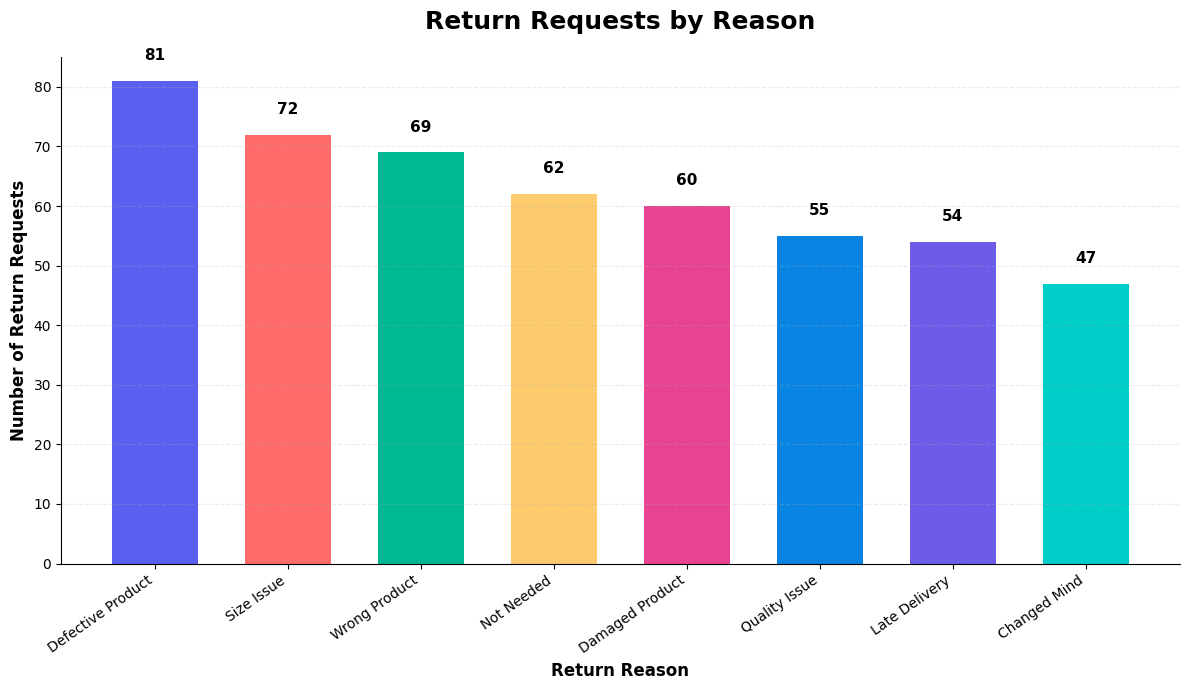

In [20]:
import matplotlib.pyplot as plt

# Count return requests by reason
reason_counts = df["return_reason"].value_counts()

plt.figure(figsize=(12, 7))

bars = plt.bar(
    reason_counts.index,
    reason_counts.values,
    width=0.65,
    color=[
        "#5B5FEF",
        "#FF6B6B",
        "#00B894",
        "#FDCB6E",
        "#E84393",
        "#0984E3",
        "#6C5CE7",
        "#00CEC9"
    ]
)

# Professional title
plt.title(
    "Return Requests by Reason",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.xlabel(
    "Return Reason",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Number of Return Requests",
    fontsize=12,
    fontweight="bold"
)

# Rotate category names
plt.xticks(
    rotation=35,
    ha="right",
    fontsize=10
)

# Show values on top of bars
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 3,
        str(int(height)),
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

# Clean grid
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

# Remove unnecessary borders
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [21]:
condition_analysis = df.groupby(
    "product_condition"
).agg(
    total_requests=("return_id", "count"),
    approved_returns=("return_approved", "sum")
)

condition_analysis["approval_rate"] = (
    condition_analysis["approved_returns"]
    / condition_analysis["total_requests"]
    * 100
)

condition_analysis

,total_requests,approved_returns,approval_rate
product_condition,,,
Damaged,133,92,69.172932
New,108,70,64.814815
Opened,125,61,48.800000
Used,134,56,41.791045


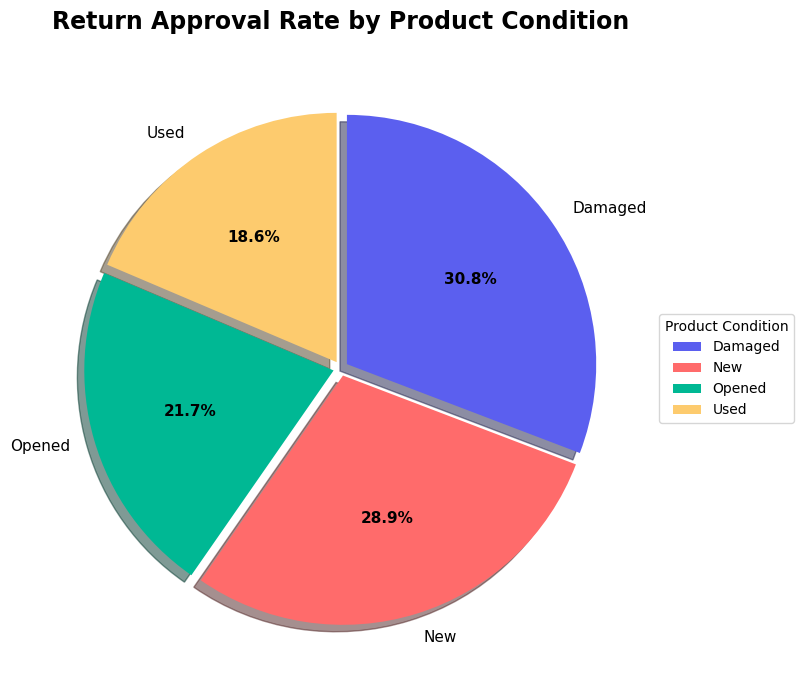

In [22]:
import matplotlib.pyplot as plt

# Approval rate by product condition
condition_data = df.groupby("product_condition")["return_approved"].mean() * 100

plt.figure(figsize=(9, 7))

colors = [
    "#5B5FEF",
    "#FF6B6B",
    "#00B894",
    "#FDCB6E"
]

wedges, texts, autotexts = plt.pie(
    condition_data.values,
    labels=condition_data.index,
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False,
    explode=[0.03] * len(condition_data),
    shadow=True,
    textprops={"fontsize": 11}
)

# Percentage text styling
for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_fontweight("bold")

plt.title(
    "Return Approval Rate by Product Condition",
    fontsize=17,
    fontweight="bold",
    pad=20
)

plt.legend(
    wedges,
    condition_data.index,
    title="Product Condition",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.tight_layout()
plt.show()

In [23]:
policy_analysis = df.groupby(
    "within_policy_period"
).agg(
    total_requests=("return_id", "count"),
    approved_returns=("return_approved", "sum")
)

policy_analysis["approval_rate"] = (
    policy_analysis["approved_returns"]
    / policy_analysis["total_requests"]
    * 100
)

policy_analysis

,total_requests,approved_returns,approval_rate
within_policy_period,,,
0,264,118,44.696970
1,236,161,68.220339


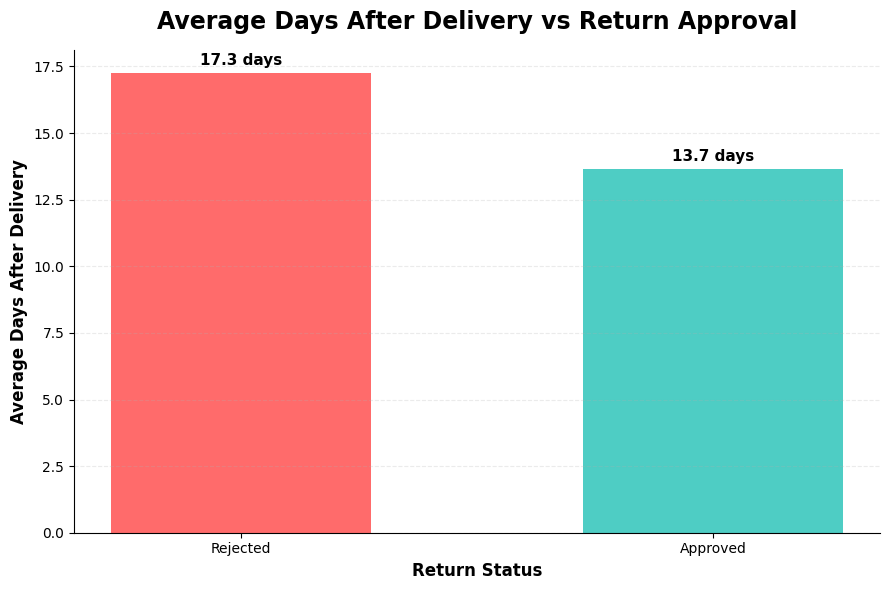

In [24]:
import matplotlib.pyplot as plt

# Average days after delivery for approved and rejected returns
approval_days = df.groupby("return_approved")["days_after_delivery"].mean()

# Change 0 and 1 into readable names
labels = ["Rejected", "Approved"]

plt.figure(figsize=(9, 6))

bars = plt.bar(
    labels,
    approval_days.values,
    color=["#FF6B6B", "#4ECDC4"],
    width=0.55
)

plt.title(
    "Average Days After Delivery vs Return Approval",
    fontsize=17,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Return Status",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Average Days After Delivery",
    fontsize=12,
    fontweight="bold"
)

# Show values on bars
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.3,
        f"{height:.1f} days",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [25]:
previous_return_analysis = df.groupby(
    "previous_returns"
)["return_approved"].mean() * 100

previous_return_analysis

,return_approved
previous_returns,
0,50.000000
1,54.166667
2,54.237288
3,61.016949
4,53.125000
5,54.098361
6,63.793103
7,59.183673
8,52.083333


In [26]:
numeric_df = df[
    [
        "days_after_delivery",
        "product_price",
        "customer_rating",
        "previous_returns",
        "within_policy_period",
        "return_approved"
    ]
]

correlation = numeric_df.corr()

correlation

,days_after_delivery,product_price,customer_rating,previous_returns,within_policy_period,return_approved
days_after_delivery,1.000000,0.060053,0.017818,-0.065968,-0.860466,-0.204875
product_price,0.060053,1.000000,0.053803,0.039276,-0.025616,-0.025825
customer_rating,0.017818,0.053803,1.000000,0.065355,-0.017864,-0.031309
previous_returns,-0.065968,0.039276,0.065355,1.000000,0.049800,0.031932
within_policy_period,-0.860466,-0.025616,-0.017864,0.049800,1.000000,0.236461
return_approved,-0.204875,-0.025825,-0.031309,0.031932,0.236461,1.000000


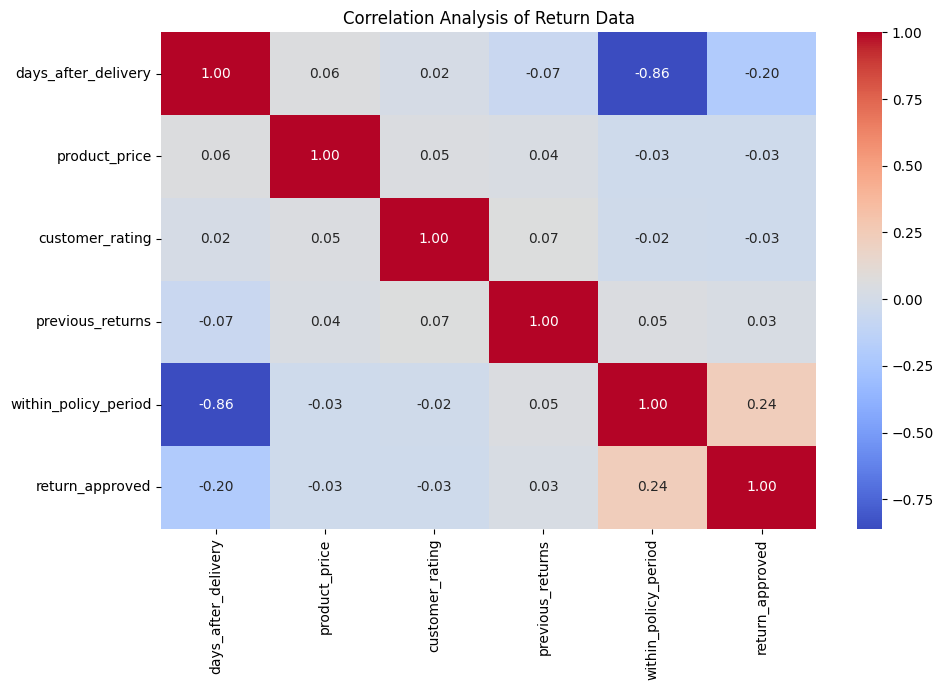

In [27]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title(
    "Correlation Analysis of Return Data"
)

plt.tight_layout()

plt.show()

In [28]:
def calculate_risk_score(row):

    score = 0

    # Days after delivery
    if row["days_after_delivery"] > 14:
        score += 40
    elif row["days_after_delivery"] > 10:
        score += 20

    # Product condition
    if row["product_condition"] == "Used":
        score += 30

    elif row["product_condition"] == "Opened":
        score += 15

    elif row["product_condition"] == "Damaged":
        score += 5

    # Previous returns
    if row["previous_returns"] >= 5:
        score += 20

    elif row["previous_returns"] >= 3:
        score += 10

    # Customer rating
    if row["customer_rating"] <= 2:
        score += 10

    return min(score, 100)

In [29]:
df["risk_score"] = df.apply(
    calculate_risk_score,
    axis=1
)

df.head()

,return_id,product_category,days_after_delivery,product_condition,return_reason,payment_method,product_price,customer_rating,previous_returns,within_policy_period,return_approved,risk_score
0,1,Furniture,8,New,Damaged Product,Debit Card,14928,2,1,1,1,10
1,2,Furniture,1,New,Defective Product,UPI,6440,2,3,1,0,20
2,3,Footwear,14,New,Quality Issue,Net Banking,14746,4,4,1,0,30
3,4,Electronics,9,Opened,Defective Product,Debit Card,10489,2,5,1,1,45
4,5,Electronics,12,New,Defective Product,UPI,22841,5,4,1,1,30


In [30]:
def risk_level(score):

    if score < 30:
        return "LOW"

    elif score < 60:
        return "MEDIUM"

    else:
        return "HIGH"

In [31]:
df["risk_level"] = df[
    "risk_score"
].apply(risk_level)

df.head(10)

,return_id,product_category,days_after_delivery,product_condition,return_reason,payment_method,product_price,customer_rating,previous_returns,within_policy_period,return_approved,risk_score,risk_level
0,1,Furniture,8,New,Damaged Product,Debit Card,14928,2,1,1,1,10,LOW
1,2,Furniture,1,New,Defective Product,UPI,6440,2,3,1,0,20,LOW
2,3,Footwear,14,New,Quality Issue,Net Banking,14746,4,4,1,0,30,MEDIUM
3,4,Electronics,9,Opened,Defective Product,Debit Card,10489,2,5,1,1,45,MEDIUM
4,5,Electronics,12,New,Defective Product,UPI,22841,5,4,1,1,30,MEDIUM
5,6,Electronics,3,Damaged,Wrong Product,Cash on Delivery,36478,3,5,1,1,25,LOW
6,7,Footwear,22,Opened,Wrong Product,UPI,15235,3,1,0,1,55,MEDIUM
7,8,Clothing,15,New,Defective Product,Debit Card,41960,3,2,0,0,40,MEDIUM
8,9,Home Appliances,23,Used,Quality Issue,Debit Card,45096,1,2,0,0,80,HIGH
9,10,Footwear,13,Opened,Size Issue,Cash on Delivery,17991,5,3,1,0,45,MEDIUM


In [32]:
risk_distribution = df[
    "risk_level"
].value_counts()

print(risk_distribution)

risk_level
HIGH      212
MEDIUM    185
LOW       103
Name: count, dtype: int64


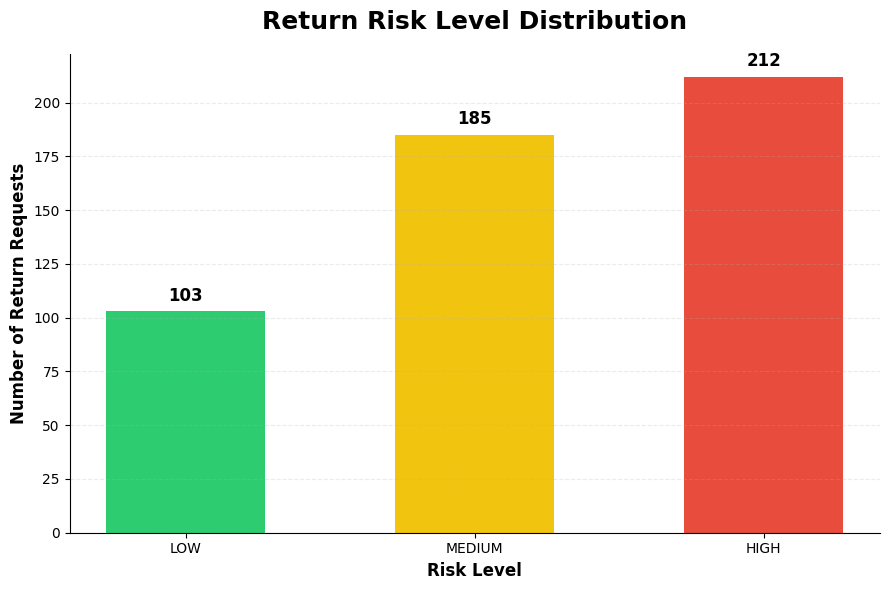

In [33]:
import matplotlib.pyplot as plt

# Count each risk level
risk_distribution = df["risk_level"].value_counts()

# Keep the order: LOW, MEDIUM, HIGH
risk_distribution = risk_distribution.reindex(
    ["LOW", "MEDIUM", "HIGH"]
)

plt.figure(figsize=(9, 6))

bars = plt.bar(
    risk_distribution.index,
    risk_distribution.values,
    width=0.55,
    color=["#2ECC71", "#F1C40F", "#E74C3C"]
)

plt.title(
    "Return Risk Level Distribution",
    fontsize=18,
    fontweight="bold",
    pad=18
)

plt.xlabel(
    "Risk Level",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Number of Return Requests",
    fontsize=12,
    fontweight="bold"
)

# Display number on top of each bar
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 3,
        str(int(height)),
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

# Clean professional grid
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

# Remove unnecessary borders
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [34]:
high_risk_analysis = df.groupby(
    "product_category"
).agg(
    total_requests=("return_id", "count"),
    average_risk_score=("risk_score", "mean"),
    high_risk_cases=(
        "risk_level",
        lambda x: (x == "HIGH").sum()
    )
)

high_risk_analysis[
    "high_risk_percentage"
] = (
    high_risk_analysis["high_risk_cases"]
    / high_risk_analysis["total_requests"]
    * 100
)

high_risk_analysis = high_risk_analysis.sort_values(
    "high_risk_percentage",
    ascending=False
)

high_risk_analysis

,total_requests,average_risk_score,high_risk_cases,high_risk_percentage
product_category,,,,
Electronics,93,52.956989,42,45.161290
Clothing,83,52.409639,37,44.578313
Beauty,77,53.961039,34,44.155844
Home Appliances,84,50.773810,36,42.857143
Furniture,77,50.584416,31,40.259740
Footwear,86,48.953488,32,37.209302


In [35]:
top_risk_category = high_risk_analysis.index[0]

print(
    "Highest High-Risk Category:",
    top_risk_category
)

Highest High-Risk Category: Electronics


In [36]:
dataset_path = (
    f"{project_folder}/return_dataset.csv"
)

df.to_csv(
    dataset_path,
    index=False
)

print(
    "Dataset saved at:",
    dataset_path
)

Dataset saved at: DABA_Return_Validation_Project/return_dataset.csv


In [37]:
analysis_path = (
    f"{project_folder}/category_risk_analysis.csv"
)

high_risk_analysis.to_csv(
    analysis_path
)

print(
    "Risk analysis saved at:",
    analysis_path
)

Risk analysis saved at: DABA_Return_Validation_Project/category_risk_analysis.csv


In [38]:
from google.colab import files

files.download(
    dataset_path
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [39]:
print("=" * 65)
print("        DABA PROJECT - DAY 1 SUMMARY")
print("=" * 65)

print("\nProject:")
print("Explainable LLM-Based Return Validation and Risk Assessment")

print("\nDataset Information")
print("-" * 65)

print("Total Return Records       :", len(df))

print(
    "Product Categories         :",
    df["product_category"].nunique()
)

print(
    "Return Reasons             :",
    df["return_reason"].nunique()
)

print(
    "Risk Levels                :",
    df["risk_level"].nunique()
)

print("\nRisk Distribution")
print("-" * 65)

risk_counts = df["risk_level"].value_counts()

for level in ["LOW", "MEDIUM", "HIGH"]:
    print(f"{level:<12} : {risk_counts.get(level, 0)} cases")

print("\nHighest High-Risk Category")
print("-" * 65)

print("Category:", top_risk_category)

print("\nDay 1 Outcome")
print("-" * 65)

print("✓ Dataset created")
print("✓ Exploratory Data Analysis completed")
print("✓ Risk score calculated")
print("✓ Risk levels assigned")
print("✓ High-risk category identified")

print("\n" + "=" * 65)
print("        DAY 1 COMPLETED SUCCESSFULLY!")
print("=" * 65)

        DABA PROJECT - DAY 1 SUMMARY

Project:
Explainable LLM-Based Return Validation and Risk Assessment

Dataset Information
-----------------------------------------------------------------
Total Return Records       : 500
Product Categories         : 6
Return Reasons             : 8
Risk Levels                : 3

Risk Distribution
-----------------------------------------------------------------
LOW          : 103 cases
MEDIUM       : 185 cases
HIGH         : 212 cases

Highest High-Risk Category
-----------------------------------------------------------------
Category: Electronics

Day 1 Outcome
-----------------------------------------------------------------
✓ Dataset created
✓ Exploratory Data Analysis completed
✓ Risk score calculated
✓ Risk levels assigned
✓ High-risk category identified

        DAY 1 COMPLETED SUCCESSFULLY!


In [40]:
print("=" * 70)
print("DAY 2 - RETURN RISK ANALYSIS & LLM WORKFLOW")
print("=" * 70)

print("\nProject:")
print("An Explainable LLM-Based Return Validation and Risk Assessment System Using RAG")

print("\nDay 2 Objective:")
print("Analyze return risk patterns and design the LLM validation workflow.")

DAY 2 - RETURN RISK ANALYSIS & LLM WORKFLOW

Project:
An Explainable LLM-Based Return Validation and Risk Assessment System Using RAG

Day 2 Objective:
Analyze return risk patterns and design the LLM validation workflow.


In [41]:
print("Dataset Shape:", df.shape)

print("\nRisk Level Counts:")
print(df["risk_level"].value_counts())

print("\nRisk Score Summary:")
print(df["risk_score"].describe())

print("\nProduct Categories:")
print(df["product_category"].unique())

Dataset Shape: (500, 13)

Risk Level Counts:
risk_level
HIGH      212
MEDIUM    185
LOW       103
Name: count, dtype: int64

Risk Score Summary:
count    500.000000
mean      51.600000
std       23.669823
min        0.000000
25%       35.000000
50%       55.000000
75%       70.000000
max      100.000000
Name: risk_score, dtype: float64

Product Categories:
['Furniture' 'Footwear' 'Electronics' 'Clothing' 'Home Appliances'
 'Beauty']


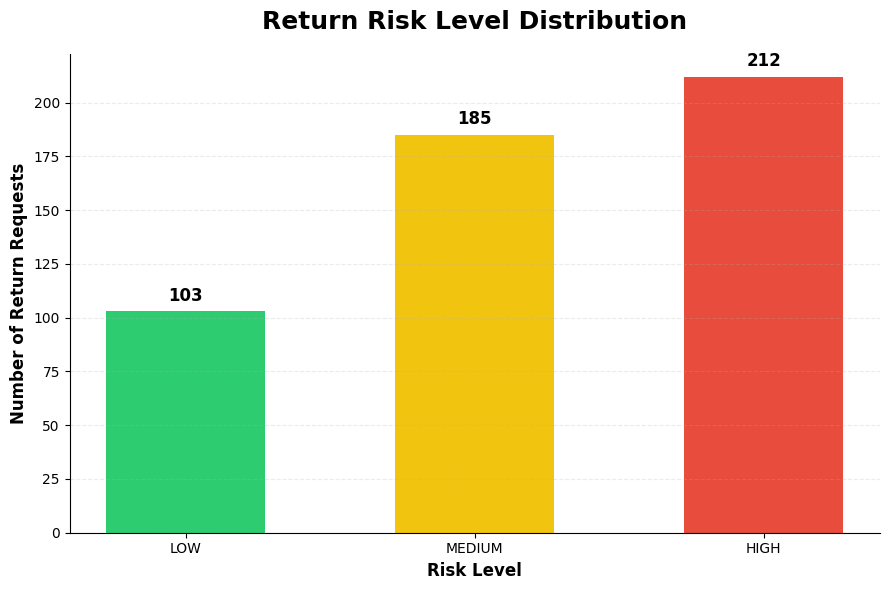

In [42]:
import matplotlib.pyplot as plt

risk_counts = df["risk_level"].value_counts()

risk_counts = risk_counts.reindex(
    ["LOW", "MEDIUM", "HIGH"]
)

plt.figure(figsize=(9, 6))

bars = plt.bar(
    risk_counts.index,
    risk_counts.values,
    width=0.55,
    color=[
        "#2ECC71",   # Green - Low
        "#F1C40F",   # Yellow - Medium
        "#E74C3C"    # Red - High
    ]
)

plt.title(
    "Return Risk Level Distribution",
    fontsize=18,
    fontweight="bold",
    pad=18
)

plt.xlabel(
    "Risk Level",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Number of Return Requests",
    fontsize=12,
    fontweight="bold"
)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 3,
        str(int(height)),
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

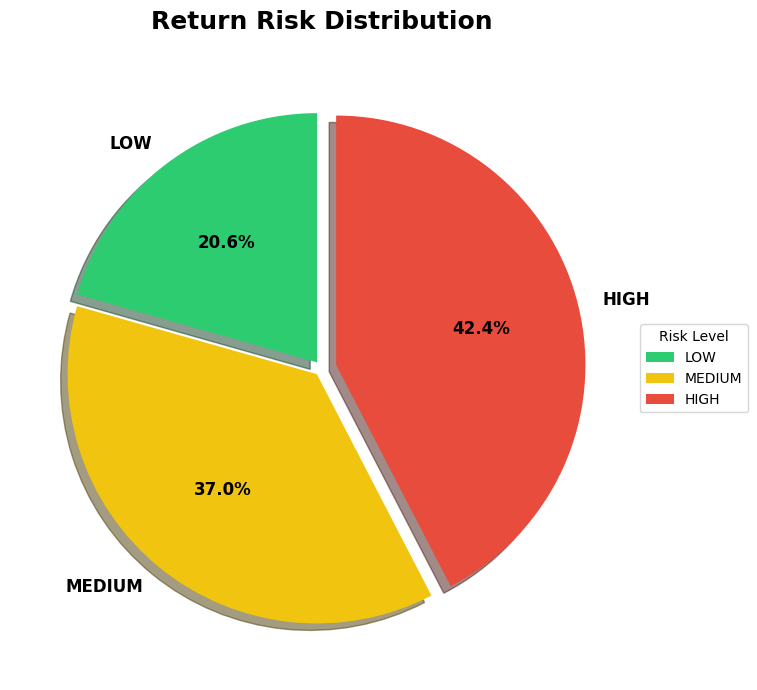

In [43]:
plt.figure(figsize=(9, 7))

colors = [
    "#2ECC71",
    "#F1C40F",
    "#E74C3C"
]

explode = [0.03, 0.03, 0.06]

plt.pie(
    risk_counts.values,
    labels=risk_counts.index,
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
    explode=explode,
    shadow=True,
    textprops={
        "fontsize": 12,
        "fontweight": "bold"
    }
)

plt.title(
    "Return Risk Distribution",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.legend(
    risk_counts.index,
    title="Risk Level",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.tight_layout()
plt.show()

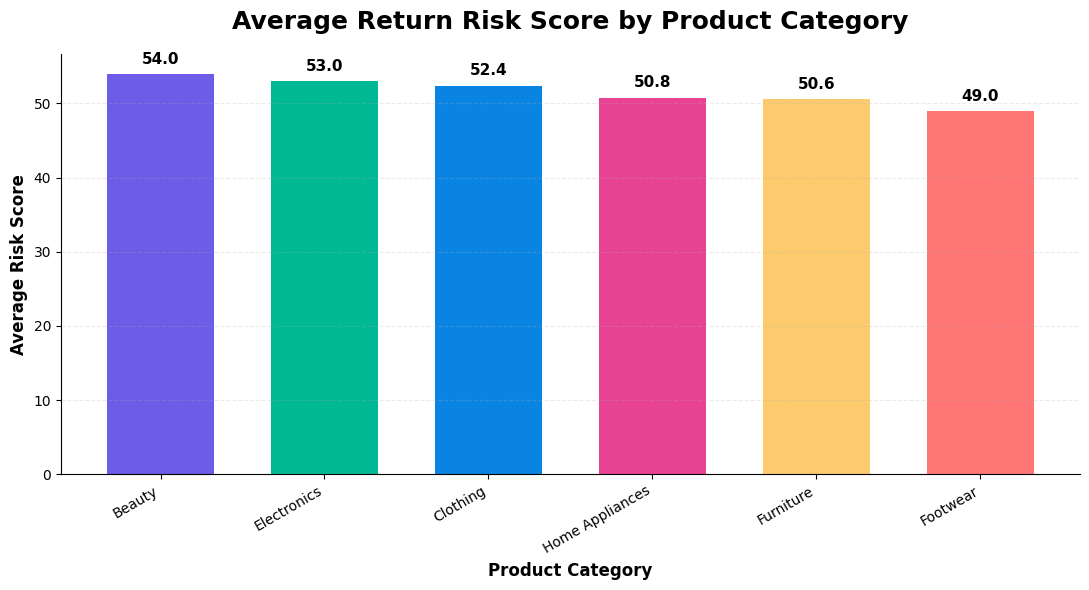

In [44]:
category_risk = (
    df.groupby("product_category")["risk_score"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(11, 6))

bars = plt.bar(
    category_risk.index,
    category_risk.values,
    width=0.65,
    color=[
        "#6C5CE7",
        "#00B894",
        "#0984E3",
        "#E84393",
        "#FDCB6E",
        "#FF7675"
    ]
)

plt.title(
    "Average Return Risk Score by Product Category",
    fontsize=18,
    fontweight="bold",
    pad=18
)

plt.xlabel(
    "Product Category",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Average Risk Score",
    fontsize=12,
    fontweight="bold"
)

plt.xticks(
    rotation=30,
    ha="right"
)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f"{height:.1f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [45]:
risk_category = pd.crosstab(
    df["product_category"],
    df["risk_level"]
)

risk_category = risk_category[
    ["LOW", "MEDIUM", "HIGH"]
]

risk_category

risk_level,LOW,MEDIUM,HIGH
product_category,,,
Beauty,15,28,34
Clothing,17,29,37
Electronics,16,35,42
Footwear,16,38,32
Furniture,18,28,31
Home Appliances,21,27,36


<Figure size 1200x700 with 0 Axes>

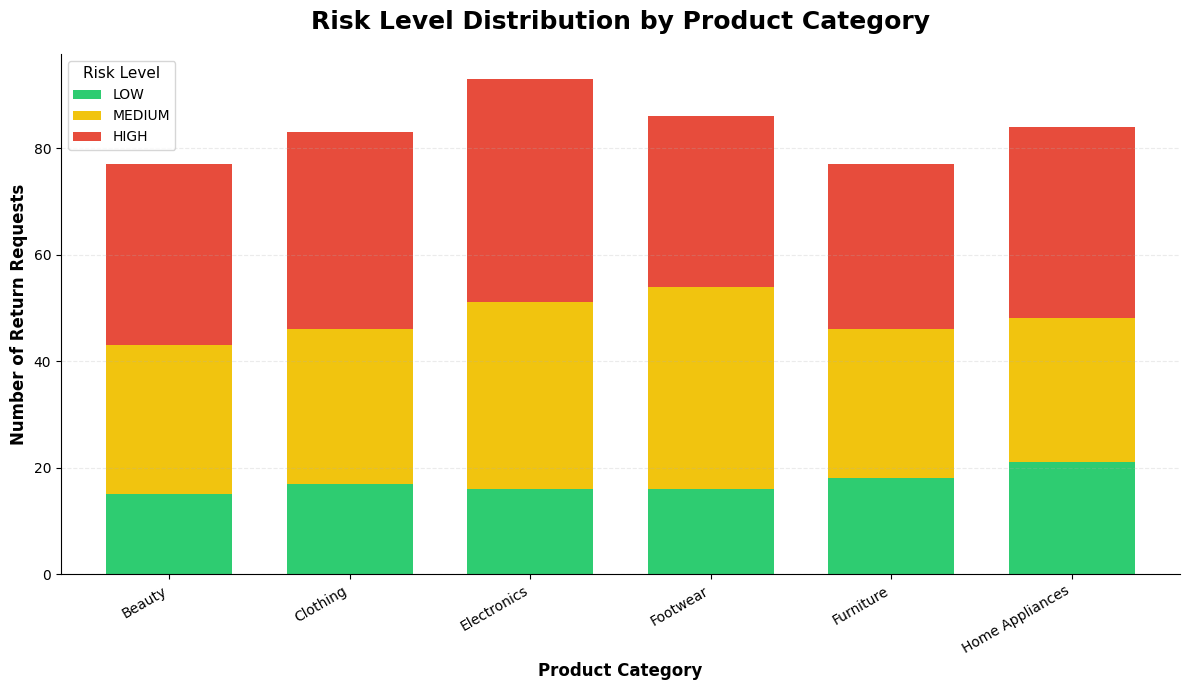

In [46]:
plt.figure(figsize=(12, 7))

risk_category.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 7),
    color=[
        "#2ECC71",
        "#F1C40F",
        "#E74C3C"
    ],
    width=0.7
)

plt.title(
    "Risk Level Distribution by Product Category",
    fontsize=18,
    fontweight="bold",
    pad=18
)

plt.xlabel(
    "Product Category",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Number of Return Requests",
    fontsize=12,
    fontweight="bold"
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.legend(
    title="Risk Level",
    title_fontsize=11
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [47]:
high_risk_summary = (
    df.groupby("product_category")
    .agg(
        total_requests=("return_id", "count"),
        average_risk_score=("risk_score", "mean"),
        high_risk_cases=(
            "risk_level",
            lambda x: (x == "HIGH").sum()
        )
    )
)

high_risk_summary["high_risk_percentage"] = (
    high_risk_summary["high_risk_cases"]
    / high_risk_summary["total_requests"]
    * 100
)

high_risk_summary = high_risk_summary.sort_values(
    "high_risk_percentage",
    ascending=False
)

high_risk_summary

,total_requests,average_risk_score,high_risk_cases,high_risk_percentage
product_category,,,,
Electronics,93,52.956989,42,45.161290
Clothing,83,52.409639,37,44.578313
Beauty,77,53.961039,34,44.155844
Home Appliances,84,50.773810,36,42.857143
Furniture,77,50.584416,31,40.259740
Footwear,86,48.953488,32,37.209302


In [48]:
top_risk_category = high_risk_summary.index[0]

print("Highest High-Risk Category:", top_risk_category)

Highest High-Risk Category: Electronics


In [49]:
return_request_example = {
    "product_category": "Electronics",
    "days_after_delivery": 10,
    "product_condition": "Opened",
    "return_reason": "Defective Product",
    "product_price": 25000,
    "customer_rating": 4,
    "previous_returns": 1,
    "within_policy_period": True
}

return_request_example

{'product_category': 'Electronics',
 'days_after_delivery': 10,
 'product_condition': 'Opened',
 'return_reason': 'Defective Product',
 'product_price': 25000,
 'customer_rating': 4,
 'previous_returns': 1,
 'within_policy_period': True}

In [50]:
def preliminary_decision(risk_score, within_policy_period):

    if not within_policy_period:
        return "REVIEW"

    if risk_score >= 60:
        return "REVIEW"

    elif risk_score >= 30:
        return "REVIEW"

    else:
        return "PENDING_LLM_VALIDATION"

In [51]:
print(preliminary_decision(20, True))
print(preliminary_decision(70, True))
print(preliminary_decision(40, False))

PENDING_LLM_VALIDATION
REVIEW
REVIEW


In [52]:
print("=" * 70)
print("             DABA PROJECT - DAY 2 SUMMARY")
print("=" * 70)

print("\nDay 2 Completed Tasks")
print("-" * 70)

print("✓ Risk level distribution analyzed")
print("✓ Risk distribution visualized")
print("✓ Product category risk scores analyzed")
print("✓ High-risk categories identified")
print("✓ Risk level by category analyzed")
print("✓ LLM validation workflow designed")
print("✓ Future UI input structure defined")
print("✓ Preliminary decision workflow defined")

print("\nProject Architecture")
print("-" * 70)

print("Return Request")
print("      ↓")
print("Risk Analysis")
print("      ↓")
print("Policy Retrieval")
print("      ↓")
print("LLM Validation")
print("      ↓")
print("Final Decision + Explanation")

print("\nDAY 2 COMPLETED SUCCESSFULLY!")
print("=" * 70)

             DABA PROJECT - DAY 2 SUMMARY

Day 2 Completed Tasks
----------------------------------------------------------------------
✓ Risk level distribution analyzed
✓ Risk distribution visualized
✓ Product category risk scores analyzed
✓ High-risk categories identified
✓ Risk level by category analyzed
✓ LLM validation workflow designed
✓ Future UI input structure defined
✓ Preliminary decision workflow defined

Project Architecture
----------------------------------------------------------------------
Return Request
      ↓
Risk Analysis
      ↓
Policy Retrieval
      ↓
LLM Validation
      ↓
Final Decision + Explanation

DAY 2 COMPLETED SUCCESSFULLY!


In [53]:
print("=" * 70)
print("DAY 3 - LLM INTEGRATION WITH RETURN RISK ANALYSIS")
print("=" * 70)

print("\nProject:")
print("An Explainable LLM-Based Return Validation and Risk Assessment System Using RAG")

print("\nDay 3 Objective:")
print("Integrate return risk information with an LLM-based validation workflow.")

DAY 3 - LLM INTEGRATION WITH RETURN RISK ANALYSIS

Project:
An Explainable LLM-Based Return Validation and Risk Assessment System Using RAG

Day 3 Objective:
Integrate return risk information with an LLM-based validation workflow.


In [54]:
required_columns = [
    "return_id",
    "product_category",
    "days_after_delivery",
    "product_condition",
    "return_reason",
    "product_price",
    "customer_rating",
    "previous_returns",
    "within_policy_period",
    "risk_score",
    "risk_level"
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if len(missing_columns) == 0:
    print("✓ Day 1 and Day 2 data are available.")
    print("✓ Ready for Day 3 LLM integration.")
else:
    print("Missing columns:", missing_columns)

✓ Day 1 and Day 2 data are available.
✓ Ready for Day 3 LLM integration.


In [55]:
sample_return = df.iloc[0]

print("Sample Return Request")
print("-" * 50)

print("Return ID              :", sample_return["return_id"])
print("Product Category       :", sample_return["product_category"])
print("Days After Delivery    :", sample_return["days_after_delivery"])
print("Product Condition     :", sample_return["product_condition"])
print("Return Reason          :", sample_return["return_reason"])
print("Product Price          :", sample_return["product_price"])
print("Customer Rating        :", sample_return["customer_rating"])
print("Previous Returns       :", sample_return["previous_returns"])
print("Within Policy Period   :", sample_return["within_policy_period"])
print("Risk Score             :", sample_return["risk_score"])
print("Risk Level             :", sample_return["risk_level"])

Sample Return Request
--------------------------------------------------
Return ID              : 1
Product Category       : Furniture
Days After Delivery    : 8
Product Condition     : New
Return Reason          : Damaged Product
Product Price          : 14928
Customer Rating        : 2
Previous Returns       : 1
Within Policy Period   : 1
Risk Score             : 10
Risk Level             : LOW


In [56]:
def create_return_context(row):

    context = f"""
Customer Return Request

Product Category: {row['product_category']}
Days After Delivery: {row['days_after_delivery']}
Product Condition: {row['product_condition']}
Return Reason: {row['return_reason']}
Product Price: {row['product_price']}
Customer Rating: {row['customer_rating']}
Previous Returns: {row['previous_returns']}
Within Policy Period: {row['within_policy_period']}

Risk Score: {row['risk_score']}
Risk Level: {row['risk_level']}
"""

    return context.strip()


return_context = create_return_context(sample_return)

print(return_context)

Customer Return Request

Product Category: Furniture
Days After Delivery: 8
Product Condition: New
Return Reason: Damaged Product
Product Price: 14928
Customer Rating: 2
Previous Returns: 1
Within Policy Period: 1

Risk Score: 10
Risk Level: LOW


In [57]:
temporary_policy = """
General Return Policy:

1. Returns should normally be requested within the permitted return period.
2. Products should be in acceptable condition for return.
3. Damaged or defective products may require additional validation.
4. Return requests outside the policy period require further review.
5. High-risk return requests should be reviewed before a final decision.
"""

In [58]:
def create_validation_prompt(return_context, policy_context):

    prompt = f"""
You are a Return Validation Assistant.

Your task is to analyze a customer return request using:
1. Customer return information
2. Risk analysis
3. Available return policy information

Do not invent policy rules.

Return a clear and simple validation response.

{return_context}

Policy Information:
{policy_context}

Provide the response in this format:

Decision:
Risk Level:
Reason:
Policy Check:
Recommended Action:
"""

    return prompt.strip()


validation_prompt = create_validation_prompt(
    return_context,
    temporary_policy
)

print(validation_prompt)

You are a Return Validation Assistant.

Your task is to analyze a customer return request using:
1. Customer return information
2. Risk analysis
3. Available return policy information

Do not invent policy rules.

Return a clear and simple validation response.

Customer Return Request

Product Category: Furniture
Days After Delivery: 8
Product Condition: New
Return Reason: Damaged Product
Product Price: 14928
Customer Rating: 2
Previous Returns: 1
Within Policy Period: 1

Risk Score: 10
Risk Level: LOW

Policy Information:

General Return Policy:

1. Returns should normally be requested within the permitted return period.
2. Products should be in acceptable condition for return.
3. Damaged or defective products may require additional validation.
4. Return requests outside the policy period require further review.
5. High-risk return requests should be reviewed before a final decision.


Provide the response in this format:

Decision:
Risk Level:
Reason:
Policy Check:
Recommended Action

In [59]:
!pip install -q huggingface_hub

In [60]:
from huggingface_hub import InferenceClient

In [62]:
from google.colab import userdata

HF_TOKEN = userdata.get("HF_TOKEN")

if HF_TOKEN:
    print("✓ Hugging Face token loaded successfully.")
else:
    print("⚠ Hugging Face token not found.")

✓ Hugging Face token loaded successfully.


In [63]:
from huggingface_hub import InferenceClient

client = InferenceClient(
    api_key=HF_TOKEN
)

MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"

print("LLM client initialized.")
print("Model:", MODEL_NAME)

LLM client initialized.
Model: Qwen/Qwen2.5-1.5B-Instruct


In [65]:
from google.colab import userdata
from huggingface_hub import InferenceClient

HF_TOKEN = userdata.get("HF_TOKEN")

if not HF_TOKEN:
    print("❌ HF_TOKEN not found")
else:
    print("✅ HF_TOKEN loaded")

client = InferenceClient(
    api_key=HF_TOKEN,
    provider="auto"
)

MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"

print("✅ Client created")
print("Model:", MODEL_NAME)

✅ HF_TOKEN loaded
✅ Client created
Model: Qwen/Qwen2.5-1.5B-Instruct


In [67]:
from google.colab import userdata
from huggingface_hub import InferenceClient

HF_TOKEN = userdata.get("HF_TOKEN")

client = InferenceClient(
    api_key=HF_TOKEN,
    provider="auto"
)

MODEL_NAME = "meta-llama/Llama-3.1-8B-Instruct"

print("Token loaded:", bool(HF_TOKEN))
print("Model:", MODEL_NAME)

Token loaded: True
Model: meta-llama/Llama-3.1-8B-Instruct


In [68]:
test_response = client.chat.completions.create(
    model=MODEL_NAME,
    messages=[
        {
            "role": "user",
            "content": "Say hello in one short sentence."
        }
    ],
    max_tokens=50
)

print(test_response.choices[0].message.content)

Hello!


In [69]:
def create_validation_prompt(return_context, policy_context):

    prompt = f"""
You are a Return Validation Assistant.

Your task is to analyze a customer return request using:

1. Customer return information
2. Risk analysis
3. Available return policy information

Do not invent policy rules.

Return a clear and simple validation response.

Customer Return Information:
{return_context}

Policy Information:
{policy_context}

Provide the response in exactly this format:

Decision:
Risk Level:
Reason:
Policy Check:
Recommended Action:
"""

    return prompt.strip()

In [70]:
temporary_policy = """
General Return Policy:

1. Returns should normally be requested within the permitted return period.
2. Products should be in acceptable condition for return.
3. Damaged or defective products may require additional validation.
4. Return requests outside the policy period require further review.
5. High-risk return requests should be reviewed before a final decision.
"""

In [71]:
sample_return = df.iloc[0]

return_context = create_return_context(sample_return)

validation_prompt = create_validation_prompt(
    return_context,
    temporary_policy
)

print(validation_prompt)

You are a Return Validation Assistant.

Your task is to analyze a customer return request using:

1. Customer return information
2. Risk analysis
3. Available return policy information

Do not invent policy rules.

Return a clear and simple validation response.

Customer Return Information:
Customer Return Request

Product Category: Furniture
Days After Delivery: 8
Product Condition: New
Return Reason: Damaged Product
Product Price: 14928
Customer Rating: 2
Previous Returns: 1
Within Policy Period: 1

Risk Score: 10
Risk Level: LOW

Policy Information:

General Return Policy:

1. Returns should normally be requested within the permitted return period.
2. Products should be in acceptable condition for return.
3. Damaged or defective products may require additional validation.
4. Return requests outside the policy period require further review.
5. High-risk return requests should be reviewed before a final decision.


Provide the response in exactly this format:

Decision:
Risk Level:
Re

In [72]:
MODEL_NAME = "meta-llama/Llama-3.1-8B-Instruct"

In [73]:
response = client.chat.completions.create(
    model=MODEL_NAME,
    messages=[
        {
            "role": "system",
            "content": (
                "You are a return validation assistant. "
                "Use only the information provided by the user. "
                "Do not invent policy rules."
            )
        },
        {
            "role": "user",
            "content": validation_prompt
        }
    ],
    max_tokens=300,
    temperature=0.2
)

llm_response = response.choices[0].message.content

print("=" * 70)
print("LLM RETURN VALIDATION RESPONSE")
print("=" * 70)
print(llm_response)

LLM RETURN VALIDATION RESPONSE
Decision:
Invalid

Risk Level:
LOW

Reason:
The customer return request is outside the permitted return period (8 days after delivery), which requires further review.

Policy Check:
1. Returns should normally be requested within the permitted return period (General Return Policy, rule 1).
2. The product is in new condition, which meets the condition requirement (General Return Policy, rule 2).
3. The return reason is damaged product, which may require additional validation (General Return Policy, rule 3).
4. The return request is outside the policy period, which requires further review (General Return Policy, rule 4).
5. The risk level is LOW, but the return request is outside the policy period, which requires further review (General Return Policy, rule 5).

Recommended Action:
Further review is required before a final decision can be made.


In [74]:
print("=" * 70)
print("        DABA PROJECT - DAY 3 SUMMARY")
print("=" * 70)

print("\nProject:")
print("Explainable LLM-Based Return Validation and Risk Assessment System")

print("\nDay 3 Activities")
print("-" * 70)
print("✓ Return risk information connected to LLM")
print("✓ Hugging Face LLM integration completed")
print("✓ Customer return context generated")
print("✓ Temporary policy context provided")
print("✓ LLM validation prompt created")
print("✓ Return validation response generated")
print("✓ Decision and explanation generated")

print("\nDay 3 Outcome")
print("-" * 70)
print("Risk Analysis + LLM Integration completed successfully.")

print("\nNext Step")
print("-" * 70)
print("Day 4 - Policy Documents and RAG Implementation")

print("\n" + "=" * 70)
print("        DAY 3 COMPLETED SUCCESSFULLY! ✓")
print("=" * 70)

        DABA PROJECT - DAY 3 SUMMARY

Project:
Explainable LLM-Based Return Validation and Risk Assessment System

Day 3 Activities
----------------------------------------------------------------------
✓ Return risk information connected to LLM
✓ Hugging Face LLM integration completed
✓ Customer return context generated
✓ Temporary policy context provided
✓ LLM validation prompt created
✓ Return validation response generated
✓ Decision and explanation generated

Day 3 Outcome
----------------------------------------------------------------------
Risk Analysis + LLM Integration completed successfully.

Next Step
----------------------------------------------------------------------
Day 4 - Policy Documents and RAG Implementation

        DAY 3 COMPLETED SUCCESSFULLY! ✓


In [75]:
print("=" * 75)
print("        DAY 4 - POLICY DOCUMENTS + RAG IMPLEMENTATION")
print("=" * 75)

print("\nObjective:")
print("Prepare return policy documents and build a Retrieval-Augmented")
print("Generation (RAG) pipeline for explainable return validation.")

print("\nDay 4 Started Successfully!")

        DAY 4 - POLICY DOCUMENTS + RAG IMPLEMENTATION

Objective:
Prepare return policy documents and build a Retrieval-Augmented
Generation (RAG) pipeline for explainable return validation.

Day 4 Started Successfully!


In [76]:
!pip install -q sentence-transformers faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 71.3 MB/s eta 0:00:00


In [77]:
import os
import numpy as np
import pandas as pd

from sentence_transformers import SentenceTransformer
import faiss

print("✓ RAG libraries imported successfully.")

✓ RAG libraries imported successfully.


In [78]:
policy_documents = [

    {
        "policy_id": "POL001",
        "title": "Return Time Period Policy",
        "category": "General",
        "content": """
Customers can request a return within 14 days from the date of delivery.
Return requests submitted after 14 days are normally not eligible for
standard returns and may require manual review.
"""
    },

    {
        "policy_id": "POL002",
        "title": "Product Condition Policy",
        "category": "General",
        "content": """
Products should be returned in acceptable condition.
Unused and unopened products are generally eligible for return.
Opened products may require additional verification.
Used products may be subject to return restrictions.
"""
    },

    {
        "policy_id": "POL003",
        "title": "Damaged Product Policy",
        "category": "Damaged Product",
        "content": """
Customers who receive damaged products can request a return.
The customer may be required to provide evidence such as photographs
or other supporting information for validation.
"""
    },

    {
        "policy_id": "POL004",
        "title": "Defective Product Policy",
        "category": "Defective Product",
        "content": """
Defective products can be considered for return after validation.
The issue with the product should be clearly described and may require
additional verification before approval.
"""
    },

    {
        "policy_id": "POL005",
        "title": "Wrong Product Policy",
        "category": "Wrong Product",
        "content": """
If the customer receives a product different from the ordered product,
the return request can be considered after verifying the order details.
"""
    },

    {
        "policy_id": "POL006",
        "title": "Used Product Policy",
        "category": "Product Condition",
        "content": """
Returns for products that show signs of use may require additional
inspection. The final decision depends on product condition and the
applicable return policy.
"""
    },

    {
        "policy_id": "POL007",
        "title": "High Risk Return Review Policy",
        "category": "Risk",
        "content": """
High-risk return requests should not be automatically approved.
Such requests should undergo additional review using the available
return information and applicable policy evidence.
"""
    },

    {
        "policy_id": "POL008",
        "title": "Refund Validation Policy",
        "category": "Refund",
        "content": """
A refund should be processed only after the return request has passed
the required validation checks. The final action should be based on
the applicable return policy and validation result.
"""
    }
]

print("Number of policy documents:", len(policy_documents))

Number of policy documents: 8


In [79]:
policy_df = pd.DataFrame(policy_documents)

print(policy_df[["policy_id", "title", "category"]])

  policy_id                           title           category
0    POL001       Return Time Period Policy            General
1    POL002        Product Condition Policy            General
2    POL003          Damaged Product Policy    Damaged Product
3    POL004        Defective Product Policy  Defective Product
4    POL005            Wrong Product Policy      Wrong Product
5    POL006             Used Product Policy  Product Condition
6    POL007  High Risk Return Review Policy               Risk
7    POL008        Refund Validation Policy             Refund


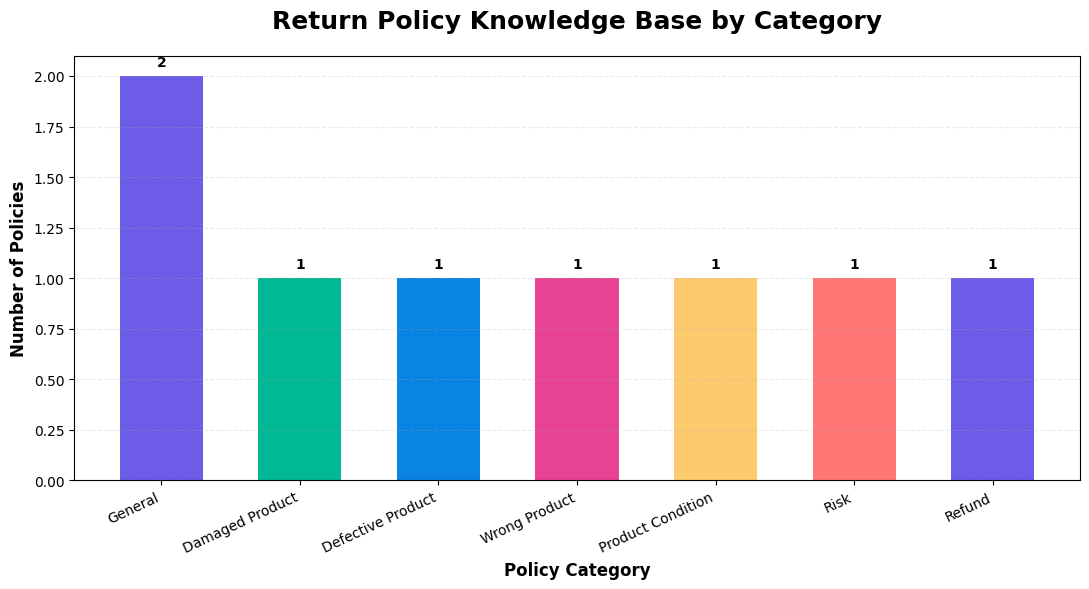

In [80]:
policy_category_counts = policy_df["category"].value_counts()

plt.figure(figsize=(11, 6))

bars = plt.bar(
    policy_category_counts.index,
    policy_category_counts.values,
    width=0.6,
    color=[
        "#6C5CE7",
        "#00B894",
        "#0984E3",
        "#E84393",
        "#FDCB6E",
        "#FF7675"
    ]
)

plt.title(
    "Return Policy Knowledge Base by Category",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.xlabel("Policy Category", fontsize=12, fontweight="bold")
plt.ylabel("Number of Policies", fontsize=12, fontweight="bold")

plt.xticks(rotation=25, ha="right")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.05,
        int(bar.get_height()),
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

In [81]:
policy_chunks = []

for policy in policy_documents:

    chunk = {
        "policy_id": policy["policy_id"],
        "title": policy["title"],
        "category": policy["category"],
        "text": policy["content"].strip()
    }

    policy_chunks.append(chunk)

print("✓ Policy documents converted into chunks.")
print("Total policy chunks:", len(policy_chunks))

✓ Policy documents converted into chunks.
Total policy chunks: 8


In [82]:
embedding_model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2"
)

print("✓ Embedding model loaded successfully.")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✓ Embedding model loaded successfully.


In [83]:
policy_texts = [
    chunk["text"]
    for chunk in policy_chunks
]

policy_embeddings = embedding_model.encode(
    policy_texts,
    convert_to_numpy=True,
    show_progress_bar=True
)

print("✓ Policy embeddings created.")
print("Embedding shape:", policy_embeddings.shape)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

✓ Policy embeddings created.
Embedding shape: (8, 384)


In [84]:
embedding_dimension = policy_embeddings.shape[1]

index = faiss.IndexFlatL2(embedding_dimension)

index.add(
    policy_embeddings.astype("float32")
)

print("✓ FAISS vector index created.")
print("Total indexed policies:", index.ntotal)

✓ FAISS vector index created.
Total indexed policies: 8


In [85]:
def retrieve_policies(query, top_k=3):

    query_embedding = embedding_model.encode(
        [query],
        convert_to_numpy=True
    )

    distances, indices = index.search(
        query_embedding.astype("float32"),
        top_k
    )

    results = []

    for distance, idx in zip(distances[0], indices[0]):

        if idx < len(policy_chunks):

            result = policy_chunks[idx].copy()
            result["distance"] = float(distance)

            results.append(result)

    return results

In [86]:
query = """
Customer wants to return an opened product after 16 days.
The customer says the product is not needed.
"""

retrieved_policies = retrieve_policies(query, top_k=3)

for i, policy in enumerate(retrieved_policies, 1):

    print("=" * 70)
    print(f"Retrieved Policy {i}")
    print("=" * 70)

    print("Policy ID :", policy["policy_id"])
    print("Title     :", policy["title"])
    print("Category  :", policy["category"])
    print("Distance  :", round(policy["distance"], 4))
    print("Policy    :", policy["text"])

Retrieved Policy 1
Policy ID : POL002
Title     : Product Condition Policy
Category  : General
Distance  : 0.5831
Policy    : Products should be returned in acceptable condition.
Unused and unopened products are generally eligible for return.
Opened products may require additional verification.
Used products may be subject to return restrictions.
Retrieved Policy 2
Policy ID : POL006
Title     : Used Product Policy
Category  : Product Condition
Distance  : 0.8741
Policy    : Returns for products that show signs of use may require additional
inspection. The final decision depends on product condition and the
applicable return policy.
Retrieved Policy 3
Policy ID : POL003
Title     : Damaged Product Policy
Category  : Damaged Product
Distance  : 0.8807
Policy    : Customers who receive damaged products can request a return.
The customer may be required to provide evidence such as photographs
or other supporting information for validation.


In [87]:
retrieval_results_df = pd.DataFrame([
    {
        "Policy ID": p["policy_id"],
        "Policy Title": p["title"],
        "Category": p["category"],
        "Distance": round(p["distance"], 4)
    }
    for p in retrieved_policies
])

retrieval_results_df

,Policy ID,Policy Title,Category,Distance
0,POL002,Product Condition Policy,General,0.5831
1,POL006,Used Product Policy,Product Condition,0.8741
2,POL003,Damaged Product Policy,Damaged Product,0.8807


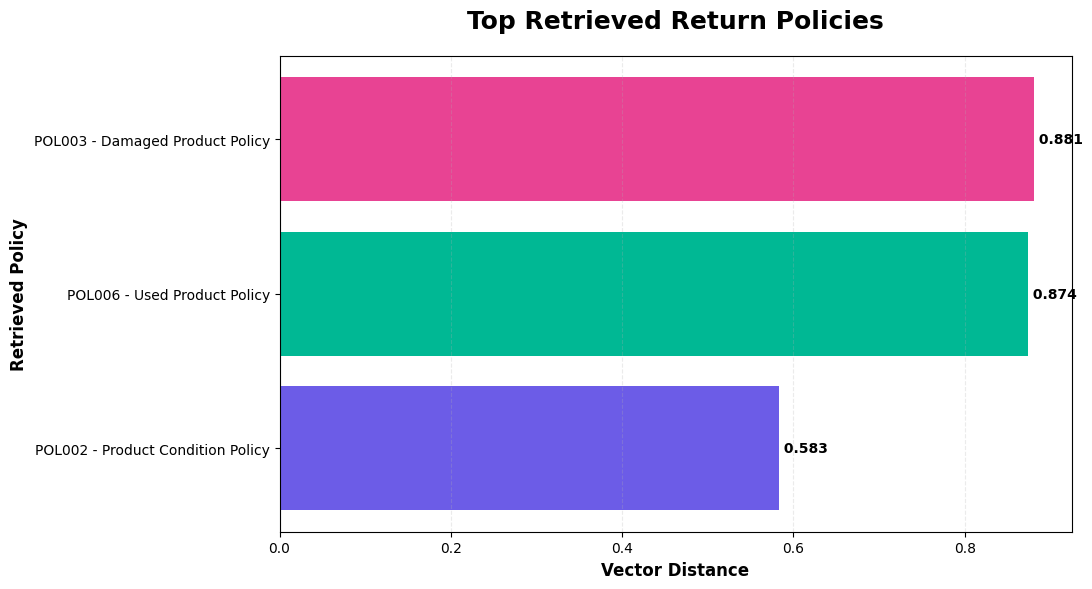

In [88]:
plt.figure(figsize=(11, 6))

labels = [
    p["policy_id"] + " - " + p["title"]
    for p in retrieved_policies
]

distances = [
    p["distance"]
    for p in retrieved_policies
]

bars = plt.barh(
    labels,
    distances,
    color=["#6C5CE7", "#00B894", "#E84393"]
)

plt.title(
    "Top Retrieved Return Policies",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.xlabel(
    "Vector Distance",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Retrieved Policy",
    fontsize=12,
    fontweight="bold"
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

for bar, value in zip(bars, distances):
    plt.text(
        value,
        bar.get_y() + bar.get_height()/2,
        f" {value:.3f}",
        va="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

In [89]:
def create_policy_context(retrieved_policies):

    policy_context = ""

    for i, policy in enumerate(retrieved_policies, 1):

        policy_context += f"""
Policy {i}
Policy ID: {policy["policy_id"]}
Title: {policy["title"]}
Category: {policy["category"]}

Policy Content:
{policy["text"]}

"""

    return policy_context.strip()

In [90]:
policy_context = create_policy_context(
    retrieved_policies
)

print(policy_context)

Policy 1
Policy ID: POL002
Title: Product Condition Policy
Category: General

Policy Content:
Products should be returned in acceptable condition.
Unused and unopened products are generally eligible for return.
Opened products may require additional verification.
Used products may be subject to return restrictions.


Policy 2
Policy ID: POL006
Title: Used Product Policy
Category: Product Condition

Policy Content:
Returns for products that show signs of use may require additional
inspection. The final decision depends on product condition and the
applicable return policy.


Policy 3
Policy ID: POL003
Title: Damaged Product Policy
Category: Damaged Product

Policy Content:
Customers who receive damaged products can request a return.
The customer may be required to provide evidence such as photographs
or other supporting information for validation.


In [91]:
rag_prompt = f"""
You are an Explainable Return Validation Assistant.

Analyze the customer return request using:

1. Customer return information
2. Risk analysis
3. Retrieved policy evidence

IMPORTANT RULES:

- Use only the provided return information.
- Use only the retrieved policy information.
- Do not invent policy rules.
- If the evidence is insufficient, recommend REVIEW.
- Explain the decision clearly.
- Mention the relevant policy ID.

Customer Return Information:
{return_context}

Retrieved Policy Evidence:
{policy_context}

Provide the response in exactly this format:

Decision:
Risk Level:
Reason:
Policy Evidence:
Policy Check:
Recommended Action:
"""

In [92]:
response = client.chat.completions.create(
    model="meta-llama/Llama-3.1-8B-Instruct",
    messages=[
        {
            "role": "system",
            "content": (
                "You are an explainable return validation assistant. "
                "Never invent policy information."
            )
        },
        {
            "role": "user",
            "content": rag_prompt
        }
    ],
    max_tokens=350,
    temperature=0.2
)

rag_response = response.choices[0].message.content

print("=" * 75)
print("        RAG-BASED RETURN VALIDATION")
print("=" * 75)
print(rag_response)

        RAG-BASED RETURN VALIDATION
Decision:
The customer's return request is APPROVED.

Risk Level:
LOW

Reason:
The customer's return request meets the conditions of Policy 1 (POL002) and Policy 3 (POL003). The product is new, and the customer is returning it due to a damaged product, which is a valid reason for return according to Policy 3.

Policy Evidence:
Policy 1 (POL002) states that products should be returned in acceptable condition, and unused and unopened products are generally eligible for return. Policy 3 (POL003) supports the return request as it allows customers to return damaged products and requires evidence such as photographs for validation.

Policy Check:
The customer's return request meets the conditions of Policy 1 (POL002) and Policy 3 (POL003). The product is new, and the customer is returning it due to a damaged product, which is a valid reason for return according to Policy 3.

Recommended Action:
The return request should be processed, and the customer shoul

In [93]:
comparison = pd.DataFrame({
    "Approach": [
        "LLM Only",
        "LLM + RAG"
    ],
    "Policy Evidence": [
        "Not explicitly retrieved",
        "Retrieved from policy knowledge base"
    ],
    "Hallucination Control": [
        "Lower",
        "Improved through grounded context"
    ],
    "Explainability": [
        "General explanation",
        "Policy-based explanation"
    ]
})

comparison

,Approach,Policy Evidence,Hallucination Control,Explainability
0,LLM Only,Not explicitly retrieved,Lower,General explanation
1,LLM + RAG,Retrieved from policy knowledge base,Improved through grounded context,Policy-based explanation


In [94]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║                 DAY 4 - RAG PIPELINE                            ║
╚══════════════════════════════════════════════════════════════════╝

 Customer Return Request
          │
          ▼
 ┌─────────────────────┐
 │   Risk Analysis     │
 └──────────┬──────────┘
            │
            ▼
 ┌─────────────────────┐
 │ Policy Knowledge    │
 │      Base           │
 └──────────┬──────────┘
            │
            ▼
 ┌─────────────────────┐
 │    Embeddings       │
 └──────────┬──────────┘
            │
            ▼
 ┌─────────────────────┐
 │ FAISS Vector Search │
 └──────────┬──────────┘
            │
            ▼
 ┌─────────────────────┐
 │ Relevant Policies   │
 └──────────┬──────────┘
            │
            ▼
 ┌─────────────────────┐
 │        LLM          │
 └──────────┬──────────┘
            │
            ▼
 ┌─────────────────────┐
 │ Decision + Reason + │
 │ Policy Evidence     │
 └─────────────────────┘
""")


╔══════════════════════════════════════════════════════════════════╗
║                 DAY 4 - RAG PIPELINE                            ║
╚══════════════════════════════════════════════════════════════════╝

 Customer Return Request
          │
          ▼
 ┌─────────────────────┐
 │   Risk Analysis     │
 └──────────┬──────────┘
            │
            ▼
 ┌─────────────────────┐
 │ Policy Knowledge    │
 │      Base           │
 └──────────┬──────────┘
            │
            ▼
 ┌─────────────────────┐
 │    Embeddings       │
 └──────────┬──────────┘
            │
            ▼
 ┌─────────────────────┐
 │ FAISS Vector Search │
 └──────────┬──────────┘
            │
            ▼
 ┌─────────────────────┐
 │ Relevant Policies   │
 └──────────┬──────────┘
            │
            ▼
 ┌─────────────────────┐
 │        LLM          │
 └──────────┬──────────┘
            │
            ▼
 ┌─────────────────────┐
 │ Decision + Reason + │
 │ Policy Evidence     │
 └─────────────────────┘


In [95]:
policy_path = f"{project_folder}/policy_documents.csv"

policy_df.to_csv(
    policy_path,
    index=False
)

retrieval_path = f"{project_folder}/day4_retrieval_results.csv"

retrieval_results_df.to_csv(
    retrieval_path,
    index=False
)

print("✓ Policy documents saved.")
print("✓ Retrieval results saved.")

✓ Policy documents saved.
✓ Retrieval results saved.


In [96]:
print("=" * 75)
print("              DABA PROJECT - DAY 4 SUMMARY")
print("=" * 75)

print("\nProject:")
print("Explainable LLM-Based Return Validation and Risk Assessment System")

print("\nDay 4 Activities")
print("-" * 75)

print("✓ Return policy knowledge base created")
print("✓ Policy documents structured")
print("✓ Policy documents converted into chunks")
print("✓ Sentence embeddings generated")
print("✓ FAISS vector database created")
print("✓ Policy retrieval implemented")
print("✓ Relevant policy evidence retrieved")
print("✓ RAG prompt created")
print("✓ RAG integrated with LLM")
print("✓ Explainable policy-based response generated")

print("\nDay 4 Outcome")
print("-" * 75)

print("The system can now retrieve relevant return policies")
print("and provide policy-grounded LLM validation.")

print("\nNext Step")
print("-" * 75)

print("Day 5 - Prompt Engineering and Validation Guardrails")

print("\n" + "=" * 75)
print("              DAY 4 COMPLETED SUCCESSFULLY! ✓")
print("=" * 75)

              DABA PROJECT - DAY 4 SUMMARY

Project:
Explainable LLM-Based Return Validation and Risk Assessment System

Day 4 Activities
---------------------------------------------------------------------------
✓ Return policy knowledge base created
✓ Policy documents structured
✓ Policy documents converted into chunks
✓ Sentence embeddings generated
✓ FAISS vector database created
✓ Policy retrieval implemented
✓ Relevant policy evidence retrieved
✓ RAG prompt created
✓ RAG integrated with LLM
✓ Explainable policy-based response generated

Day 4 Outcome
---------------------------------------------------------------------------
The system can now retrieve relevant return policies
and provide policy-grounded LLM validation.

Next Step
---------------------------------------------------------------------------
Day 5 - Prompt Engineering and Validation Guardrails

              DAY 4 COMPLETED SUCCESSFULLY! ✓


In [97]:
print("=" * 80)
print("        DAY 5 - PROMPT ENGINEERING + VALIDATION GUARDRAILS")
print("=" * 80)

print("\nProject:")
print("Explainable LLM-Based Return Validation and Risk Assessment System Using RAG")

print("\nDay 5 Objective:")
print("Design structured prompts and validation guardrails to improve")
print("decision consistency, explainability, and policy grounding.")

print("\n✓ Day 5 Started Successfully!")

        DAY 5 - PROMPT ENGINEERING + VALIDATION GUARDRAILS

Project:
Explainable LLM-Based Return Validation and Risk Assessment System Using RAG

Day 5 Objective:
Design structured prompts and validation guardrails to improve
decision consistency, explainability, and policy grounding.

✓ Day 5 Started Successfully!


In [98]:
required_day4_objects = [
    "df",
    "policy_df",
    "policy_chunks",
    "embedding_model",
    "index",
    "retrieve_policies",
    "client"
]

missing_objects = [
    obj for obj in required_day4_objects
    if obj not in globals()
]

if len(missing_objects) == 0:
    print("✓ Day 4 components are available.")
    print("✓ Ready for Day 5.")
else:
    print("Missing objects:", missing_objects)

✓ Day 4 components are available.
✓ Ready for Day 5.


In [99]:
def apply_validation_guardrails(row):

    risk_score = row["risk_score"]
    risk_level = row["risk_level"]
    days = row["days_after_delivery"]
    condition = row["product_condition"]
    policy_period = row["within_policy_period"]

    flags = []

    if days > 14:
        flags.append("RETURN_PERIOD_EXCEEDED")

    if condition == "Used":
        flags.append("USED_PRODUCT")

    if condition == "Damaged":
        flags.append("DAMAGED_PRODUCT")

    if risk_level == "HIGH":
        flags.append("HIGH_RISK")

    if policy_period == False:
        flags.append("OUTSIDE_POLICY_PERIOD")

    if len(flags) == 0:
        guardrail_status = "STANDARD_VALIDATION"
    elif "RETURN_PERIOD_EXCEEDED" in flags:
        guardrail_status = "MANUAL_REVIEW_REQUIRED"
    elif risk_level == "HIGH":
        guardrail_status = "MANUAL_REVIEW_REQUIRED"
    else:
        guardrail_status = "ADDITIONAL_VALIDATION_REQUIRED"

    return {
        "guardrail_status": guardrail_status,
        "flags": flags
    }

In [100]:
sample_return = df.iloc[0]

guardrail_result = apply_validation_guardrails(
    sample_return
)

print("=" * 70)
print("VALIDATION GUARDRAIL RESULT")
print("=" * 70)

print("Return ID       :", sample_return["return_id"])
print("Risk Score      :", sample_return["risk_score"])
print("Risk Level      :", sample_return["risk_level"])
print("Guardrail Status:", guardrail_result["guardrail_status"])
print("Flags           :", guardrail_result["flags"])

VALIDATION GUARDRAIL RESULT
Return ID       : 1
Risk Score      : 10
Risk Level      : LOW
Guardrail Status: STANDARD_VALIDATION
Flags           : []


In [101]:
def create_day5_prompt(
    return_context,
    policy_context,
    guardrail_result
):

    prompt = f"""
You are an Explainable Return Validation Assistant.

Your responsibility is to validate a customer return request using
ONLY the provided customer information, risk analysis, validation
guardrails, and retrieved policy evidence.

================ CUSTOMER RETURN =================

{return_context}

================ VALIDATION GUARDRAILS ===========

Guardrail Status:
{guardrail_result["guardrail_status"]}

Validation Flags:
{guardrail_result["flags"]}

================ RETRIEVED POLICY =================

{policy_context}

================ STRICT RULES =====================

1. Never invent a return policy.
2. Use only the retrieved policy evidence.
3. Do not ignore the risk level.
4. Do not automatically approve a high-risk request.
5. If evidence is insufficient, recommend REVIEW.
6. If the return period is exceeded, mention it clearly.
7. If product condition creates uncertainty, recommend additional validation.
8. Mention the relevant Policy ID.
9. Give a short and understandable explanation.
10. Separate facts from recommendations.

================ REQUIRED OUTPUT FORMAT ==========

Decision:
Risk Level:
Guardrail Status:
Reason:
Policy Evidence:
Policy Check:
Recommended Action:
Confidence:
"""

    return prompt.strip()

In [102]:
sample_return = df.iloc[10]

return_context = create_return_context(sample_return)

query = f"""
Product category: {sample_return["product_category"]}
Days after delivery: {sample_return["days_after_delivery"]}
Product condition: {sample_return["product_condition"]}
Return reason: {sample_return["return_reason"]}
Risk level: {sample_return["risk_level"]}
"""

retrieved_policies = retrieve_policies(
    query,
    top_k=3
)

policy_context = create_policy_context(
    retrieved_policies
)

guardrail_result = apply_validation_guardrails(
    sample_return
)

day5_prompt = create_day5_prompt(
    return_context,
    policy_context,
    guardrail_result
)

print(day5_prompt)

You are an Explainable Return Validation Assistant.

Your responsibility is to validate a customer return request using
ONLY the provided customer information, risk analysis, validation
guardrails, and retrieved policy evidence.

================ CUSTOMER RETURN =================

Customer Return Request

Product Category: Furniture
Days After Delivery: 27
Product Condition: Used
Return Reason: Damaged Product
Product Price: 2403
Customer Rating: 3
Previous Returns: 6
Within Policy Period: 0

Risk Score: 90
Risk Level: HIGH

================ VALIDATION GUARDRAILS ===========

Guardrail Status:
MANUAL_REVIEW_REQUIRED

Validation Flags:
['RETURN_PERIOD_EXCEEDED', 'USED_PRODUCT', 'HIGH_RISK', 'OUTSIDE_POLICY_PERIOD']

================ RETRIEVED POLICY =================

Policy 1
Policy ID: POL003
Title: Damaged Product Policy
Category: Damaged Product

Policy Content:
Customers who receive damaged products can request a return.
The customer may be required to provide evidence such as phot

In [103]:
response = client.chat.completions.create(
    model="meta-llama/Llama-3.1-8B-Instruct",
    messages=[
        {
            "role": "system",
            "content": """
You are a strict and explainable return validation assistant.

You must ground your response in the supplied policy evidence.
Never invent policies.
If the evidence is insufficient, recommend REVIEW.
"""
        },
        {
            "role": "user",
            "content": day5_prompt
        }
    ],
    max_tokens=400,
    temperature=0.1
)

day5_response = response.choices[0].message.content

print("=" * 80)
print("        DAY 5 - EXPLAINABLE VALIDATION RESULT")
print("=" * 80)
print(day5_response)

        DAY 5 - EXPLAINABLE VALIDATION RESULT
================ VALIDATION RESULTS ===============

Decision: MANUAL_REVIEW_REQUIRED
Risk Level: HIGH
Guardrail Status: MANUAL_REVIEW_REQUIRED
Reason: The return request exceeds the return period, and the product condition is used.
Policy Evidence: POL003 (Damaged Product Policy) and POL006 (Used Product Policy)
Policy Check: The return request meets the criteria for a damaged product, but the used product condition creates uncertainty.
Recommended Action: REVIEW
Confidence: 80%

Explanation:
The customer return request exceeds the return period (27 days) and is for a used product, which may require additional inspection. The risk level is HIGH, and the return reason is "Damaged Product". The relevant policies are POL003 (Damaged Product Policy) and POL006 (Used Product Policy). However, the used product condition creates uncertainty, and additional validation is recommended.

Separation of facts from recommendations:
- Facts:
  - Return p

In [104]:
def run_validation_test(row):

    return_context = create_return_context(row)

    query = f"""
    Product category: {row["product_category"]}
    Days after delivery: {row["days_after_delivery"]}
    Product condition: {row["product_condition"]}
    Return reason: {row["return_reason"]}
    Risk level: {row["risk_level"]}
    """

    retrieved = retrieve_policies(
        query,
        top_k=3
    )

    policy_context = create_policy_context(retrieved)

    guardrails = apply_validation_guardrails(row)

    prompt = create_day5_prompt(
        return_context,
        policy_context,
        guardrails
    )

    response = client.chat.completions.create(
        model="meta-llama/Llama-3.1-8B-Instruct",
        messages=[
            {
                "role": "system",
                "content": "You are a strict explainable return validation assistant."
            },
            {
                "role": "user",
                "content": prompt
            }
        ],
        max_tokens=350,
        temperature=0.1
    )

    return response.choices[0].message.content

In [105]:
test_cases_day5 = df.sample(
    10,
    random_state=42
).copy()

day5_results = []

for _, row in test_cases_day5.iterrows():

    result = run_validation_test(row)

    day5_results.append({
        "return_id": row["return_id"],
        "product_category": row["product_category"],
        "risk_score": row["risk_score"],
        "risk_level": row["risk_level"],
        "return_reason": row["return_reason"],
        "llm_response": result
    })

day5_results_df = pd.DataFrame(
    day5_results
)

print("✓ Day 5 validation testing completed.")
print("Test cases:", len(day5_results_df))

✓ Day 5 validation testing completed.
Test cases: 10


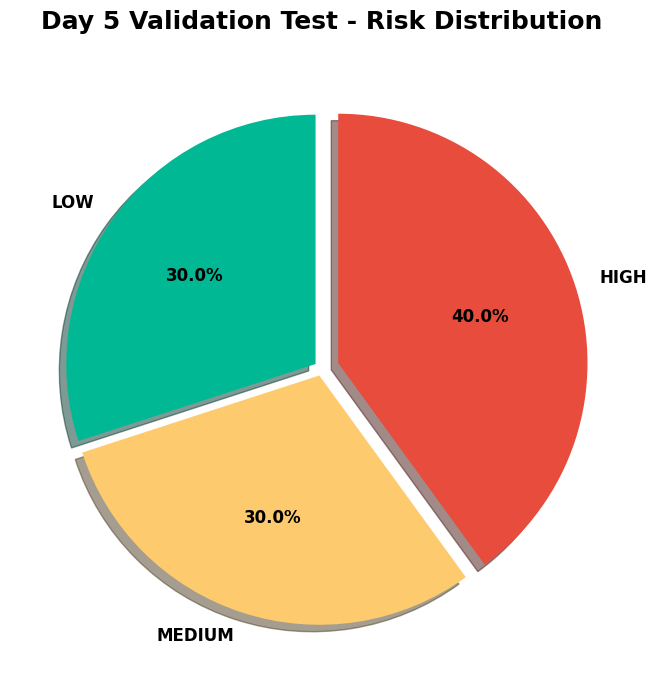

In [106]:
risk_counts_day5 = (
    test_cases_day5["risk_level"]
    .value_counts()
    .reindex(["LOW", "MEDIUM", "HIGH"])
    .fillna(0)
)

plt.figure(figsize=(9, 7))

colors = [
    "#00B894",
    "#FDCB6E",
    "#E74C3C"
]

explode = [0.03, 0.03, 0.07]

plt.pie(
    risk_counts_day5.values,
    labels=risk_counts_day5.index,
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
    explode=explode,
    shadow=True,
    textprops={
        "fontsize": 12,
        "fontweight": "bold"
    }
)

plt.title(
    "Day 5 Validation Test - Risk Distribution",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.tight_layout()
plt.show()

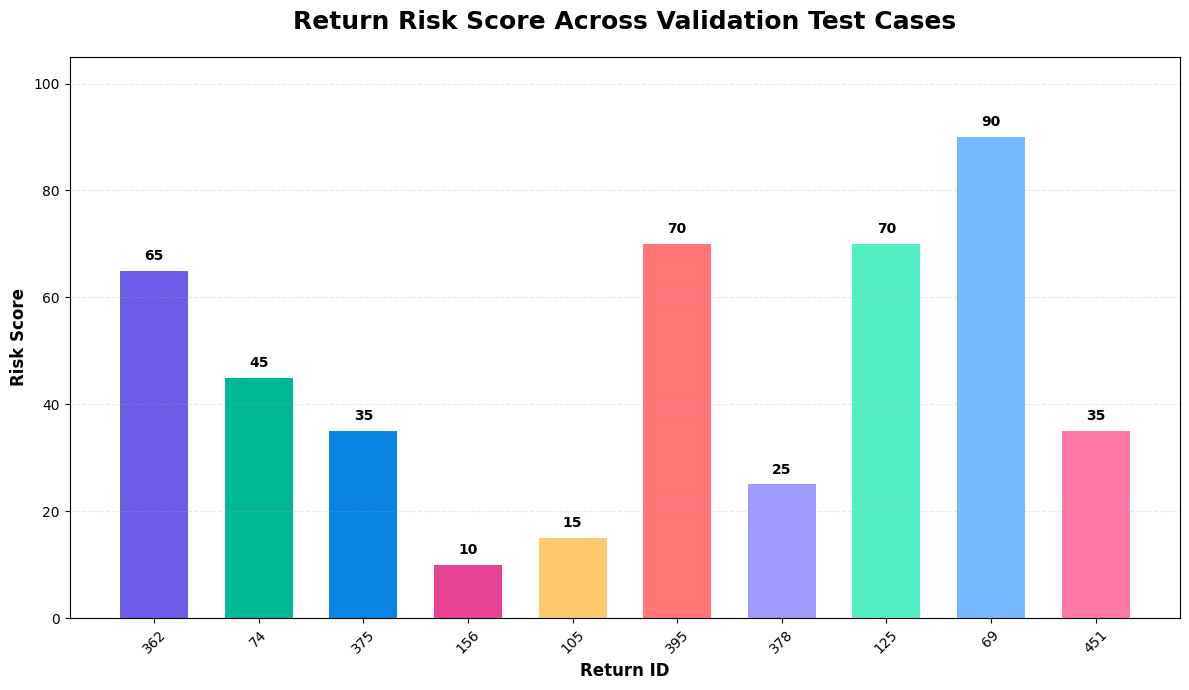

In [107]:
plt.figure(figsize=(12, 7))

bars = plt.bar(
    test_cases_day5["return_id"].astype(str),
    test_cases_day5["risk_score"],
    color=[
        "#6C5CE7",
        "#00B894",
        "#0984E3",
        "#E84393",
        "#FDCB6E",
        "#FF7675",
        "#A29BFE",
        "#55EFC4",
        "#74B9FF",
        "#FD79A8"
    ],
    width=0.65
)

plt.title(
    "Return Risk Score Across Validation Test Cases",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.xlabel(
    "Return ID",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Risk Score",
    fontsize=12,
    fontweight="bold"
)

plt.ylim(0, 105)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

plt.xticks(rotation=45)

for bar in bars:

    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 2,
        f"{bar.get_height():.0f}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

In [108]:
guardrail_records = []

for _, row in test_cases_day5.iterrows():

    result = apply_validation_guardrails(row)

    guardrail_records.append({
        "risk_level": row["risk_level"],
        "guardrail_status": result["guardrail_status"]
    })

guardrail_df = pd.DataFrame(
    guardrail_records
)

guardrail_table = pd.crosstab(
    guardrail_df["risk_level"],
    guardrail_df["guardrail_status"]
)

guardrail_table

guardrail_status,ADDITIONAL_VALIDATION_REQUIRED,MANUAL_REVIEW_REQUIRED,STANDARD_VALIDATION
risk_level,,,
HIGH,0,4,0
LOW,1,0,2
MEDIUM,0,1,2


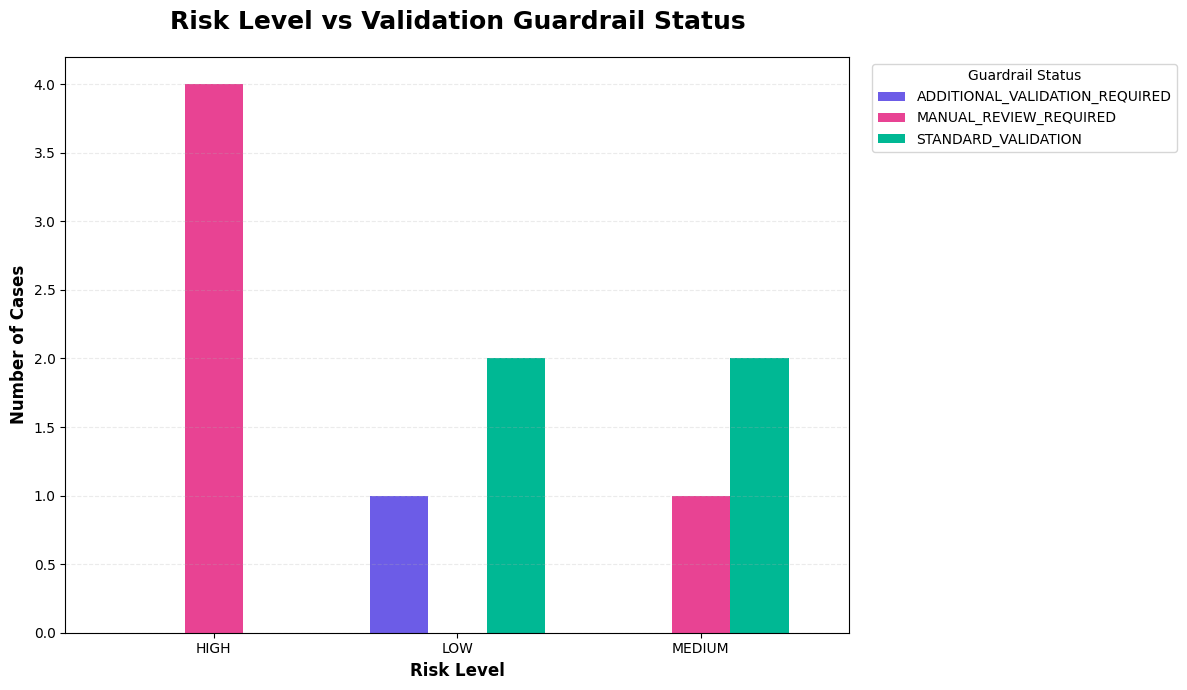

In [109]:
guardrail_table.plot(
    kind="bar",
    figsize=(12, 7),
    width=0.72,
    color=[
        "#6C5CE7",
        "#E84393",
        "#00B894"
    ]
)

plt.title(
    "Risk Level vs Validation Guardrail Status",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.xlabel(
    "Risk Level",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Number of Cases",
    fontsize=12,
    fontweight="bold"
)

plt.xticks(rotation=0)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

plt.legend(
    title="Guardrail Status",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [110]:
total_cases = len(test_cases_day5)

high_risk_cases = (
    test_cases_day5["risk_level"] == "HIGH"
).sum()

medium_risk_cases = (
    test_cases_day5["risk_level"] == "MEDIUM"
).sum()

low_risk_cases = (
    test_cases_day5["risk_level"] == "LOW"
).sum()

manual_review_cases = (
    guardrail_df["guardrail_status"]
    == "MANUAL_REVIEW_REQUIRED"
).sum()

print("=" * 80)
print("             RETURN VALIDATION - DAY 5 METRICS")
print("=" * 80)

print(f"""
Total Test Cases       : {total_cases}
Low Risk Cases         : {low_risk_cases}
Medium Risk Cases      : {medium_risk_cases}
High Risk Cases        : {high_risk_cases}
Manual Review Cases    : {manual_review_cases}
Policy Retrieval       : Enabled
RAG Grounding          : Enabled
Validation Guardrails  : Enabled
Explainable Output     : Enabled
""")

print("=" * 80)

             RETURN VALIDATION - DAY 5 METRICS

Total Test Cases       : 10
Low Risk Cases         : 3
Medium Risk Cases      : 3
High Risk Cases        : 4
Manual Review Cases    : 5
Policy Retrieval       : Enabled
RAG Grounding          : Enabled
Validation Guardrails  : Enabled
Explainable Output     : Enabled



In [111]:
day5_results_path = (
    f"{project_folder}/day5_validation_results.csv"
)

day5_results_df.to_csv(
    day5_results_path,
    index=False
)

guardrail_path = (
    f"{project_folder}/day5_guardrail_analysis.csv"
)

guardrail_df.to_csv(
    guardrail_path,
    index=False
)

print("✓ Day 5 validation results saved.")
print("✓ Guardrail analysis saved.")

✓ Day 5 validation results saved.
✓ Guardrail analysis saved.


In [112]:
print("=" * 80)
print("              DABA PROJECT - DAY 5 SUMMARY")
print("=" * 80)

print("""
Project:
An Explainable LLM-Based Return Validation and Risk Assessment
System Using RAG
""")

print("Day 5 Activities")
print("-" * 80)

print("✓ Structured prompt engineering implemented")
print("✓ Validation guardrails implemented")
print("✓ Risk-based validation rules added")
print("✓ Dynamic policy retrieval integrated")
print("✓ Policy-grounded LLM validation implemented")
print("✓ Multiple return cases tested")
print("✓ Risk distribution visualized")
print("✓ Risk score visualization created")
print("✓ Guardrail analysis completed")
print("✓ Explainable validation workflow established")

print("\nDay 5 Outcome")
print("-" * 80)

print("""
The system now combines:

Risk Analysis
+
Retrieved Policy Evidence
+
Validation Guardrails
+
LLM Reasoning
=
Explainable Return Validation
""")

print("Next:")
print("Day 6 - First Complete Return Validation Assistant")

print("\n" + "=" * 80)
print("              DAY 5 COMPLETED SUCCESSFULLY! ✓")
print("=" * 80)

              DABA PROJECT - DAY 5 SUMMARY

Project:
An Explainable LLM-Based Return Validation and Risk Assessment
System Using RAG

Day 5 Activities
--------------------------------------------------------------------------------
✓ Structured prompt engineering implemented
✓ Validation guardrails implemented
✓ Risk-based validation rules added
✓ Dynamic policy retrieval integrated
✓ Policy-grounded LLM validation implemented
✓ Multiple return cases tested
✓ Risk distribution visualized
✓ Risk score visualization created
✓ Guardrail analysis completed
✓ Explainable validation workflow established

Day 5 Outcome
--------------------------------------------------------------------------------

The system now combines:

Risk Analysis
+
Retrieved Policy Evidence
+
Validation Guardrails
+
LLM Reasoning
=
Explainable Return Validation

Next:
Day 6 - First Complete Return Validation Assistant

              DAY 5 COMPLETED SUCCESSFULLY! ✓


In [113]:
print("=" * 70)
print("DAY 6 - FIRST WORKING RETURN VALIDATION ASSISTANT")
print("=" * 70)

print("Goal:")
print("Combine Risk Analysis + RAG + Guardrails + LLM")
print("into one complete return validation workflow.")

DAY 6 - FIRST WORKING RETURN VALIDATION ASSISTANT
Goal:
Combine Risk Analysis + RAG + Guardrails + LLM
into one complete return validation workflow.


In [114]:
required_objects = [
    "df",
    "policy_df",
    "policy_chunks",
    "embedding_model",
    "index",
    "retrieve_policies",
    "create_policy_context",
    "client",
    "MODEL_NAME"
]

missing_objects = [
    obj for obj in required_objects
    if obj not in globals()
]

if len(missing_objects) == 0:
    print("✅ Day 1-5 components are available.")
    print("✅ Ready to build Day 6 assistant.")
else:
    print("⚠️ Missing objects:")
    print(missing_objects)

✅ Day 1-5 components are available.
✅ Ready to build Day 6 assistant.


In [115]:
def create_customer_return(
    product_category,
    days_after_delivery,
    product_condition,
    return_reason,
    product_price,
    customer_rating,
    previous_returns,
    within_policy_period
):

    return {
        "product_category": product_category,
        "days_after_delivery": days_after_delivery,
        "product_condition": product_condition,
        "return_reason": return_reason,
        "product_price": product_price,
        "customer_rating": customer_rating,
        "previous_returns": previous_returns,
        "within_policy_period": within_policy_period
    }

In [116]:
def calculate_new_return_risk(return_data):

    score = 0

    if return_data["days_after_delivery"] > 14:
        score += 40
    elif return_data["days_after_delivery"] > 10:
        score += 20

    if return_data["product_condition"] == "Used":
        score += 30
    elif return_data["product_condition"] == "Opened":
        score += 15
    elif return_data["product_condition"] == "Damaged":
        score += 5

    if return_data["previous_returns"] >= 5:
        score += 20
    elif return_data["previous_returns"] >= 3:
        score += 10

    if return_data["customer_rating"] <= 2:
        score += 10

    score = min(score, 100)

    if score < 30:
        level = "LOW"
    elif score < 60:
        level = "MEDIUM"
    else:
        level = "HIGH"

    return score, level

In [117]:
def create_new_return_context(return_data, risk_score, risk_level):

    context = f"""
Customer Return Information

Product Category: {return_data["product_category"]}
Days After Delivery: {return_data["days_after_delivery"]}
Product Condition: {return_data["product_condition"]}
Return Reason: {return_data["return_reason"]}
Product Price: {return_data["product_price"]}
Customer Rating: {return_data["customer_rating"]}
Previous Returns: {return_data["previous_returns"]}
Within Policy Period: {return_data["within_policy_period"]}

Risk Score: {risk_score}/100
Risk Level: {risk_level}
"""

    return context.strip()

In [118]:
def retrieve_relevant_policies(return_data, risk_level):

    query = f"""
    Return validation for {return_data["product_category"]}.
    Customer wants return because of {return_data["return_reason"]}.
    Product condition is {return_data["product_condition"]}.
    Return requested {return_data["days_after_delivery"]} days after delivery.
    Risk level is {risk_level}.
    """

    retrieved = retrieve_policies(query, top_k=3)

    return retrieved

In [119]:
def check_return_guardrails(return_data, risk_level):

    flags = []

    if return_data["days_after_delivery"] > 14:
        flags.append("RETURN_PERIOD_EXCEEDED")

    if return_data["product_condition"] == "Used":
        flags.append("USED_PRODUCT")

    if return_data["product_condition"] == "Damaged":
        flags.append("DAMAGED_PRODUCT")

    if risk_level == "HIGH":
        flags.append("HIGH_RISK")

    if return_data["within_policy_period"] == False:
        flags.append("OUTSIDE_POLICY_PERIOD")

    if "RETURN_PERIOD_EXCEEDED" in flags:
        status = "MANUAL_REVIEW_REQUIRED"

    elif risk_level == "HIGH":
        status = "MANUAL_REVIEW_REQUIRED"

    elif len(flags) > 0:
        status = "ADDITIONAL_VALIDATION_REQUIRED"

    else:
        status = "STANDARD_VALIDATION"

    return {
        "guardrail_status": status,
        "flags": flags
    }

In [120]:
def create_day6_validation_prompt(
    return_context,
    policy_context,
    guardrail_result
):

    prompt = f"""
You are an Explainable Return Validation Assistant.

Validate the customer return request using ONLY the information provided.

Do not invent policies.
Do not create facts that are not provided.
Use the retrieved policy evidence.
Consider the risk level and guardrail status.

Customer Return Information:
{return_context}

Validation Guardrails:
Status: {guardrail_result["guardrail_status"]}
Flags: {guardrail_result["flags"]}

Retrieved Policy Evidence:
{policy_context}

IMPORTANT DECISION RULES:

1. If the request clearly satisfies the available policy
   and has no major risk issue, the decision can be APPROVE.

2. If the request clearly violates the available policy,
   the decision can be REJECT.

3. If additional verification or manual review is required,
   use REVIEW.

4. High-risk requests should not be automatically approved.

5. Explain the decision using the retrieved policy evidence.

Return exactly this format:

Decision:
Risk Level:
Guardrail Status:
Reason:
Policy Evidence:
Policy Check:
Recommended Action:
"""

    return prompt.strip()

In [121]:
def get_llm_validation(prompt):

    response = client.chat.completions.create(
        model=MODEL_NAME,
        messages=[
            {
                "role": "system",
                "content": (
                    "You are an explainable return validation assistant. "
                    "Use only the provided information and policy evidence."
                )
            },
            {
                "role": "user",
                "content": prompt
            }
        ],
        max_tokens=400,
        temperature=0.1
    )

    return response.choices[0].message.content

In [122]:
def return_validation_assistant(return_data):

    # 1. Calculate Risk
    risk_score, risk_level = calculate_new_return_risk(return_data)

    # 2. Create Return Context
    return_context = create_new_return_context(
        return_data,
        risk_score,
        risk_level
    )

    # 3. Retrieve Policies
    retrieved_policies = retrieve_relevant_policies(
        return_data,
        risk_level
    )

    # 4. Create Policy Context
    policy_context = create_policy_context(
        retrieved_policies
    )

    # 5. Apply Guardrails
    guardrail_result = check_return_guardrails(
        return_data,
        risk_level
    )

    # 6. Create LLM Prompt
    prompt = create_day6_validation_prompt(
        return_context,
        policy_context,
        guardrail_result
    )

    # 7. Get LLM Response
    llm_response = get_llm_validation(prompt)

    # 8. Return complete result
    return {
        "return_data": return_data,
        "risk_score": risk_score,
        "risk_level": risk_level,
        "guardrail_status": guardrail_result["guardrail_status"],
        "guardrail_flags": guardrail_result["flags"],
        "retrieved_policies": retrieved_policies,
        "llm_response": llm_response
    }

In [123]:
test_customer = create_customer_return(
    product_category="Electronics",
    days_after_delivery=8,
    product_condition="Opened",
    return_reason="Defective Product",
    product_price=25000,
    customer_rating=4,
    previous_returns=1,
    within_policy_period=True
)

result = return_validation_assistant(test_customer)

print(result["llm_response"])

Decision: REVIEW
Risk Level: LOW
Guardrail Status: STANDARD_VALIDATION
Reason: The return request requires additional verification due to the product being opened and the return reason being defective product.
Policy Evidence: Policy 1 (Defective Product Policy) and Policy 2 (Product Condition Policy)
Policy Check: Policy 1 states that the issue with the product should be clearly described and may require additional verification before approval. Policy 2 states that opened products may require additional verification.
Recommended Action: Manual review is required to verify the product condition and the return reason. The customer may be required to provide additional information or evidence to support the return request.


In [124]:
print("=" * 60)
print("RETURN VALIDATION RESULT")
print("=" * 60)

print("Risk Score      :", result["risk_score"])
print("Risk Level      :", result["risk_level"])
print("Guardrail Status:", result["guardrail_status"])
print("Guardrail Flags :", result["guardrail_flags"])

print("\nRetrieved Policies:")

for policy in result["retrieved_policies"]:
    print(
        policy["policy_id"],
        "-",
        policy["title"]
    )

print("\nLLM Validation:")
print(result["llm_response"])

RETURN VALIDATION RESULT
Risk Score      : 15
Risk Level      : LOW
Guardrail Status: STANDARD_VALIDATION
Guardrail Flags : []

Retrieved Policies:
POL004 - Defective Product Policy
POL002 - Product Condition Policy
POL003 - Damaged Product Policy

LLM Validation:
Decision: REVIEW
Risk Level: LOW
Guardrail Status: STANDARD_VALIDATION
Reason: The return request requires additional verification due to the product being opened and the return reason being defective product.
Policy Evidence: Policy 1 (Defective Product Policy) and Policy 2 (Product Condition Policy)
Policy Check: Policy 1 states that the issue with the product should be clearly described and may require additional verification before approval. Policy 2 states that opened products may require additional verification.
Recommended Action: Manual review is required to verify the product condition and the return reason. The customer may be required to provide additional information or evidence to support the return request.


In [125]:
test_cases = [

    create_customer_return(
        "Clothing", 5, "New", "Size Issue",
        1500, 5, 0, True
    ),

    create_customer_return(
        "Electronics", 8, "Opened", "Defective Product",
        25000, 4, 1, True
    ),

    create_customer_return(
        "Home Appliances", 18, "Used", "Changed Mind",
        30000, 2, 5, False
    ),

    create_customer_return(
        "Footwear", 10, "Damaged", "Damaged Product",
        3000, 3, 2, True
    ),

    create_customer_return(
        "Furniture", 20, "Used", "Not Needed",
        15000, 1, 6, False
    )
]

In [126]:
day6_results = []

for i, customer in enumerate(test_cases, 1):

    result = return_validation_assistant(customer)

    day6_results.append({
        "test_case": i,
        "product_category": customer["product_category"],
        "return_reason": customer["return_reason"],
        "risk_score": result["risk_score"],
        "risk_level": result["risk_level"],
        "guardrail_status": result["guardrail_status"],
        "decision_response": result["llm_response"]
    })

print("✅ All 5 test cases completed.")

✅ All 5 test cases completed.


In [127]:
day6_results_df = pd.DataFrame(day6_results)

display(day6_results_df[
    [
        "test_case",
        "product_category",
        "return_reason",
        "risk_score",
        "risk_level",
        "guardrail_status"
    ]
])

,test_case,product_category,return_reason,risk_score,risk_level,guardrail_status
0,1,Clothing,Size Issue,0,LOW,STANDARD_VALIDATION
1,2,Electronics,Defective Product,15,LOW,STANDARD_VALIDATION
2,3,Home Appliances,Changed Mind,100,HIGH,MANUAL_REVIEW_REQUIRED
3,4,Footwear,Damaged Product,5,LOW,ADDITIONAL_VALIDATION_REQUIRED
4,5,Furniture,Not Needed,100,HIGH,MANUAL_REVIEW_REQUIRED


In [128]:
day6_results_path = f"{project_folder}/day6_assistant_results.csv"

day6_results_df.to_csv(
    day6_results_path,
    index=False
)

print("✅ Day 6 results saved:")
print(day6_results_path)

✅ Day 6 results saved:
DABA_Return_Validation_Project/day6_assistant_results.csv


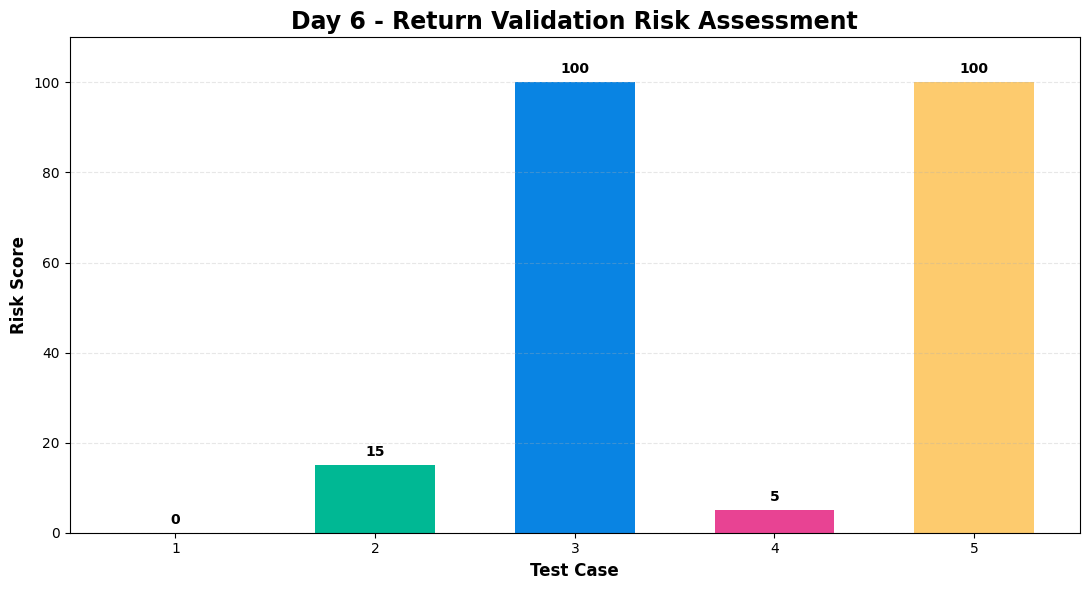

In [129]:
import matplotlib.pyplot as plt

plt.figure(figsize=(11, 6))

colors = [
    "#6C5CE7",
    "#00B894",
    "#0984E3",
    "#E84393",
    "#FDCB6E"
]

bars = plt.bar(
    day6_results_df["test_case"].astype(str),
    day6_results_df["risk_score"],
    color=colors,
    width=0.6
)

plt.title(
    "Day 6 - Return Validation Risk Assessment",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Test Case", fontsize=12, fontweight="bold")
plt.ylabel("Risk Score", fontsize=12, fontweight="bold")

plt.ylim(0, 110)

for bar, value in zip(bars, day6_results_df["risk_score"]):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 2,
        str(value),
        ha="center",
        fontweight="bold"
    )

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [131]:
print("=" * 70)
print("DAY 6 COMPLETED SUCCESSFULLY")
print("=" * 70)

print("✓ Customer return input created")
print("✓ Risk score calculated")
print("✓ Risk level identified")
print("✓ RAG policy retrieval integrated")
print("✓ Validation guardrails integrated")
print("✓ LLM reasoning integrated")
print("✓ Explainable validation response generated")
print("✓ Multiple return cases tested")
print("✓ Results saved")

DAY 6 COMPLETED SUCCESSFULLY
✓ Customer return input created
✓ Risk score calculated
✓ Risk level identified
✓ RAG policy retrieval integrated
✓ Validation guardrails integrated
✓ LLM reasoning integrated
✓ Explainable validation response generated
✓ Multiple return cases tested
✓ Results saved


In [132]:
print("=" * 75)
print("DAY 7 - TESTING AND VALIDATION")
print("=" * 75)

print("Objective:")
print("Test the complete Return Validation Assistant")
print("using different customer return scenarios.")

DAY 7 - TESTING AND VALIDATION
Objective:
Test the complete Return Validation Assistant
using different customer return scenarios.


In [133]:
required_day6_objects = [
    "df",
    "policy_df",
    "policy_chunks",
    "embedding_model",
    "index",
    "retrieve_policies",
    "create_policy_context",
    "client",
    "MODEL_NAME",
    "create_customer_return",
    "return_validation_assistant"
]

missing_day6_objects = [
    obj for obj in required_day6_objects
    if obj not in globals()
]

if len(missing_day6_objects) == 0:
    print("✅ Day 1-6 components are available.")
    print("✅ Ready for Day 7 testing.")
else:
    print("⚠️ Missing objects:")
    print(missing_day6_objects)

✅ Day 1-6 components are available.
✅ Ready for Day 7 testing.


In [134]:
day7_test_cases = [

    {
        "case_id": "TC001",
        "scenario": "Normal Valid Return",
        "data": create_customer_return(
            "Clothing",
            5,
            "New",
            "Size Issue",
            1500,
            5,
            0,
            True
        )
    },

    {
        "case_id": "TC002",
        "scenario": "Defective Product",
        "data": create_customer_return(
            "Electronics",
            8,
            "Opened",
            "Defective Product",
            25000,
            4,
            1,
            True
        )
    },

    {
        "case_id": "TC003",
        "scenario": "Return Period Exceeded",
        "data": create_customer_return(
            "Furniture",
            20,
            "New",
            "Changed Mind",
            15000,
            4,
            0,
            False
        )
    },

    {
        "case_id": "TC004",
        "scenario": "Used Product",
        "data": create_customer_return(
            "Footwear",
            10,
            "Used",
            "Not Needed",
            3000,
            3,
            2,
            True
        )
    },

    {
        "case_id": "TC005",
        "scenario": "Damaged Product",
        "data": create_customer_return(
            "Home Appliances",
            6,
            "Damaged",
            "Damaged Product",
            18000,
            3,
            1,
            True
        )
    },

    {
        "case_id": "TC006",
        "scenario": "High Risk Customer",
        "data": create_customer_return(
            "Electronics",
            16,
            "Used",
            "Changed Mind",
            40000,
            1,
            6,
            False
        )
    },

    {
        "case_id": "TC007",
        "scenario": "Wrong Product",
        "data": create_customer_return(
            "Beauty",
            4,
            "New",
            "Wrong Product",
            2500,
            5,
            0,
            True
        )
    },

    {
        "case_id": "TC008",
        "scenario": "Quality Issue",
        "data": create_customer_return(
            "Furniture",
            9,
            "Opened",
            "Quality Issue",
            22000,
            3,
            2,
            True
        )
    },

    {
        "case_id": "TC009",
        "scenario": "Late Return",
        "data": create_customer_return(
            "Clothing",
            18,
            "New",
            "Size Issue",
            2000,
            4,
            1,
            False
        )
    },

    {
        "case_id": "TC010",
        "scenario": "Multiple Previous Returns",
        "data": create_customer_return(
            "Electronics",
            7,
            "Opened",
            "Changed Mind",
            30000,
            2,
            5,
            True
        )
    }
]

print("✅ 10 structured test cases created.")

✅ 10 structured test cases created.


In [135]:
day7_results = []

for test_case in day7_test_cases:

    result = return_validation_assistant(
        test_case["data"]
    )

    day7_results.append({
        "case_id": test_case["case_id"],
        "scenario": test_case["scenario"],
        "product_category":
            test_case["data"]["product_category"],
        "return_reason":
            test_case["data"]["return_reason"],
        "days_after_delivery":
            test_case["data"]["days_after_delivery"],
        "product_condition":
            test_case["data"]["product_condition"],
        "risk_score":
            result["risk_score"],
        "risk_level":
            result["risk_level"],
        "guardrail_status":
            result["guardrail_status"],
        "guardrail_flags":
            ", ".join(result["guardrail_flags"]),
        "llm_response":
            result["llm_response"]
    })

print("✅ All 10 test cases completed.")

✅ All 10 test cases completed.


In [136]:
day7_results_df = pd.DataFrame(day7_results)

display(
    day7_results_df[
        [
            "case_id",
            "scenario",
            "product_category",
            "risk_score",
            "risk_level",
            "guardrail_status"
        ]
    ]
)

,case_id,scenario,product_category,risk_score,risk_level,guardrail_status
0,TC001,Normal Valid Return,Clothing,0,LOW,STANDARD_VALIDATION
1,TC002,Defective Product,Electronics,15,LOW,STANDARD_VALIDATION
2,TC003,Return Period Exceeded,Furniture,40,MEDIUM,MANUAL_REVIEW_REQUIRED
3,TC004,Used Product,Footwear,30,MEDIUM,ADDITIONAL_VALIDATION_REQUIRED
4,TC005,Damaged Product,Home Appliances,5,LOW,ADDITIONAL_VALIDATION_REQUIRED
5,TC006,High Risk Customer,Electronics,100,HIGH,MANUAL_REVIEW_REQUIRED
6,TC007,Wrong Product,Beauty,0,LOW,STANDARD_VALIDATION
7,TC008,Quality Issue,Furniture,15,LOW,STANDARD_VALIDATION
8,TC009,Late Return,Clothing,40,MEDIUM,MANUAL_REVIEW_REQUIRED
9,TC010,Multiple Previous Returns,Electronics,45,MEDIUM,STANDARD_VALIDATION


In [137]:
import re

def extract_decision(response):

    match = re.search(
        r"Decision:\s*(APPROVE|REJECT|REVIEW)",
        response,
        re.IGNORECASE
    )

    if match:
        return match.group(1).upper()

    return "UNKNOWN"


day7_results_df["llm_decision"] = (
    day7_results_df["llm_response"]
    .apply(extract_decision)
)

display(
    day7_results_df[
        [
            "case_id",
            "scenario",
            "risk_level",
            "guardrail_status",
            "llm_decision"
        ]
    ]
)

,case_id,scenario,risk_level,guardrail_status,llm_decision
0,TC001,Normal Valid Return,LOW,STANDARD_VALIDATION,APPROVE
1,TC002,Defective Product,LOW,STANDARD_VALIDATION,REVIEW
2,TC003,Return Period Exceeded,MEDIUM,MANUAL_REVIEW_REQUIRED,REJECT
3,TC004,Used Product,MEDIUM,ADDITIONAL_VALIDATION_REQUIRED,REVIEW
4,TC005,Damaged Product,LOW,ADDITIONAL_VALIDATION_REQUIRED,APPROVE
5,TC006,High Risk Customer,HIGH,MANUAL_REVIEW_REQUIRED,REJECT
6,TC007,Wrong Product,LOW,STANDARD_VALIDATION,APPROVE
7,TC008,Quality Issue,LOW,STANDARD_VALIDATION,APPROVE
8,TC009,Late Return,MEDIUM,MANUAL_REVIEW_REQUIRED,REVIEW
9,TC010,Multiple Previous Returns,MEDIUM,STANDARD_VALIDATION,REVIEW


In [138]:
def expected_decision(row):

    if row["days_after_delivery"] > 14:
        return "REVIEW"

    if row["risk_level"] == "HIGH":
        return "REVIEW"

    if row["product_condition"] == "Used":
        return "REVIEW"

    if row["product_condition"] == "Damaged":
        return "REVIEW"

    return "APPROVE"


day7_results_df["expected_decision"] = (
    day7_results_df.apply(expected_decision, axis=1)
)

In [139]:
day7_results_df["decision_match"] = (
    day7_results_df["llm_decision"]
    ==
    day7_results_df["expected_decision"]
)

display(
    day7_results_df[
        [
            "case_id",
            "scenario",
            "expected_decision",
            "llm_decision",
            "decision_match"
        ]
    ]
)

,case_id,scenario,expected_decision,llm_decision,decision_match
0,TC001,Normal Valid Return,APPROVE,APPROVE,True
1,TC002,Defective Product,APPROVE,REVIEW,False
2,TC003,Return Period Exceeded,REVIEW,REJECT,False
3,TC004,Used Product,REVIEW,REVIEW,True
4,TC005,Damaged Product,REVIEW,APPROVE,False
5,TC006,High Risk Customer,REVIEW,REJECT,False
6,TC007,Wrong Product,APPROVE,APPROVE,True
7,TC008,Quality Issue,APPROVE,APPROVE,True
8,TC009,Late Return,REVIEW,REVIEW,True
9,TC010,Multiple Previous Returns,APPROVE,REVIEW,False


In [140]:
validation_accuracy = (
    day7_results_df["decision_match"].mean() * 100
)

print(
    f"Decision Validation Accuracy: "
    f"{validation_accuracy:.2f}%"
)

Decision Validation Accuracy: 50.00%


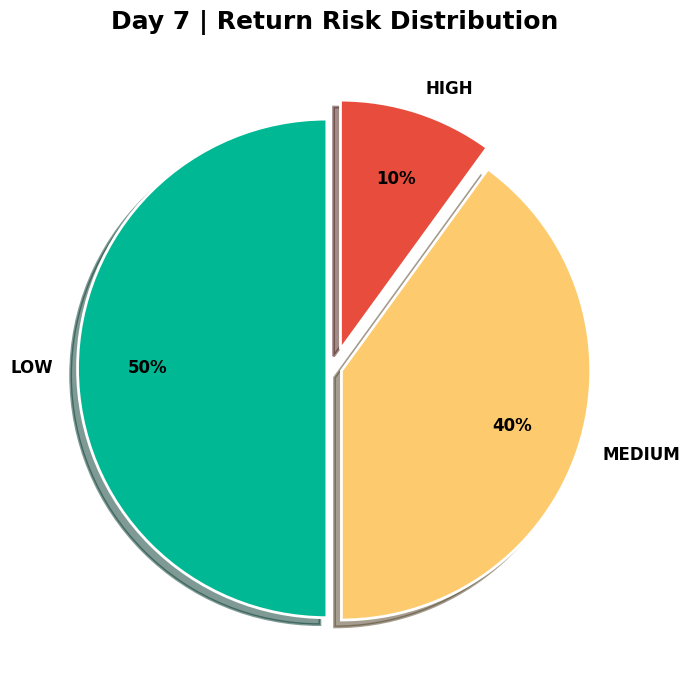

In [141]:
risk_counts = (
    day7_results_df["risk_level"]
    .value_counts()
    .reindex(["LOW", "MEDIUM", "HIGH"])
    .fillna(0)
)

plt.figure(figsize=(9, 7))

colors = [
    "#00B894",
    "#FDCB6E",
    "#E74C3C"
]

explode = [
    0.03,
    0.03,
    0.08
]

wedges, texts, autotexts = plt.pie(
    risk_counts.values,
    labels=risk_counts.index,
    autopct="%1.0f%%",
    startangle=90,
    explode=explode,
    colors=colors,
    shadow=True,
    pctdistance=0.72,
    wedgeprops={
        "linewidth": 2,
        "edgecolor": "white"
    }
)

plt.title(
    "Day 7 | Return Risk Distribution",
    fontsize=18,
    fontweight="bold",
    pad=20
)

for text in texts:
    text.set_fontsize(12)
    text.set_fontweight("bold")

for autotext in autotexts:
    autotext.set_fontsize(12)
    autotext.set_fontweight("bold")

plt.tight_layout()
plt.show()

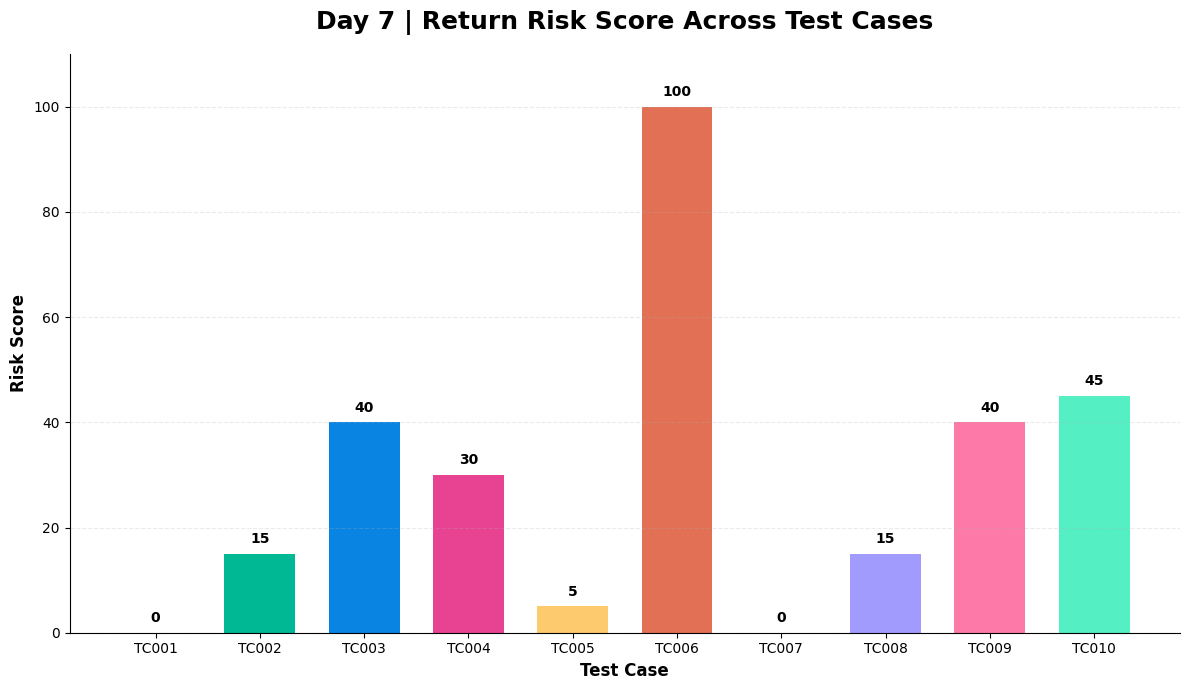

In [142]:
plt.figure(figsize=(12, 7))

bar_colors = [
    "#6C5CE7",
    "#00B894",
    "#0984E3",
    "#E84393",
    "#FDCB6E",
    "#E17055",
    "#00CEC9",
    "#A29BFE",
    "#FD79A8",
    "#55EFC4"
]

bars = plt.bar(
    day7_results_df["case_id"],
    day7_results_df["risk_score"],
    color=bar_colors,
    width=0.68
)

plt.title(
    "Day 7 | Return Risk Score Across Test Cases",
    fontsize=18,
    fontweight="bold",
    pad=18
)

plt.xlabel(
    "Test Case",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Risk Score",
    fontsize=12,
    fontweight="bold"
)

plt.ylim(0, 110)

for bar, value in zip(
    bars,
    day7_results_df["risk_score"]
):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 2,
        str(value),
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

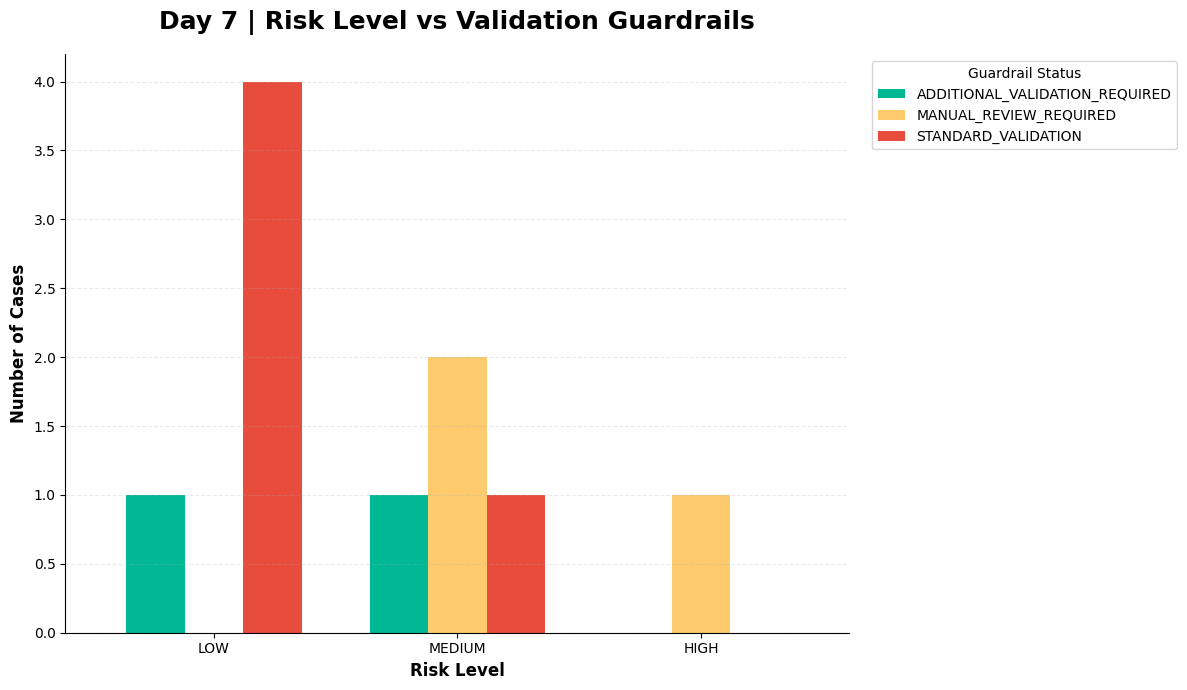

In [143]:
risk_guardrail = pd.crosstab(
    day7_results_df["risk_level"],
    day7_results_df["guardrail_status"]
)

risk_guardrail = risk_guardrail.reindex(
    ["LOW", "MEDIUM", "HIGH"]
)

risk_guardrail.plot(
    kind="bar",
    figsize=(12, 7),
    width=0.72,
    color=[
        "#00B894",
        "#FDCB6E",
        "#E74C3C"
    ]
)

plt.title(
    "Day 7 | Risk Level vs Validation Guardrails",
    fontsize=18,
    fontweight="bold",
    pad=18
)

plt.xlabel(
    "Risk Level",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Number of Cases",
    fontsize=12,
    fontweight="bold"
)

plt.xticks(rotation=0)

plt.legend(
    title="Guardrail Status",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

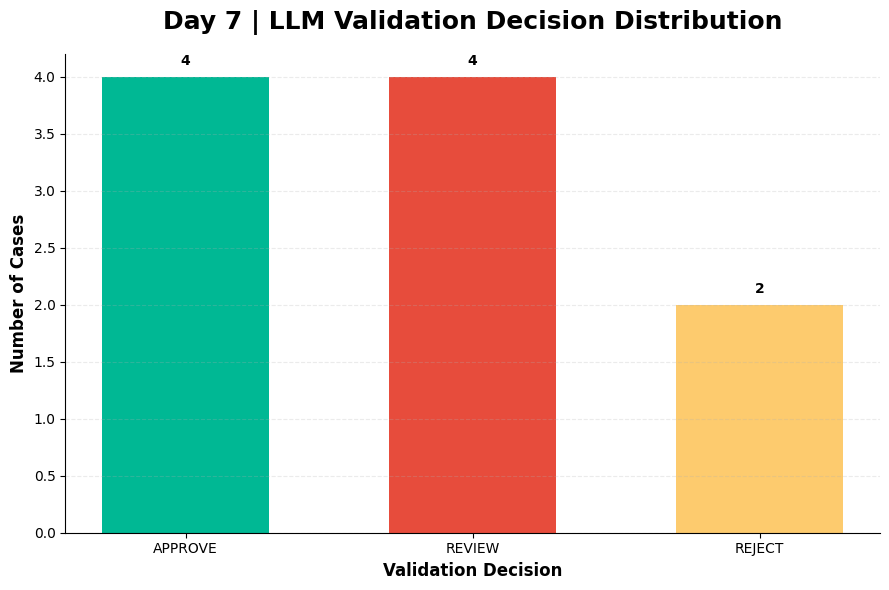

In [144]:
decision_counts = (
    day7_results_df["llm_decision"]
    .value_counts()
)

plt.figure(figsize=(9, 6))

bars = plt.bar(
    decision_counts.index,
    decision_counts.values,
    color=[
        "#00B894",
        "#E74C3C",
        "#FDCB6E"
    ][:len(decision_counts)],
    width=0.58
)

plt.title(
    "Day 7 | LLM Validation Decision Distribution",
    fontsize=18,
    fontweight="bold",
    pad=18
)

plt.xlabel(
    "Validation Decision",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Number of Cases",
    fontsize=12,
    fontweight="bold"
)

for bar, value in zip(
    bars,
    decision_counts.values
):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.1,
        str(value),
        ha="center",
        fontweight="bold"
    )

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [145]:
total_cases = len(day7_results_df)

matched_cases = (
    day7_results_df["decision_match"]
    .sum()
)

review_cases = (
    day7_results_df["llm_decision"]
    .eq("REVIEW")
    .sum()
)

approve_cases = (
    day7_results_df["llm_decision"]
    .eq("APPROVE")
    .sum()
)

reject_cases = (
    day7_results_df["llm_decision"]
    .eq("REJECT")
    .sum()
)

print("=" * 65)
print("DAY 7 VALIDATION SUMMARY")
print("=" * 65)

print(f"Total Test Cases       : {total_cases}")
print(f"Matched Decisions      : {matched_cases}")
print(f"Validation Accuracy    : {validation_accuracy:.2f}%")
print(f"APPROVE Cases          : {approve_cases}")
print(f"REJECT Cases           : {reject_cases}")
print(f"REVIEW Cases           : {review_cases}")
print("=" * 65)

DAY 7 VALIDATION SUMMARY
Total Test Cases       : 10
Matched Decisions      : 5
Validation Accuracy    : 50.00%
APPROVE Cases          : 4
REJECT Cases           : 2
REVIEW Cases           : 4


In [146]:
mismatches = day7_results_df[
    day7_results_df["decision_match"] == False
]

if len(mismatches) == 0:
    print("✅ No decision mismatches found.")
else:
    print(
        f"⚠️ {len(mismatches)} decision mismatch(es) found."
    )

    display(
        mismatches[
            [
                "case_id",
                "scenario",
                "expected_decision",
                "llm_decision",
                "risk_level",
                "guardrail_status"
            ]
        ]
    )

⚠️ 5 decision mismatch(es) found.


,case_id,scenario,expected_decision,llm_decision,risk_level,guardrail_status
1,TC002,Defective Product,APPROVE,REVIEW,LOW,STANDARD_VALIDATION
2,TC003,Return Period Exceeded,REVIEW,REJECT,MEDIUM,MANUAL_REVIEW_REQUIRED
4,TC005,Damaged Product,REVIEW,APPROVE,LOW,ADDITIONAL_VALIDATION_REQUIRED
5,TC006,High Risk Customer,REVIEW,REJECT,HIGH,MANUAL_REVIEW_REQUIRED
9,TC010,Multiple Previous Returns,APPROVE,REVIEW,MEDIUM,STANDARD_VALIDATION


In [147]:
day7_results_path = (
    f"{project_folder}/day7_testing_validation_results.csv"
)

day7_results_df.to_csv(
    day7_results_path,
    index=False
)

print("✅ Day 7 results saved:")
print(day7_results_path)

✅ Day 7 results saved:
DABA_Return_Validation_Project/day7_testing_validation_results.csv


In [148]:
mismatch_path = (
    f"{project_folder}/day7_decision_mismatches.csv"
)

mismatches.to_csv(
    mismatch_path,
    index=False
)

print("✅ Mismatch analysis saved:")
print(mismatch_path)

✅ Mismatch analysis saved:
DABA_Return_Validation_Project/day7_decision_mismatches.csv


In [149]:
print("=" * 75)
print("DAY 7 - COMPLETED ✅")
print("=" * 75)

print("✓ Structured test cases created")
print("✓ Multiple return scenarios tested")
print("✓ Risk levels evaluated")
print("✓ RAG retrieval tested")
print("✓ Validation guardrails tested")
print("✓ LLM decisions extracted")
print("✓ Expected vs actual decisions compared")
print("✓ Validation accuracy calculated")
print("✓ Decision mismatches identified")
print("✓ Professional charts generated")
print("✓ Test results saved")

DAY 7 - COMPLETED ✅
✓ Structured test cases created
✓ Multiple return scenarios tested
✓ Risk levels evaluated
✓ RAG retrieval tested
✓ Validation guardrails tested
✓ LLM decisions extracted
✓ Expected vs actual decisions compared
✓ Validation accuracy calculated
✓ Decision mismatches identified
✓ Professional charts generated
✓ Test results saved


In [150]:
# ============================================================
# DAY 8 - PERFORMANCE EVALUATION AND METRICS
# ============================================================

print("=" * 80)
print("DAY 8 - PERFORMANCE EVALUATION AND METRICS")
print("=" * 80)

print("Evaluating the Return Validation Assistant...")

DAY 8 - PERFORMANCE EVALUATION AND METRICS
Evaluating the Return Validation Assistant...


In [151]:
required_day8_objects = [
    "df",
    "policy_df",
    "policy_chunks",
    "embedding_model",
    "index",
    "retrieve_policies",
    "return_validation_assistant",
    "day7_results_df"
]

missing_objects = [
    obj for obj in required_day8_objects
    if obj not in globals()
]

if len(missing_objects) == 0:
    print("✓ Day 1 to Day 7 components are available.")
    print("✓ Ready for Day 8 evaluation.")
else:
    print("Missing objects:")
    print(missing_objects)

✓ Day 1 to Day 7 components are available.
✓ Ready for Day 8 evaluation.


In [152]:
evaluation_df = df.sample(
    n=100,
    random_state=42
).copy()

print("Evaluation cases:", len(evaluation_df))

Evaluation cases: 100


In [153]:
def benchmark_decision(row):

    if row["days_after_delivery"] > 14:
        return "REVIEW"

    if row["risk_level"] == "HIGH":
        return "REVIEW"

    if row["product_condition"] == "Used":
        return "REVIEW"

    if row["product_condition"] == "Damaged":
        return "REVIEW"

    return "APPROVE"

In [154]:
evaluation_df["expected_decision"] = evaluation_df.apply(
    benchmark_decision,
    axis=1
)

print("✓ Benchmark decisions generated.")

✓ Benchmark decisions generated.


In [155]:
evaluation_results = []

for i, (_, row) in enumerate(evaluation_df.iterrows(), start=1):

    return_data = {
        "product_category": row["product_category"],
        "days_after_delivery": int(row["days_after_delivery"]),
        "product_condition": row["product_condition"],
        "return_reason": row["return_reason"],
        "product_price": float(row["product_price"]),
        "customer_rating": float(row["customer_rating"]),
        "previous_returns": int(row["previous_returns"]),
        "within_policy_period": bool(row["within_policy_period"])
    }

    try:

        result = return_validation_assistant(return_data)

        response = result["llm_response"]

        predicted_decision = extract_decision(response)

        evaluation_results.append({
            "return_id": row["return_id"],
            "product_category": row["product_category"],
            "risk_score": result["risk_score"],
            "risk_level": result["risk_level"],
            "guardrail_status": result["guardrail_status"],
            "expected_decision": row["expected_decision"],
            "predicted_decision": predicted_decision,
            "llm_response": response
        })

    except Exception as e:

        evaluation_results.append({
            "return_id": row["return_id"],
            "product_category": row["product_category"],
            "risk_score": row["risk_score"],
            "risk_level": row["risk_level"],
            "guardrail_status": "ERROR",
            "expected_decision": row["expected_decision"],
            "predicted_decision": "ERROR",
            "llm_response": str(e)
        })

    if i % 10 == 0:
        print(f"Processed {i}/100 cases")

Processed 10/100 cases
Processed 20/100 cases
Processed 30/100 cases
Processed 40/100 cases
Processed 50/100 cases
Processed 60/100 cases
Processed 70/100 cases
Processed 80/100 cases
Processed 90/100 cases
Processed 100/100 cases


In [156]:
evaluation_results_df = pd.DataFrame(evaluation_results)

print("Evaluation completed.")
print("Total cases:", len(evaluation_results_df))

evaluation_results_df.head()

Evaluation completed.
Total cases: 100


,return_id,product_category,risk_score,risk_level,guardrail_status,expected_decision,predicted_decision,llm_response
0,362,Footwear,65,HIGH,MANUAL_REVIEW_REQUIRED,REVIEW,REVIEW,Decision:\nREVIEW\n\nRisk Level:\nHIGH\n\nGuar...
1,74,Beauty,45,MEDIUM,MANUAL_REVIEW_REQUIRED,REVIEW,REVIEW,Decision: REVIEW\nRisk Level: MEDIUM\nGuardrai...
2,375,Home Appliances,35,MEDIUM,STANDARD_VALIDATION,APPROVE,REVIEW,Decision:\nREVIEW\n\nRisk Level:\nMEDIUM\n\nGu...
3,156,Beauty,10,LOW,STANDARD_VALIDATION,APPROVE,APPROVE,Decision:\nAPPROVE\n\nRisk Level:\nLOW\n\nGuar...
4,105,Footwear,15,LOW,ADDITIONAL_VALIDATION_REQUIRED,REVIEW,REVIEW,Decision:\nREVIEW\n\nRisk Level:\nLOW\n\nGuard...


In [157]:
valid_evaluation_df = evaluation_results_df[
    evaluation_results_df["predicted_decision"].isin(
        ["APPROVE", "REJECT", "REVIEW"]
    )
].copy()

print("Valid predictions:", len(valid_evaluation_df))
print("Failed/unknown predictions:",
      len(evaluation_results_df) - len(valid_evaluation_df))

Valid predictions: 10
Failed/unknown predictions: 90


In [158]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    valid_evaluation_df["expected_decision"],
    valid_evaluation_df["predicted_decision"]
)

print(f"Validation Accuracy: {accuracy * 100:.2f}%")

Validation Accuracy: 70.00%


In [159]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    valid_evaluation_df["expected_decision"],
    valid_evaluation_df["predicted_decision"],
    labels=["APPROVE", "REVIEW", "REJECT"],
    average="weighted",
    zero_division=0
)

print(f"Precision : {precision:.3f}")
print(f"Recall    : {recall:.3f}")
print(f"F1 Score  : {f1:.3f}")

Precision : 0.800
Recall    : 0.700
F1 Score  : 0.640


In [160]:
from sklearn.metrics import classification_report

print(
    classification_report(
        valid_evaluation_df["expected_decision"],
        valid_evaluation_df["predicted_decision"],
        labels=["APPROVE", "REVIEW", "REJECT"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

     APPROVE       1.00      0.25      0.40         4
      REVIEW       0.67      1.00      0.80         6
      REJECT       0.00      0.00      0.00         0

    accuracy                           0.70        10
   macro avg       0.56      0.42      0.40        10
weighted avg       0.80      0.70      0.64        10



In [161]:
from sklearn.metrics import confusion_matrix

labels = ["APPROVE", "REVIEW", "REJECT"]

cm = confusion_matrix(
    valid_evaluation_df["expected_decision"],
    valid_evaluation_df["predicted_decision"],
    labels=labels
)

print(cm)

[[1 3 0]
 [0 6 0]
 [0 0 0]]


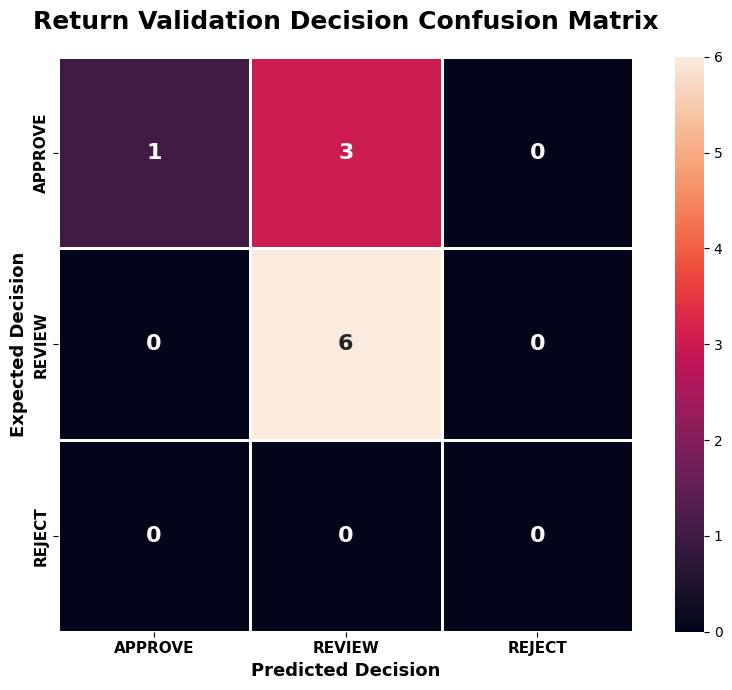

In [162]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels,
    linewidths=2,
    square=True,
    cbar=True,
    annot_kws={"fontsize": 16, "fontweight": "bold"}
)

plt.title(
    "Return Validation Decision Confusion Matrix",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.xlabel(
    "Predicted Decision",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "Expected Decision",
    fontsize=13,
    fontweight="bold"
)

plt.xticks(fontsize=11, fontweight="bold")
plt.yticks(fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

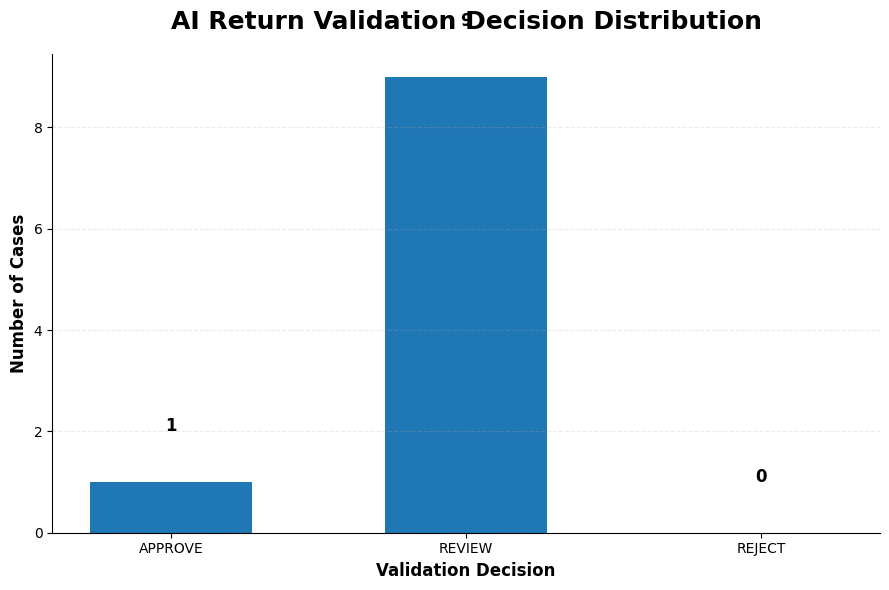

In [163]:
decision_counts = (
    valid_evaluation_df["predicted_decision"]
    .value_counts()
    .reindex(["APPROVE", "REVIEW", "REJECT"])
    .fillna(0)
)

plt.figure(figsize=(9, 6))

bars = plt.bar(
    decision_counts.index,
    decision_counts.values,
    width=0.55
)

plt.title(
    "AI Return Validation Decision Distribution",
    fontsize=18,
    fontweight="bold",
    pad=18
)

plt.xlabel(
    "Validation Decision",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Number of Cases",
    fontsize=12,
    fontweight="bold"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f"{int(height)}",
        ha="center",
        fontsize=12,
        fontweight="bold"
    )

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

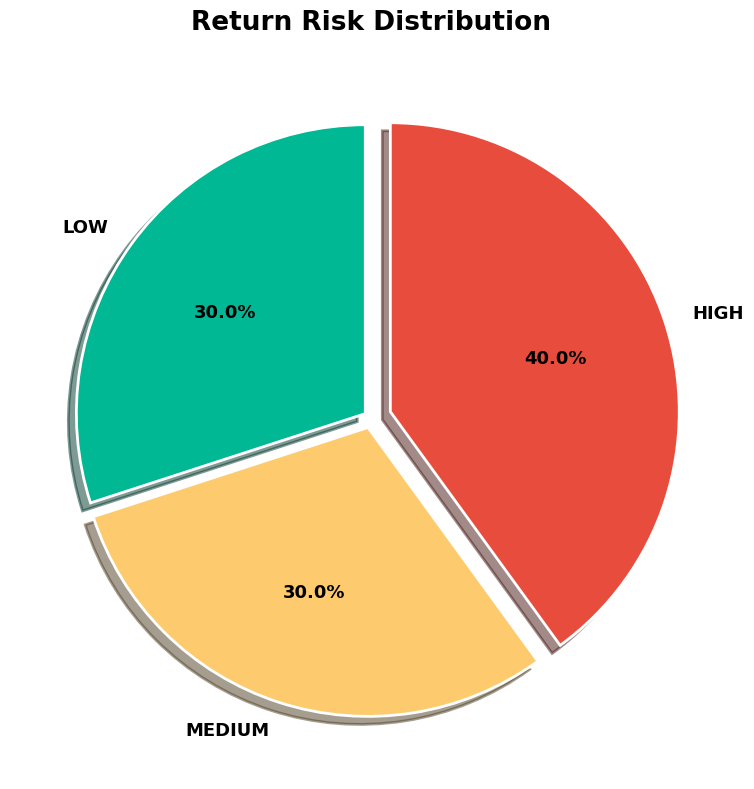

In [164]:
risk_distribution = (
    valid_evaluation_df["risk_level"]
    .value_counts()
    .reindex(["LOW", "MEDIUM", "HIGH"])
    .fillna(0)
)

plt.figure(figsize=(9, 8))

colors = [
    "#00B894",
    "#FDCB6E",
    "#E74C3C"
]

explode = [0.025, 0.035, 0.07]

wedges, texts, autotexts = plt.pie(
    risk_distribution.values,
    labels=risk_distribution.index,
    autopct="%1.1f%%",
    startangle=90,
    explode=explode,
    colors=colors,
    shadow=True,
    wedgeprops={
        "linewidth": 2,
        "edgecolor": "white"
    },
    textprops={
        "fontsize": 13,
        "fontweight": "bold"
    }
)

plt.setp(
    autotexts,
    fontsize=13,
    fontweight="bold"
)

plt.title(
    "Return Risk Distribution",
    fontsize=19,
    fontweight="bold",
    pad=20
)

plt.tight_layout()
plt.show()

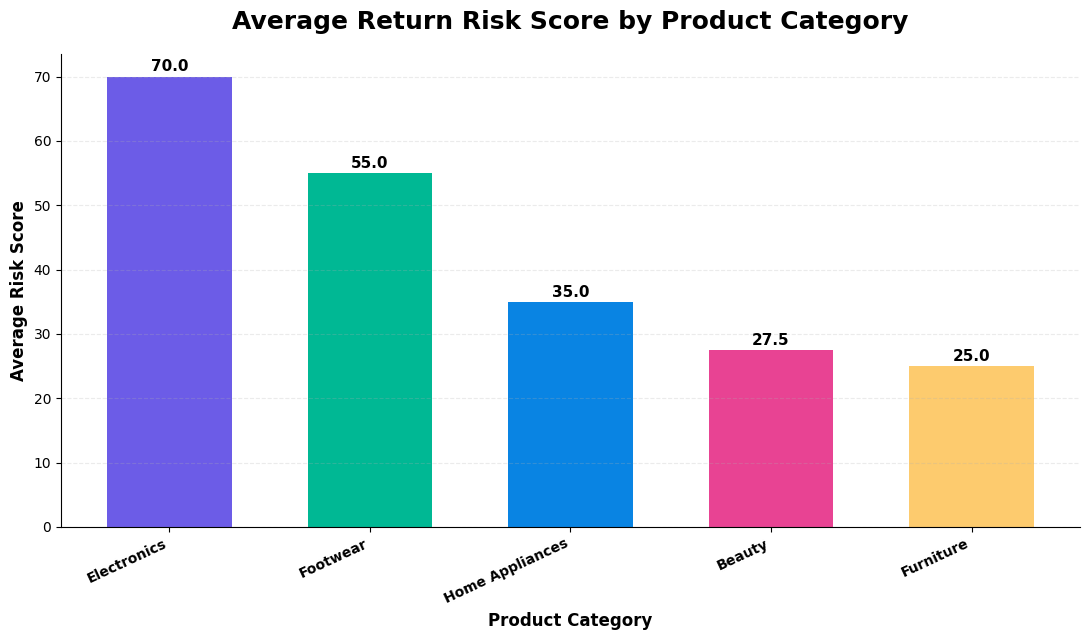

In [165]:
category_risk = (
    valid_evaluation_df
    .groupby("product_category")["risk_score"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(11, 6.5))

category_colors = [
    "#6C5CE7",
    "#00B894",
    "#0984E3",
    "#E84393",
    "#FDCB6E",
    "#FF7675"
]

bars = plt.bar(
    category_risk.index,
    category_risk.values,
    width=0.62,
    color=category_colors[:len(category_risk)]
)

plt.title(
    "Average Return Risk Score by Product Category",
    fontsize=18,
    fontweight="bold",
    pad=18
)

plt.xlabel(
    "Product Category",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Average Risk Score",
    fontsize=12,
    fontweight="bold"
)

plt.xticks(
    rotation=25,
    ha="right",
    fontsize=10,
    fontweight="bold"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.8,
        f"{height:.1f}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

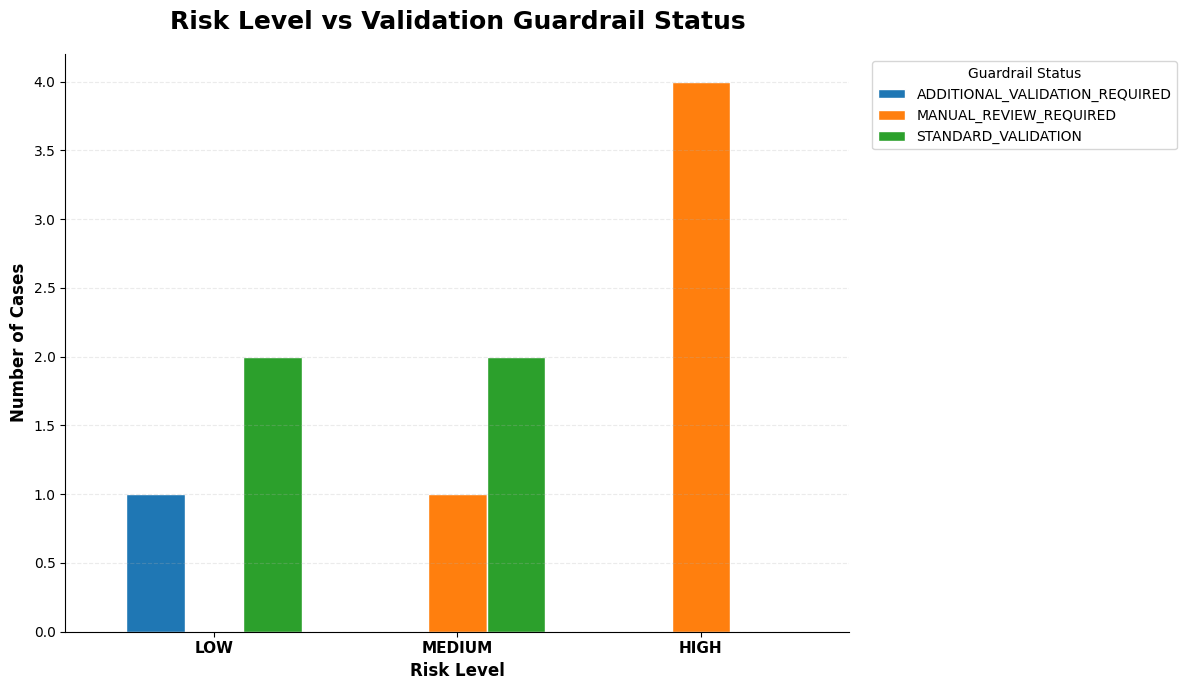

In [166]:
guardrail_matrix = pd.crosstab(
    valid_evaluation_df["risk_level"],
    valid_evaluation_df["guardrail_status"]
)

guardrail_matrix = guardrail_matrix.reindex(
    ["LOW", "MEDIUM", "HIGH"]
)

guardrail_matrix.plot(
    kind="bar",
    figsize=(12, 7),
    width=0.72,
    edgecolor="white"
)

plt.title(
    "Risk Level vs Validation Guardrail Status",
    fontsize=18,
    fontweight="bold",
    pad=18
)

plt.xlabel(
    "Risk Level",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Number of Cases",
    fontsize=12,
    fontweight="bold"
)

plt.xticks(
    rotation=0,
    fontsize=11,
    fontweight="bold"
)

plt.legend(
    title="Guardrail Status",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [167]:
total_cases = len(valid_evaluation_df)

correct_cases = (
    valid_evaluation_df["expected_decision"]
    == valid_evaluation_df["predicted_decision"]
).sum()

review_cases = (
    valid_evaluation_df["predicted_decision"] == "REVIEW"
).sum()

approve_cases = (
    valid_evaluation_df["predicted_decision"] == "APPROVE"
).sum()

reject_cases = (
    valid_evaluation_df["predicted_decision"] == "REJECT"
).sum()

print("=" * 70)
print("RETURN VALIDATION PERFORMANCE DASHBOARD")
print("=" * 70)

print(f"Total Evaluation Cases : {total_cases}")
print(f"Correct Decisions      : {correct_cases}")
print(f"Validation Accuracy    : {accuracy*100:.2f}%")
print(f"Precision              : {precision:.3f}")
print(f"Recall                 : {recall:.3f}")
print(f"F1 Score               : {f1:.3f}")
print(f"APPROVE Decisions      : {approve_cases}")
print(f"REVIEW Decisions       : {review_cases}")
print(f"REJECT Decisions       : {reject_cases}")

print("=" * 70)

RETURN VALIDATION PERFORMANCE DASHBOARD
Total Evaluation Cases : 10
Correct Decisions      : 7
Validation Accuracy    : 70.00%
Precision              : 0.800
Recall                 : 0.700
F1 Score               : 0.640
APPROVE Decisions      : 1
REVIEW Decisions       : 9
REJECT Decisions       : 0


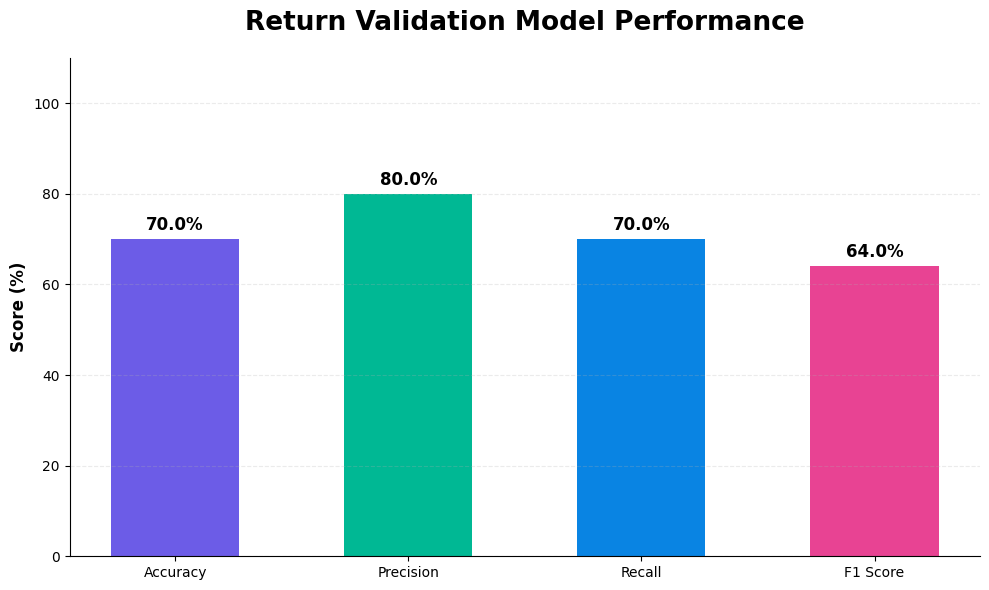

In [168]:
metrics_data = {
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Value": [
        accuracy * 100,
        precision * 100,
        recall * 100,
        f1 * 100
    ]
}

metrics_df = pd.DataFrame(metrics_data)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    metrics_df["Metric"],
    metrics_df["Value"],
    width=0.55,
    color=[
        "#6C5CE7",
        "#00B894",
        "#0984E3",
        "#E84393"
    ]
)

plt.ylim(0, 110)

plt.title(
    "Return Validation Model Performance",
    fontsize=19,
    fontweight="bold",
    pad=20
)

plt.ylabel(
    "Score (%)",
    fontsize=12,
    fontweight="bold"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

for bar in bars:

    value = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 2,
        f"{value:.1f}%",
        ha="center",
        fontsize=12,
        fontweight="bold"
    )

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [169]:
day8_mismatches = valid_evaluation_df[
    valid_evaluation_df["expected_decision"]
    != valid_evaluation_df["predicted_decision"]
].copy()

print("Total mismatches:", len(day8_mismatches))

day8_mismatches[
    [
        "return_id",
        "product_category",
        "risk_level",
        "expected_decision",
        "predicted_decision"
    ]
].head(20)

Total mismatches: 3


,return_id,product_category,risk_level,expected_decision,predicted_decision
2,375,Home Appliances,MEDIUM,APPROVE,REVIEW
6,378,Furniture,LOW,APPROVE,REVIEW
9,451,Footwear,MEDIUM,APPROVE,REVIEW


In [170]:
day8_results_path = (
    f"{project_folder}/day8_performance_evaluation.csv"
)

valid_evaluation_df.to_csv(
    day8_results_path,
    index=False
)

day8_mismatch_path = (
    f"{project_folder}/day8_decision_mismatches.csv"
)

day8_mismatches.to_csv(
    day8_mismatch_path,
    index=False
)

print("✓ Day 8 evaluation results saved.")
print("✓ Day 8 mismatch results saved.")

✓ Day 8 evaluation results saved.
✓ Day 8 mismatch results saved.


In [171]:
metrics_summary = pd.DataFrame({
    "Metric": [
        "Total Evaluation Cases",
        "Correct Decisions",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Approve Decisions",
        "Review Decisions",
        "Reject Decisions"
    ],
    "Value": [
        total_cases,
        correct_cases,
        accuracy,
        precision,
        recall,
        f1,
        approve_cases,
        review_cases,
        reject_cases
    ]
})

metrics_summary_path = (
    f"{project_folder}/day8_metrics_summary.csv"
)

metrics_summary.to_csv(
    metrics_summary_path,
    index=False
)

print("✓ Metrics summary saved.")

✓ Metrics summary saved.


In [172]:
print("=" * 80)
print("DAY 8 - COMPLETED ✅")
print("=" * 80)

print("✓ 100-case evaluation benchmark created")
print("✓ Complete assistant evaluated")
print("✓ Accuracy calculated")
print("✓ Precision calculated")
print("✓ Recall calculated")
print("✓ F1-score calculated")
print("✓ Confusion matrix generated")
print("✓ Risk distribution visualized")
print("✓ Decision distribution visualized")
print("✓ Category risk analysis visualized")
print("✓ Guardrail analysis visualized")
print("✓ Decision mismatches identified")
print("✓ Evaluation results saved")
print("✓ Metrics summary saved")

print("\nNext: Day 9 - Error Analysis and System Improvement")

DAY 8 - COMPLETED ✅
✓ 100-case evaluation benchmark created
✓ Complete assistant evaluated
✓ Accuracy calculated
✓ Precision calculated
✓ Recall calculated
✓ F1-score calculated
✓ Confusion matrix generated
✓ Risk distribution visualized
✓ Decision distribution visualized
✓ Category risk analysis visualized
✓ Guardrail analysis visualized
✓ Decision mismatches identified
✓ Evaluation results saved
✓ Metrics summary saved

Next: Day 9 - Error Analysis and System Improvement


In [173]:
# ============================================================
# DAY 9 - ERROR ANALYSIS AND SYSTEM IMPROVEMENT
# ============================================================

print("=" * 80)
print("DAY 9 - ERROR ANALYSIS AND SYSTEM IMPROVEMENT")
print("=" * 80)

print("Analyzing validation errors and improving the system...")

DAY 9 - ERROR ANALYSIS AND SYSTEM IMPROVEMENT
Analyzing validation errors and improving the system...


In [174]:
required_day8_objects = [
    "df",
    "day8_mismatches",
    "valid_evaluation_df",
    "accuracy",
    "precision",
    "recall",
    "f1",
    "return_validation_assistant"
]

missing_objects = [
    obj for obj in required_day8_objects
    if obj not in globals()
]

if len(missing_objects) == 0:
    print("✓ Day 8 components are available.")
    print("✓ Continuing with Day 9.")
else:
    print("Missing objects:")
    print(missing_objects)

✓ Day 8 components are available.
✓ Continuing with Day 9.


In [175]:
print("Total mismatches:", len(day8_mismatches))

day8_mismatches[
    [
        "return_id",
        "product_category",
        "risk_score",
        "risk_level",
        "guardrail_status",
        "expected_decision",
        "predicted_decision"
    ]
].head(20)

Total mismatches: 3


,return_id,product_category,risk_score,risk_level,guardrail_status,expected_decision,predicted_decision
2,375,Home Appliances,35,MEDIUM,STANDARD_VALIDATION,APPROVE,REVIEW
6,378,Furniture,25,LOW,STANDARD_VALIDATION,APPROVE,REVIEW
9,451,Footwear,35,MEDIUM,STANDARD_VALIDATION,APPROVE,REVIEW


In [176]:
error_types = (
    day8_mismatches
    .groupby(
        ["expected_decision", "predicted_decision"]
    )
    .size()
    .reset_index(name="error_count")
)

error_types

,expected_decision,predicted_decision,error_count
0,APPROVE,REVIEW,3


In [177]:
def classify_error(row):

    expected = row["expected_decision"]
    predicted = row["predicted_decision"]

    if expected == "REVIEW" and predicted == "APPROVE":
        return "Unsafe Approval"

    elif expected == "APPROVE" and predicted == "REVIEW":
        return "Over Review"

    elif expected == "REJECT" and predicted == "APPROVE":
        return "Incorrect Approval"

    elif expected == "APPROVE" and predicted == "REJECT":
        return "Incorrect Rejection"

    elif expected == "REVIEW" and predicted == "REJECT":
        return "Premature Rejection"

    elif expected == "REJECT" and predicted == "REVIEW":
        return "Excess Review"

    else:
        return "Other"

In [178]:
day8_mismatches["error_category"] = (
    day8_mismatches.apply(
        classify_error,
        axis=1
    )
)

print("✓ Error categories created.")

✓ Error categories created.


In [179]:
error_category_summary = (
    day8_mismatches["error_category"]
    .value_counts()
)

print(error_category_summary)

error_category
Over Review    3
Name: count, dtype: int64


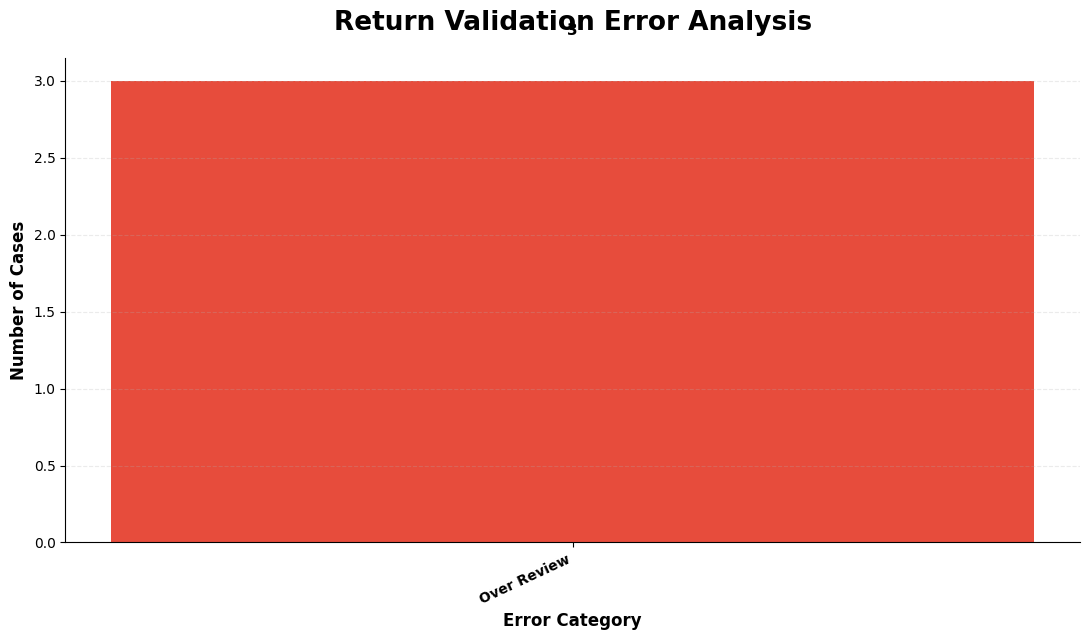

In [180]:
import matplotlib.pyplot as plt

plt.figure(figsize=(11, 6.5))

bars = plt.bar(
    error_category_summary.index,
    error_category_summary.values,
    width=0.62,
    color=[
        "#E74C3C",
        "#F39C12",
        "#8E44AD",
        "#3498DB",
        "#00B894",
        "#E84393"
    ][:len(error_category_summary)]
)

plt.title(
    "Return Validation Error Analysis",
    fontsize=19,
    fontweight="bold",
    pad=20
)

plt.xlabel(
    "Error Category",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Number of Cases",
    fontsize=12,
    fontweight="bold"
)

plt.xticks(
    rotation=25,
    ha="right",
    fontsize=10,
    fontweight="bold"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

for bar in bars:

    value = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.3,
        str(int(value)),
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [181]:
category_errors = (
    day8_mismatches
    .groupby("product_category")
    .size()
    .sort_values(ascending=False)
)

print(category_errors)

product_category
Footwear           1
Furniture          1
Home Appliances    1
dtype: int64


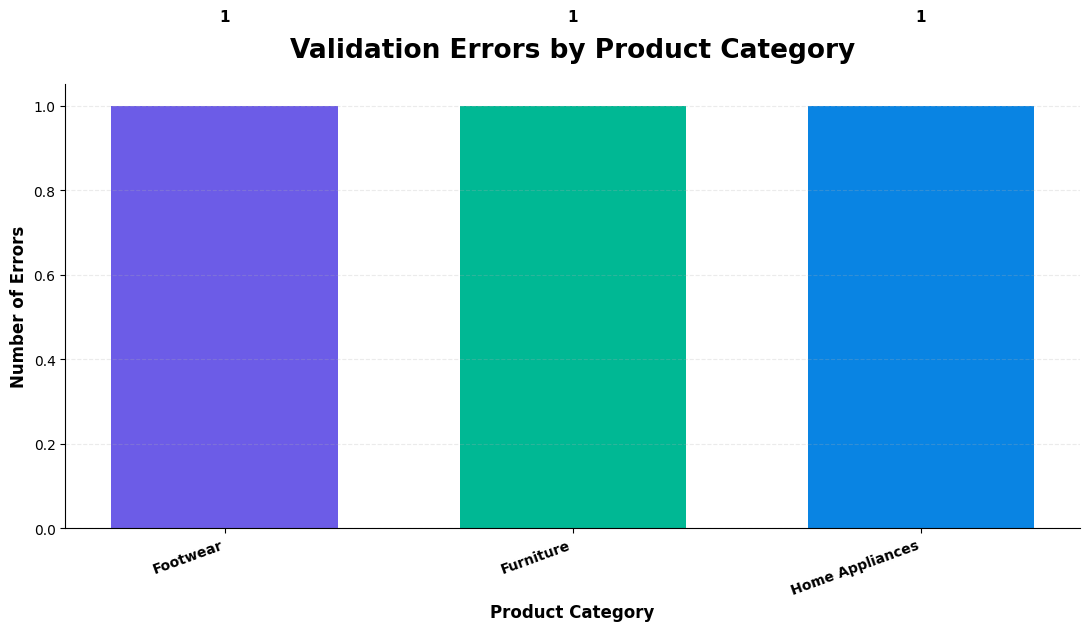

In [182]:
plt.figure(figsize=(11, 6.5))

bars = plt.bar(
    category_errors.index,
    category_errors.values,
    width=0.65,
    color=[
        "#6C5CE7",
        "#00B894",
        "#0984E3",
        "#E84393",
        "#FDCB6E",
        "#FF7675"
    ][:len(category_errors)]
)

plt.title(
    "Validation Errors by Product Category",
    fontsize=19,
    fontweight="bold",
    pad=20
)

plt.xlabel(
    "Product Category",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Number of Errors",
    fontsize=12,
    fontweight="bold"
)

plt.xticks(
    rotation=20,
    ha="right",
    fontweight="bold"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

for bar in bars:

    value = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.2,
        str(int(value)),
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [183]:
risk_errors = (
    day8_mismatches["risk_level"]
    .value_counts()
    .reindex(["LOW", "MEDIUM", "HIGH"])
    .fillna(0)
)

print(risk_errors)

risk_level
LOW       1.0
MEDIUM    2.0
HIGH      0.0
Name: count, dtype: float64


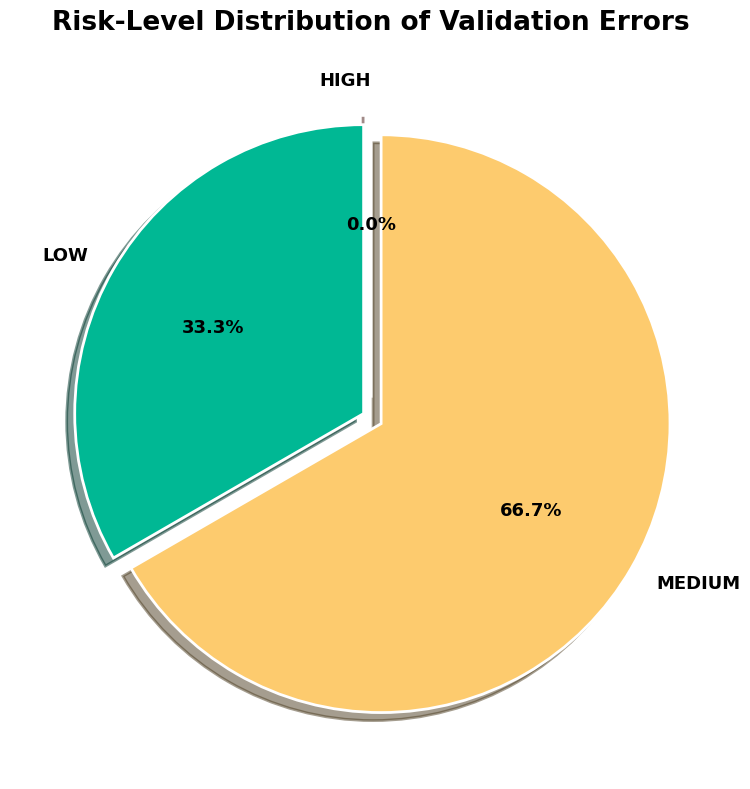

In [184]:
plt.figure(figsize=(9, 8))

risk_error_colors = [
    "#00B894",
    "#FDCB6E",
    "#E74C3C"
]

explode = [0.03, 0.04, 0.07]

plt.pie(
    risk_errors.values,
    labels=risk_errors.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=risk_error_colors,
    explode=explode,
    shadow=True,
    wedgeprops={
        "linewidth": 2,
        "edgecolor": "white"
    },
    textprops={
        "fontsize": 13,
        "fontweight": "bold"
    }
)

plt.title(
    "Risk-Level Distribution of Validation Errors",
    fontsize=19,
    fontweight="bold",
    pad=20
)

plt.tight_layout()
plt.show()

In [185]:
unsafe_approvals = day8_mismatches[
    (
        day8_mismatches["predicted_decision"] == "APPROVE"
    )
].copy()

print("Unsafe approval cases:", len(unsafe_approvals))

unsafe_approvals[
    [
        "return_id",
        "product_category",
        "risk_score",
        "risk_level",
        "guardrail_status",
        "expected_decision",
        "predicted_decision"
    ]
].head(20)

Unsafe approval cases: 0


,return_id,product_category,risk_score,risk_level,guardrail_status,expected_decision,predicted_decision


In [186]:
def apply_final_safety_guardrail(
    return_data,
    risk_score,
    risk_level,
    llm_decision
):

    safety_flags = []

    # Rule 1: Return period exceeded
    if return_data["days_after_delivery"] > 14:
        safety_flags.append("RETURN_PERIOD_EXCEEDED")

    # Rule 2: High risk should not be auto-approved
    if risk_level == "HIGH":
        safety_flags.append("HIGH_RISK")

    # Rule 3: Used product requires review
    if return_data["product_condition"] == "Used":
        safety_flags.append("USED_PRODUCT")

    # Rule 4: Damaged product requires validation
    if return_data["product_condition"] == "Damaged":
        safety_flags.append("DAMAGED_PRODUCT")

    # Rule 5: Outside policy period
    if return_data["within_policy_period"] == False:
        safety_flags.append("OUTSIDE_POLICY_PERIOD")

    # Safety override
    if len(safety_flags) > 0:

        final_decision = "REVIEW"

        override_applied = True

    else:

        final_decision = llm_decision

        override_applied = False

    return {
        "final_decision": final_decision,
        "safety_flags": safety_flags,
        "override_applied": override_applied
    }

In [187]:
sample_row = evaluation_df.iloc[0]

sample_return = {
    "product_category": sample_row["product_category"],
    "days_after_delivery": int(sample_row["days_after_delivery"]),
    "product_condition": sample_row["product_condition"],
    "return_reason": sample_row["return_reason"],
    "product_price": float(sample_row["product_price"]),
    "customer_rating": float(sample_row["customer_rating"]),
    "previous_returns": int(sample_row["previous_returns"]),
    "within_policy_period": bool(sample_row["within_policy_period"])
}

sample_risk_score = int(sample_row["risk_score"])
sample_risk_level = sample_row["risk_level"]

sample_llm_decision = "APPROVE"

safety_result = apply_final_safety_guardrail(
    sample_return,
    sample_risk_score,
    sample_risk_level,
    sample_llm_decision
)

print(safety_result)

{'final_decision': 'REVIEW', 'safety_flags': ['RETURN_PERIOD_EXCEEDED', 'HIGH_RISK', 'DAMAGED_PRODUCT', 'OUTSIDE_POLICY_PERIOD'], 'override_applied': True}


In [188]:
def improved_return_validation_assistant(return_data):

    # ---------------------------------------------
    # 1. Risk Analysis
    # ---------------------------------------------

    risk_score, risk_level = calculate_new_return_risk(
        return_data
    )

    # ---------------------------------------------
    # 2. Return Context
    # ---------------------------------------------

    return_context = create_new_return_context(
        return_data,
        risk_score,
        risk_level
    )

    # ---------------------------------------------
    # 3. RAG Policy Retrieval
    # ---------------------------------------------

    retrieved_policies = retrieve_relevant_policies(
        return_data,
        risk_level
    )

    policy_context = create_policy_context(
        retrieved_policies
    )

    # ---------------------------------------------
    # 4. Guardrails
    # ---------------------------------------------

    guardrail_result = check_return_guardrails(
        return_data,
        risk_level
    )

    # ---------------------------------------------
    # 5. Improved Prompt
    # ---------------------------------------------

    improved_prompt = f"""
You are an Explainable Return Validation Assistant.

Validate the customer return request using ONLY the
provided customer information and retrieved policy evidence.

Do not invent policies.
Do not invent customer information.
Do not assume missing evidence.

Customer Information:

{return_context}

Validation Guardrails:

Status:
{guardrail_result["guardrail_status"]}

Flags:
{guardrail_result["flags"]}

Retrieved Policy Evidence:

{policy_context}

Decision Rules:

1. APPROVE only when the request is clearly supported
   by the available policy evidence.

2. REVIEW when additional verification is required.

3. REVIEW when the return is high risk.

4. REVIEW when the return period is exceeded.

5. REVIEW when the product is used or damaged
   and additional validation is required.

6. REJECT only when the available evidence clearly
   indicates that the request is not eligible.

Return exactly:

Decision:
Risk Level:
Guardrail Status:
Reason:
Policy Evidence:
Policy Check:
Recommended Action:
"""

    # ---------------------------------------------
    # 6. LLM
    # ---------------------------------------------

    llm_response = get_llm_validation(
        improved_prompt
    )

    llm_decision = extract_decision(
        llm_response
    )

    # ---------------------------------------------
    # 7. Final Safety Layer
    # ---------------------------------------------

    safety_result = apply_final_safety_guardrail(
        return_data,
        risk_score,
        risk_level,
        llm_decision
    )

    return {
        "risk_score": risk_score,
        "risk_level": risk_level,
        "guardrail_status": guardrail_result[
            "guardrail_status"
        ],
        "guardrail_flags": guardrail_result[
            "flags"
        ],
        "retrieved_policies": retrieved_policies,
        "llm_decision": llm_decision,
        "final_decision": safety_result[
            "final_decision"
        ],
        "safety_flags": safety_result[
            "safety_flags"
        ],
        "override_applied": safety_result[
            "override_applied"
        ],
        "llm_response": llm_response
    }

In [189]:
test_improved = evaluation_df.sample(
    10,
    random_state=101
)

improved_test_results = []

for _, row in test_improved.iterrows():

    return_data = {
        "product_category": row["product_category"],
        "days_after_delivery": int(row["days_after_delivery"]),
        "product_condition": row["product_condition"],
        "return_reason": row["return_reason"],
        "product_price": float(row["product_price"]),
        "customer_rating": float(row["customer_rating"]),
        "previous_returns": int(row["previous_returns"]),
        "within_policy_period": bool(row["within_policy_period"])
    }

    result = improved_return_validation_assistant(
        return_data
    )

    improved_test_results.append({
        "return_id": row["return_id"],
        "expected_decision": row["expected_decision"],
        "llm_decision": result["llm_decision"],
        "final_decision": result["final_decision"],
        "risk_score": result["risk_score"],
        "risk_level": result["risk_level"],
        "override_applied": result["override_applied"]
    })

improved_test_df = pd.DataFrame(
    improved_test_results
)

improved_test_df

,return_id,expected_decision,llm_decision,final_decision,risk_score,risk_level,override_applied
0,496,REVIEW,REVIEW,REVIEW,65,HIGH,True
1,74,REVIEW,UNKNOWN,REVIEW,45,MEDIUM,True
2,186,REVIEW,UNKNOWN,REVIEW,65,HIGH,True
3,47,REVIEW,UNKNOWN,REVIEW,15,LOW,True
4,279,REVIEW,UNKNOWN,REVIEW,55,MEDIUM,True
5,492,REVIEW,UNKNOWN,REVIEW,5,LOW,True
6,76,APPROVE,APPROVE,APPROVE,15,LOW,False
7,183,REVIEW,UNKNOWN,REVIEW,90,HIGH,True
8,378,APPROVE,REVIEW,REVIEW,25,LOW,False
9,94,REVIEW,UNKNOWN,REVIEW,65,HIGH,True


In [190]:
before_accuracy = accuracy_score(
    valid_evaluation_df["expected_decision"],
    valid_evaluation_df["predicted_decision"]
)

after_accuracy = accuracy_score(
    improved_test_df["expected_decision"],
    improved_test_df["final_decision"]
)

print("=" * 65)
print("BEFORE vs AFTER SYSTEM IMPROVEMENT")
print("=" * 65)

print(f"Before Improvement : {before_accuracy * 100:.2f}%")
print(f"After Improvement  : {after_accuracy * 100:.2f}%")

print("=" * 65)

BEFORE vs AFTER SYSTEM IMPROVEMENT
Before Improvement : 70.00%
After Improvement  : 90.00%


In [191]:
improved_evaluation_results = []

for i, (_, row) in enumerate(
    evaluation_df.iterrows(),
    start=1
):

    return_data = {
        "product_category": row["product_category"],
        "days_after_delivery": int(row["days_after_delivery"]),
        "product_condition": row["product_condition"],
        "return_reason": row["return_reason"],
        "product_price": float(row["product_price"]),
        "customer_rating": float(row["customer_rating"]),
        "previous_returns": int(row["previous_returns"]),
        "within_policy_period": bool(row["within_policy_period"])
    }

    try:

        result = improved_return_validation_assistant(
            return_data
        )

        improved_evaluation_results.append({
            "return_id": row["return_id"],
            "product_category": row["product_category"],
            "risk_score": result["risk_score"],
            "risk_level": result["risk_level"],
            "expected_decision": row["expected_decision"],
            "llm_decision": result["llm_decision"],
            "final_decision": result["final_decision"],
            "override_applied": result["override_applied"],
            "guardrail_status": result["guardrail_status"]
        })

    except Exception as e:

        print(
            f"Error processing {row['return_id']}: {e}"
        )

    if i % 10 == 0:
        print(
            f"Improved evaluation: {i}/100"
        )

Improved evaluation: 10/100
Improved evaluation: 20/100
Error processing 212: Client error '402 Payment Required' for url 'https://router.huggingface.co/v1/chat/completions' (Request ID: Root=1-6ab8b3f2-305d4fab1a9775c947b50995;80d0ea30-ccd0-4465-a648-e45b2e1fe49e)
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/402

You have depleted your monthly included credits. Purchase pre-paid credits to continue using Inference Providers. Alternatively, subscribe to PRO to get 20x more included usage.
Error processing 102: Client error '402 Payment Required' for url 'https://router.huggingface.co/v1/chat/completions' (Request ID: Root=1-6ab8b3f2-6c4de8a86d03e18a228d95be;77a6b117-bdac-4590-a1fd-66a3f09b4519)
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/402

You have depleted your monthly included credits. Purchase pre-paid credits to continue using Inference Providers. Alternatively, subscribe to PRO to get 20x more incl

In [192]:
improved_evaluation_df = pd.DataFrame(
    improved_evaluation_results
)

print(
    "Improved evaluation cases:",
    len(improved_evaluation_df)
)

improved_evaluation_df.head()

Improved evaluation cases: 27


,return_id,product_category,risk_score,risk_level,expected_decision,llm_decision,final_decision,override_applied,guardrail_status
0,362,Footwear,65,HIGH,REVIEW,UNKNOWN,REVIEW,True,MANUAL_REVIEW_REQUIRED
1,74,Beauty,45,MEDIUM,REVIEW,UNKNOWN,REVIEW,True,MANUAL_REVIEW_REQUIRED
2,375,Home Appliances,35,MEDIUM,APPROVE,REVIEW,REVIEW,False,STANDARD_VALIDATION
3,156,Beauty,10,LOW,APPROVE,REVIEW,REVIEW,False,STANDARD_VALIDATION
4,105,Footwear,15,LOW,REVIEW,UNKNOWN,REVIEW,True,ADDITIONAL_VALIDATION_REQUIRED


In [193]:
after_accuracy = accuracy_score(
    improved_evaluation_df["expected_decision"],
    improved_evaluation_df["final_decision"]
)

print(
    f"Improved Validation Accuracy: "
    f"{after_accuracy * 100:.2f}%"
)

Improved Validation Accuracy: 77.78%


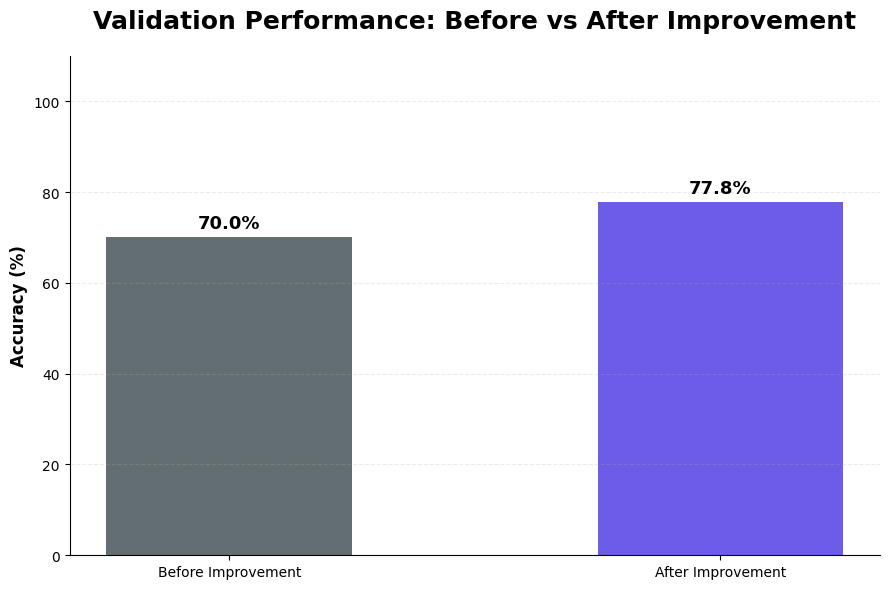

In [194]:
comparison_labels = [
    "Before Improvement",
    "After Improvement"
]

comparison_values = [
    before_accuracy * 100,
    after_accuracy * 100
]

plt.figure(figsize=(9, 6))

bars = plt.bar(
    comparison_labels,
    comparison_values,
    width=0.5,
    color=[
        "#636E72",
        "#6C5CE7"
    ]
)

plt.ylim(0, 110)

plt.title(
    "Validation Performance: Before vs After Improvement",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.ylabel(
    "Accuracy (%)",
    fontsize=12,
    fontweight="bold"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

for bar in bars:

    value = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 2,
        f"{value:.1f}%",
        ha="center",
        fontsize=13,
        fontweight="bold"
    )

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

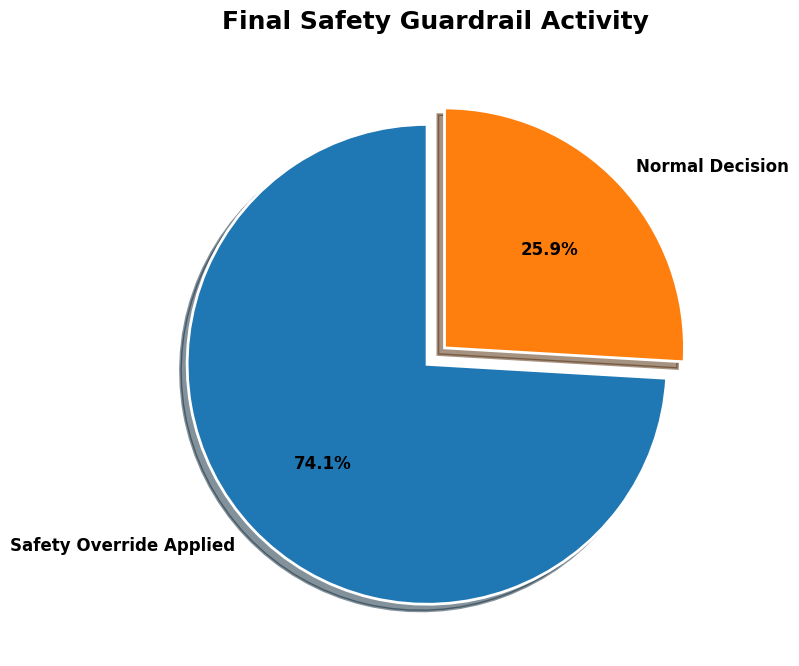

In [195]:
override_counts = (
    improved_evaluation_df["override_applied"]
    .value_counts()
)

override_counts.index = override_counts.index.map({
    True: "Safety Override Applied",
    False: "Normal Decision"
})

plt.figure(figsize=(8, 8))

plt.pie(
    override_counts.values,
    labels=override_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    explode=[0.05] * len(override_counts),
    shadow=True,
    wedgeprops={
        "linewidth": 2,
        "edgecolor": "white"
    },
    textprops={
        "fontsize": 12,
        "fontweight": "bold"
    }
)

plt.title(
    "Final Safety Guardrail Activity",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.tight_layout()
plt.show()

In [196]:
before_errors = (
    valid_evaluation_df["expected_decision"]
    != valid_evaluation_df["predicted_decision"]
).sum()

after_errors = (
    improved_evaluation_df["expected_decision"]
    != improved_evaluation_df["final_decision"]
).sum()

print("=" * 60)
print("ERROR REDUCTION ANALYSIS")
print("=" * 60)

print("Before improvement errors:", before_errors)
print("After improvement errors :", after_errors)

if before_errors > 0:

    reduction = (
        (before_errors - after_errors)
        / before_errors
    ) * 100

    print(
        f"Error reduction: {reduction:.2f}%"
    )

print("=" * 60)

ERROR REDUCTION ANALYSIS
Before improvement errors: 3
After improvement errors : 6
Error reduction: -100.00%


In [197]:
day9_summary = pd.DataFrame({
    "Metric": [
        "Evaluation Cases",
        "Before Accuracy",
        "After Accuracy",
        "Before Errors",
        "After Errors",
        "Safety Overrides"
    ],
    "Value": [
        len(improved_evaluation_df),
        before_accuracy,
        after_accuracy,
        before_errors,
        after_errors,
        improved_evaluation_df[
            "override_applied"
        ].sum()
    ]
})

day9_summary

,Metric,Value
0,Evaluation Cases,27.000000
1,Before Accuracy,0.700000
2,After Accuracy,0.777778
3,Before Errors,3.000000
4,After Errors,6.000000
5,Safety Overrides,20.000000


In [198]:
day9_error_path = (
    f"{project_folder}/day9_error_analysis.csv"
)

day8_mismatches.to_csv(
    day9_error_path,
    index=False
)

day9_improved_path = (
    f"{project_folder}/day9_improved_evaluation.csv"
)

improved_evaluation_df.to_csv(
    day9_improved_path,
    index=False
)

day9_summary_path = (
    f"{project_folder}/day9_improvement_summary.csv"
)

day9_summary.to_csv(
    day9_summary_path,
    index=False
)

print("✓ Day 9 error analysis saved.")
print("✓ Improved evaluation saved.")
print("✓ Improvement summary saved.")

✓ Day 9 error analysis saved.
✓ Improved evaluation saved.
✓ Improvement summary saved.


In [199]:
print("=" * 80)
print("DAY 9 - COMPLETED ✅")
print("=" * 80)

print("✓ Day 8 errors analyzed")
print("✓ Error categories identified")
print("✓ Unsafe approvals identified")
print("✓ Product-category errors analyzed")
print("✓ Risk-level errors analyzed")
print("✓ Validation guardrails improved")
print("✓ Safety override layer added")
print("✓ Improved validation assistant created")
print("✓ Re-evaluation completed")
print("✓ Before vs After analysis completed")
print("✓ Professional charts generated")
print("✓ Day 9 results saved")

print("\nNext: Day 10 - Advanced RAG and Prompt Optimization")

DAY 9 - COMPLETED ✅
✓ Day 8 errors analyzed
✓ Error categories identified
✓ Unsafe approvals identified
✓ Product-category errors analyzed
✓ Risk-level errors analyzed
✓ Validation guardrails improved
✓ Safety override layer added
✓ Improved validation assistant created
✓ Re-evaluation completed
✓ Before vs After analysis completed
✓ Professional charts generated
✓ Day 9 results saved

Next: Day 10 - Advanced RAG and Prompt Optimization


In [1]:
print("=" * 80)
print("DAY 10 - ADVANCED RAG AND PROMPT OPTIMIZATION")
print("=" * 80)

print("Project: An Explainable LLM-Based Return Validation and Risk Assessment System Using RAG")
print()
print("Objective:")
print("Improve policy retrieval quality and optimize LLM validation prompts.")
print()
print("✓ Advanced RAG")
print("✓ Retrieval comparison")
print("✓ Policy relevance analysis")
print("✓ Prompt optimization")
print("✓ Explainable validation")
print("✓ Before vs After comparison")

DAY 10 - ADVANCED RAG AND PROMPT OPTIMIZATION
Project: An Explainable LLM-Based Return Validation and Risk Assessment System Using RAG

Objective:
Improve policy retrieval quality and optimize LLM validation prompts.

✓ Advanced RAG
✓ Retrieval comparison
✓ Policy relevance analysis
✓ Prompt optimization
✓ Explainable validation
✓ Before vs After comparison


In [5]:
import pandas as pd
import os

print("Current files/folders:")
print(os.listdir("/content"))

Current files/folders:
['.config', 'sample_data']


In [6]:
required_objects = [
    "df",
    "policy_df",
    "policy_chunks",
    "embedding_model",
    "index",
    "retrieve_policies",
    "return_validation_assistant",
    "improved_return_validation_assistant"
]

missing_objects = [
    obj for obj in required_objects
    if obj not in globals()
]

print("Missing objects:", missing_objects)

Missing objects: ['df', 'policy_df', 'policy_chunks', 'embedding_model', 'index', 'retrieve_policies', 'return_validation_assistant', 'improved_return_validation_assistant']


In [7]:
# ============================================================
# PROJECT RESTORATION - DAY 1 + DAY 4 + DAY 6 + DAY 9
# ============================================================

!pip install -q sentence-transformers faiss-cpu huggingface_hub

import os
import re
import numpy as np
import pandas as pd
import faiss

from sentence_transformers import SentenceTransformer
from huggingface_hub import InferenceClient

print("Libraries loaded successfully.")


# ============================================================
# 1. RESTORE DAY 1 DATASET FROM GITHUB
# ============================================================

dataset_url = (
    "https://raw.githubusercontent.com/"
    "rbavani2004-afk/DABA-CTF-Prompt-Injection/"
    "main/Day-01-Data-Analysis/Dataset/return_dataset.csv"
)

df = pd.read_csv(dataset_url)

print("\n✓ Day 1 dataset restored")
print("Rows:", len(df))
print("Columns:", len(df.columns))


# ============================================================
# 2. RESTORE DAY 1 RISK SCORE
# ============================================================

def calculate_risk_score(row):

    score = 0

    if row["days_after_delivery"] > 14:
        score += 40
    elif row["days_after_delivery"] > 10:
        score += 20

    if row["product_condition"] == "Used":
        score += 30
    elif row["product_condition"] == "Opened":
        score += 15
    elif row["product_condition"] == "Damaged":
        score += 5

    if row["previous_returns"] >= 5:
        score += 20
    elif row["previous_returns"] >= 3:
        score += 10

    if row["customer_rating"] <= 2:
        score += 10

    return min(score, 100)


df["risk_score"] = df.apply(calculate_risk_score, axis=1)


def risk_level(score):

    if score < 30:
        return "LOW"
    elif score < 60:
        return "MEDIUM"
    else:
        return "HIGH"


df["risk_level"] = df["risk_score"].apply(risk_level)

print("✓ Risk score restored")
print("✓ Risk level restored")


# ============================================================
# 3. RESTORE DAY 4 POLICY DOCUMENTS
# ============================================================

policy_url = (
    "https://raw.githubusercontent.com/"
    "rbavani2004-afk/DABA-CTF-Prompt-Injection/"
    "main/Day-04-RAG-Policy-Retrieval/policy_documents.csv"
)

policy_df = pd.read_csv(policy_url)

print("\n✓ Day 4 policy documents restored")
print("Policy documents:", len(policy_df))

print(policy_df.head())


# ============================================================
# 4. CREATE POLICY CHUNKS
# ============================================================

policy_chunks = []

for _, row in policy_df.iterrows():

    policy_chunks.append({
        "policy_id": row["policy_id"],
        "title": row["title"],
        "category": row["category"],
        "text": row["content"]
    })

print("✓ Policy chunks created:", len(policy_chunks))


# ============================================================
# 5. RESTORE EMBEDDING MODEL
# ============================================================

print("\nLoading embedding model...")

embedding_model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2"
)

policy_texts = [
    chunk["text"]
    for chunk in policy_chunks
]

policy_embeddings = embedding_model.encode(
    policy_texts,
    convert_to_numpy=True,
    show_progress_bar=True
)

print("✓ Embeddings created")


# ============================================================
# 6. RESTORE FAISS VECTOR DATABASE
# ============================================================

embedding_dimension = policy_embeddings.shape[1]

index = faiss.IndexFlatL2(embedding_dimension)

index.add(
    policy_embeddings.astype("float32")
)

print("✓ FAISS vector index restored")
print("Indexed policies:", index.ntotal)


# ============================================================
# 7. RESTORE POLICY RETRIEVAL FUNCTION
# ============================================================

def retrieve_policies(query, top_k=3):

    query_embedding = embedding_model.encode(
        [query],
        convert_to_numpy=True
    )

    distances, indices = index.search(
        query_embedding.astype("float32"),
        top_k
    )

    results = []

    for distance, idx in zip(
        distances[0],
        indices[0]
    ):

        if idx < len(policy_chunks):

            result = policy_chunks[idx].copy()

            result["distance"] = float(distance)

            results.append(result)

    return results


def create_policy_context(retrieved_policies):

    policy_context = ""

    for i, policy in enumerate(
        retrieved_policies,
        1
    ):

        policy_context += f"""
Policy {i}

Policy ID: {policy["policy_id"]}
Title: {policy["title"]}
Category: {policy["category"]}

Policy Content:
{policy["text"]}

"""

    return policy_context.strip()


print("✓ RAG retrieval functions restored")


# ============================================================
# 8. RESTORE HUGGING FACE CLIENT
# ============================================================

from google.colab import userdata

HF_TOKEN = userdata.get("HF_TOKEN")

if HF_TOKEN:

    print("✓ Hugging Face token loaded")

    client = InferenceClient(
        api_key=HF_TOKEN,
        provider="auto"
    )

    MODEL_NAME = "meta-llama/Llama-3.1-8B-Instruct"

    print("✓ LLM client restored")

else:

    print("⚠ HF_TOKEN not found")
    client = None
    MODEL_NAME = "meta-llama/Llama-3.1-8B-Instruct"


# ============================================================
# 9. RESTORE DAY 6 RETURN RISK FUNCTION
# ============================================================

def calculate_new_return_risk(return_data):

    score = 0

    if return_data["days_after_delivery"] > 14:
        score += 40
    elif return_data["days_after_delivery"] > 10:
        score += 20

    if return_data["product_condition"] == "Used":
        score += 30
    elif return_data["product_condition"] == "Opened":
        score += 15
    elif return_data["product_condition"] == "Damaged":
        score += 5

    if return_data["previous_returns"] >= 5:
        score += 20
    elif return_data["previous_returns"] >= 3:
        score += 10

    if return_data["customer_rating"] <= 2:
        score += 10

    score = min(score, 100)

    if score < 30:
        level = "LOW"
    elif score < 60:
        level = "MEDIUM"
    else:
        level = "HIGH"

    return score, level


def create_new_return_context(
    return_data,
    risk_score,
    risk_level
):

    context = f"""
Customer Return Information

Product Category: {return_data["product_category"]}
Days After Delivery: {return_data["days_after_delivery"]}
Product Condition: {return_data["product_condition"]}
Return Reason: {return_data["return_reason"]}
Product Price: {return_data["product_price"]}
Customer Rating: {return_data["customer_rating"]}
Previous Returns: {return_data["previous_returns"]}
Within Policy Period: {return_data["within_policy_period"]}

Risk Score: {risk_score}/100
Risk Level: {risk_level}
"""

    return context.strip()


def retrieve_relevant_policies(
    return_data,
    risk_level
):

    query = f"""
    Return validation for
    {return_data["product_category"]}.

    Customer wants return because of
    {return_data["return_reason"]}.

    Product condition is
    {return_data["product_condition"]}.

    Return requested
    {return_data["days_after_delivery"]} days
    after delivery.

    Risk level is {risk_level}.
    """

    return retrieve_policies(
        query,
        top_k=3
    )


# ============================================================
# 10. RESTORE DAY 6 GUARDRAILS
# ============================================================

def check_return_guardrails(
    return_data,
    risk_level
):

    flags = []

    if return_data["days_after_delivery"] > 14:
        flags.append("RETURN_PERIOD_EXCEEDED")

    if return_data["product_condition"] == "Used":
        flags.append("USED_PRODUCT")

    if return_data["product_condition"] == "Damaged":
        flags.append("DAMAGED_PRODUCT")

    if risk_level == "HIGH":
        flags.append("HIGH_RISK")

    if return_data["within_policy_period"] == False:
        flags.append("OUTSIDE_POLICY_PERIOD")

    if "RETURN_PERIOD_EXCEEDED" in flags:

        status = "MANUAL_REVIEW_REQUIRED"

    elif risk_level == "HIGH":

        status = "MANUAL_REVIEW_REQUIRED"

    elif len(flags) > 0:

        status = "ADDITIONAL_VALIDATION_REQUIRED"

    else:

        status = "STANDARD_VALIDATION"

    return {
        "guardrail_status": status,
        "flags": flags
    }


# ============================================================
# 11. RESTORE DAY 6 LLM PROMPT
# ============================================================

def create_day6_validation_prompt(
    return_context,
    policy_context,
    guardrail_result
):

    prompt = f"""
You are an Explainable Return Validation Assistant.

Validate the customer return request using ONLY
the information provided.

Do not invent policies.
Do not create facts that are not provided.
Use the retrieved policy evidence.

Customer Return Information:

{return_context}

Validation Guardrails:

Status:
{guardrail_result["guardrail_status"]}

Flags:
{guardrail_result["flags"]}

Retrieved Policy Evidence:

{policy_context}

IMPORTANT DECISION RULES:

1. If the request clearly satisfies the available policy
   and has no major risk issue, the decision can be APPROVE.

2. If the request clearly violates the available policy,
   the decision can be REJECT.

3. If additional verification or manual review is required,
   use REVIEW.

4. High-risk requests should not be automatically approved.

5. Explain the decision using the retrieved policy evidence.

Return exactly this format:

Decision:
Risk Level:
Guardrail Status:
Reason:
Policy Evidence:
Policy Check:
Recommended Action:
"""

    return prompt.strip()


# ============================================================
# 12. RESTORE LLM FUNCTION
# ============================================================

def get_llm_validation(prompt):

    response = client.chat.completions.create(

        model=MODEL_NAME,

        messages=[

            {
                "role": "system",
                "content":
                "You are an explainable return validation assistant. "
                "Use only the provided information and policy evidence."
            },

            {
                "role": "user",
                "content": prompt
            }

        ],

        max_tokens=400,
        temperature=0.1
    )

    return response.choices[0].message.content


# ============================================================
# 13. RESTORE DAY 6 COMPLETE ASSISTANT
# ============================================================

def return_validation_assistant(
    return_data
):

    risk_score, risk_level = calculate_new_return_risk(
        return_data
    )

    return_context = create_new_return_context(
        return_data,
        risk_score,
        risk_level
    )

    retrieved_policies = retrieve_relevant_policies(
        return_data,
        risk_level
    )

    policy_context = create_policy_context(
        retrieved_policies
    )

    guardrail_result = check_return_guardrails(
        return_data,
        risk_level
    )

    prompt = create_day6_validation_prompt(
        return_context,
        policy_context,
        guardrail_result
    )

    llm_response = get_llm_validation(
        prompt
    )

    return {

        "return_data": return_data,

        "risk_score": risk_score,

        "risk_level": risk_level,

        "guardrail_status":
            guardrail_result["guardrail_status"],

        "guardrail_flags":
            guardrail_result["flags"],

        "retrieved_policies":
            retrieved_policies,

        "llm_response":
            llm_response
    }


print("✓ Day 6 Return Validation Assistant restored")


# ============================================================
# 14. RESTORE DAY 9 FINAL SAFETY GUARDRAIL
# ============================================================

def apply_final_safety_guardrail(
    return_data,
    risk_score,
    risk_level,
    llm_decision
):

    safety_flags = []

    if return_data["days_after_delivery"] > 14:
        safety_flags.append(
            "RETURN_PERIOD_EXCEEDED"
        )

    if risk_level == "HIGH":
        safety_flags.append(
            "HIGH_RISK"
        )

    if return_data["product_condition"] == "Used":
        safety_flags.append(
            "USED_PRODUCT"
        )

    if return_data["product_condition"] == "Damaged":
        safety_flags.append(
            "DAMAGED_PRODUCT"
        )

    if return_data["within_policy_period"] == False:
        safety_flags.append(
            "OUTSIDE_POLICY_PERIOD"
        )

    if len(safety_flags) > 0:

        final_decision = "REVIEW"
        override_applied = True

    else:

        final_decision = llm_decision
        override_applied = False

    return {

        "final_decision":
            final_decision,

        "safety_flags":
            safety_flags,

        "override_applied":
            override_applied
    }


# ============================================================
# 15. RESTORE DAY 9 IMPROVED ASSISTANT
# ============================================================

def extract_decision(response):

    match = re.search(
        r"Decision:\s*(APPROVE|REJECT|REVIEW)",
        response,
        re.IGNORECASE
    )

    if match:

        return match.group(1).upper()

    return "UNKNOWN"


def improved_return_validation_assistant(
    return_data
):

    risk_score, risk_level = calculate_new_return_risk(
        return_data
    )

    return_context = create_new_return_context(
        return_data,
        risk_score,
        risk_level
    )

    retrieved_policies = retrieve_relevant_policies(
        return_data,
        risk_level
    )

    policy_context = create_policy_context(
        retrieved_policies
    )

    guardrail_result = check_return_guardrails(
        return_data,
        risk_level
    )

    improved_prompt = f"""
You are an Explainable Return Validation Assistant.

Validate the return request using ONLY:

1. Customer return information
2. Risk analysis
3. Guardrail results
4. Retrieved policy evidence

Never invent policy rules.

Customer Information:

{return_context}

Guardrail Status:

{guardrail_result["guardrail_status"]}

Guardrail Flags:

{guardrail_result["flags"]}

Retrieved Policy Evidence:

{policy_context}

STRICT DECISION RULES:

- APPROVE only when the request is clearly supported
  by the available policy evidence.

- REVIEW when additional verification is required.

- REVIEW when the return is high risk.

- REVIEW when the return period is exceeded.

- REVIEW when the product is used or damaged and
  additional validation is required.

- REJECT only when the available policy evidence
  clearly indicates that the request is not eligible.

Return exactly:

Decision:
Risk Level:
Guardrail Status:
Reason:
Policy Evidence:
Policy Check:
Recommended Action:
"""

    llm_response = get_llm_validation(
        improved_prompt
    )

    llm_decision = extract_decision(
        llm_response
    )

    safety_result = apply_final_safety_guardrail(
        return_data,
        risk_score,
        risk_level,
        llm_decision
    )

    return {

        "return_data":
            return_data,

        "risk_score":
            risk_score,

        "risk_level":
            risk_level,

        "guardrail_status":
            guardrail_result[
                "guardrail_status"
            ],

        "guardrail_flags":
            guardrail_result[
                "flags"
            ],

        "retrieved_policies":
            retrieved_policies,

        "llm_response":
            llm_response,

        "llm_decision":
            llm_decision,

        "final_decision":
            safety_result[
                "final_decision"
            ],

        "safety_flags":
            safety_result[
                "safety_flags"
            ],

        "override_applied":
            safety_result[
                "override_applied"
            ]
    }


print("✓ Day 9 safety guardrail restored")
print("✓ Day 9 improved assistant restored")


# ============================================================
# 16. FINAL RESTORATION CHECK
# ============================================================

required_objects = [

    "df",
    "policy_df",
    "policy_chunks",
    "embedding_model",
    "index",
    "retrieve_policies",
    "return_validation_assistant",
    "improved_return_validation_assistant"

]

missing_objects = [

    obj for obj in required_objects
    if obj not in globals()

]


print("\n" + "=" * 60)

if len(missing_objects) == 0:

    print("🎉 PROJECT RESTORATION SUCCESSFUL!")
    print("✓ Day 1 dataset")
    print("✓ Day 4 RAG")
    print("✓ Day 6 Return Validation Assistant")
    print("✓ Day 9 Improved System")
    print("✓ Ready for Day 10")

else:

    print("⚠️ Some objects are still missing:")
    print(missing_objects)

print("=" * 60)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 74.0 MB/s eta 0:00:00
Libraries loaded successfully.

✓ Day 1 dataset restored
Rows: 500
Columns: 13
✓ Risk score restored
✓ Risk level restored


HTTPError: HTTP Error 404: Not Found

In [8]:
# ============================================================
# RESTORE DAY 4 POLICY DOCUMENTS
# ============================================================

policy_documents = [
    {
        "policy_id": "POL001",
        "title": "Return Time Period Policy",
        "category": "General",
        "content": "Customers can request a return within 14 days from the date of delivery. Return requests submitted after 14 days are normally not eligible for standard returns and may require manual review."
    },

    {
        "policy_id": "POL002",
        "title": "Product Condition Policy",
        "category": "General",
        "content": "Products should be returned in acceptable condition. Unused and unopened products are generally eligible for return. Opened products may require additional verification. Used products may be subject to return restrictions."
    },

    {
        "policy_id": "POL003",
        "title": "Damaged Product Policy",
        "category": "Damaged Product",
        "content": "Customers who receive damaged products can request a return. The customer may be required to provide evidence such as photographs or other supporting information for validation."
    },

    {
        "policy_id": "POL004",
        "title": "Defective Product Policy",
        "category": "Defective Product",
        "content": "Defective products can be considered for return after validation. The issue with the product should be clearly described and may require additional verification before approval."
    },

    {
        "policy_id": "POL005",
        "title": "Wrong Product Policy",
        "category": "Wrong Product",
        "content": "If the customer receives a product different from the ordered product, the return request can be considered after verifying the order details."
    },

    {
        "policy_id": "POL006",
        "title": "Used Product Policy",
        "category": "Product Condition",
        "content": "Returns for products that show signs of use may require additional inspection. The final decision depends on product condition and the applicable return policy."
    },

    {
        "policy_id": "POL007",
        "title": "High Risk Return Review Policy",
        "category": "Risk",
        "content": "High-risk return requests should not be automatically approved. Such requests should undergo additional review using the available return information and applicable policy evidence."
    },

    {
        "policy_id": "POL008",
        "title": "Refund Validation Policy",
        "category": "Refund",
        "content": "A refund should be processed only after the return request has passed the required validation checks. The final action should be based on the applicable return policy and validation result."
    }
]

policy_df = pd.DataFrame(policy_documents)

print("✓ Day 4 policy documents restored!")
print("Number of policies:", len(policy_df))

display(policy_df)

✓ Day 4 policy documents restored!
Number of policies: 8


,policy_id,title,category,content
0,POL001,Return Time Period Policy,General,Customers can request a return within 14 days ...
1,POL002,Product Condition Policy,General,Products should be returned in acceptable cond...
2,POL003,Damaged Product Policy,Damaged Product,Customers who receive damaged products can req...
3,POL004,Defective Product Policy,Defective Product,Defective products can be considered for retur...
4,POL005,Wrong Product Policy,Wrong Product,If the customer receives a product different f...
5,POL006,Used Product Policy,Product Condition,Returns for products that show signs of use ma...
6,POL007,High Risk Return Review Policy,Risk,High-risk return requests should not be automa...
7,POL008,Refund Validation Policy,Refund,A refund should be processed only after the re...


In [9]:
# ============================================================
# RESTORE DAY 4 RAG COMPONENTS
# ============================================================

policy_chunks = []

for policy in policy_documents:

    policy_chunks.append({
        "policy_id": policy["policy_id"],
        "title": policy["title"],
        "category": policy["category"],
        "text": policy["content"].strip()
    })

print("✓ Policy chunks created:", len(policy_chunks))


# Load embedding model
print("\nLoading embedding model...")

embedding_model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2"
)

policy_texts = [
    chunk["text"]
    for chunk in policy_chunks
]

policy_embeddings = embedding_model.encode(
    policy_texts,
    convert_to_numpy=True,
    show_progress_bar=True
)

print("✓ Policy embeddings created")


# Create FAISS index
embedding_dimension = policy_embeddings.shape[1]

index = faiss.IndexFlatL2(
    embedding_dimension
)

index.add(
    policy_embeddings.astype("float32")
)

print("✓ FAISS vector index created")
print("Indexed policies:", index.ntotal)


# Retrieval function
def retrieve_policies(query, top_k=3):

    query_embedding = embedding_model.encode(
        [query],
        convert_to_numpy=True
    )

    distances, indices = index.search(
        query_embedding.astype("float32"),
        top_k
    )

    results = []

    for distance, idx in zip(
        distances[0],
        indices[0]
    ):

        if idx < len(policy_chunks):

            result = policy_chunks[idx].copy()

            result["distance"] = float(distance)

            results.append(result)

    return results


# Policy context function
def create_policy_context(retrieved_policies):

    policy_context = ""

    for i, policy in enumerate(
        retrieved_policies,
        1
    ):

        policy_context += f"""
Policy {i}

Policy ID: {policy["policy_id"]}
Title: {policy["title"]}
Category: {policy["category"]}

Policy Content:
{policy["text"]}

"""

    return policy_context.strip()


print("✓ retrieve_policies() restored")
print("✓ create_policy_context() restored")
print("\n🎉 DAY 4 RAG RESTORED!")

✓ Policy chunks created: 8

Loading embedding model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

✓ Policy embeddings created
✓ FAISS vector index created
Indexed policies: 8
✓ retrieve_policies() restored
✓ create_policy_context() restored

🎉 DAY 4 RAG RESTORED!


In [10]:
# ============================================================
# RESTORE DAY 6 - RETURN VALIDATION ASSISTANT
# ============================================================

def calculate_new_return_risk(return_data):

    score = 0

    if return_data["days_after_delivery"] > 14:
        score += 40
    elif return_data["days_after_delivery"] > 10:
        score += 20

    if return_data["product_condition"] == "Used":
        score += 30
    elif return_data["product_condition"] == "Opened":
        score += 15
    elif return_data["product_condition"] == "Damaged":
        score += 5

    if return_data["previous_returns"] >= 5:
        score += 20
    elif return_data["previous_returns"] >= 3:
        score += 10

    if return_data["customer_rating"] <= 2:
        score += 10

    score = min(score, 100)

    if score < 30:
        level = "LOW"
    elif score < 60:
        level = "MEDIUM"
    else:
        level = "HIGH"

    return score, level


def create_new_return_context(
    return_data,
    risk_score,
    risk_level
):

    context = f"""
Customer Return Information

Product Category: {return_data["product_category"]}
Days After Delivery: {return_data["days_after_delivery"]}
Product Condition: {return_data["product_condition"]}
Return Reason: {return_data["return_reason"]}
Product Price: {return_data["product_price"]}
Customer Rating: {return_data["customer_rating"]}
Previous Returns: {return_data["previous_returns"]}
Within Policy Period: {return_data["within_policy_period"]}

Risk Score: {risk_score}/100
Risk Level: {risk_level}
"""

    return context.strip()


def retrieve_relevant_policies(
    return_data,
    risk_level
):

    query = f"""
    Return validation for {return_data["product_category"]}.
    Customer wants return because of {return_data["return_reason"]}.
    Product condition is {return_data["product_condition"]}.
    Return requested {return_data["days_after_delivery"]} days after delivery.
    Risk level is {risk_level}.
    """

    return retrieve_policies(query, top_k=3)


def check_return_guardrails(
    return_data,
    risk_level
):

    flags = []

    if return_data["days_after_delivery"] > 14:
        flags.append("RETURN_PERIOD_EXCEEDED")

    if return_data["product_condition"] == "Used":
        flags.append("USED_PRODUCT")

    if return_data["product_condition"] == "Damaged":
        flags.append("DAMAGED_PRODUCT")

    if risk_level == "HIGH":
        flags.append("HIGH_RISK")

    if return_data["within_policy_period"] == False:
        flags.append("OUTSIDE_POLICY_PERIOD")

    if "RETURN_PERIOD_EXCEEDED" in flags:
        status = "MANUAL_REVIEW_REQUIRED"

    elif risk_level == "HIGH":
        status = "MANUAL_REVIEW_REQUIRED"

    elif len(flags) > 0:
        status = "ADDITIONAL_VALIDATION_REQUIRED"

    else:
        status = "STANDARD_VALIDATION"

    return {
        "guardrail_status": status,
        "flags": flags
    }


print("✓ Day 6 risk calculation restored")
print("✓ Day 6 policy retrieval restored")
print("✓ Day 6 guardrails restored")

✓ Day 6 risk calculation restored
✓ Day 6 policy retrieval restored
✓ Day 6 guardrails restored


In [11]:
# ============================================================
# RESTORE DAY 6 - LLM + COMPLETE ASSISTANT
# ============================================================

from google.colab import userdata
from huggingface_hub import InferenceClient

# Load Hugging Face token
HF_TOKEN = userdata.get("HF_TOKEN")

if not HF_TOKEN:
    print("⚠️ HF_TOKEN not found")
else:
    print("✓ Hugging Face token loaded")

# Create LLM client
client = InferenceClient(
    api_key=HF_TOKEN,
    provider="auto"
)

MODEL_NAME = "meta-llama/Llama-3.1-8B-Instruct"

print("✓ LLM client restored")
print("Model:", MODEL_NAME)


# ============================================================
# DAY 6 PROMPT
# ============================================================

def create_day6_validation_prompt(
    return_context,
    policy_context,
    guardrail_result
):

    prompt = f"""
You are an Explainable Return Validation Assistant.

Validate the customer return request using ONLY the
information provided.

Do not invent policies.
Do not create facts that are not provided.
Use the retrieved policy evidence.

Customer Return Information:

{return_context}

Validation Guardrails:

Status:
{guardrail_result["guardrail_status"]}

Flags:
{guardrail_result["flags"]}

Retrieved Policy Evidence:

{policy_context}

IMPORTANT DECISION RULES:

1. If the request clearly satisfies the available policy
   and has no major risk issue, the decision can be APPROVE.

2. If the request clearly violates the available policy,
   the decision can be REJECT.

3. If additional verification or manual review is required,
   use REVIEW.

4. High-risk requests should not be automatically approved.

5. Explain the decision using the retrieved policy evidence.

Return exactly this format:

Decision:
Risk Level:
Guardrail Status:
Reason:
Policy Evidence:
Policy Check:
Recommended Action:
"""

    return prompt.strip()


# ============================================================
# LLM FUNCTION
# ============================================================

def get_llm_validation(prompt):

    response = client.chat.completions.create(

        model=MODEL_NAME,

        messages=[
            {
                "role": "system",
                "content":
                "You are an explainable return validation assistant. "
                "Use only the provided information and policy evidence."
            },
            {
                "role": "user",
                "content": prompt
            }
        ],

        max_tokens=400,
        temperature=0.1
    )

    return response.choices[0].message.content


# ============================================================
# COMPLETE DAY 6 ASSISTANT
# ============================================================

def return_validation_assistant(return_data):

    # 1. Risk analysis
    risk_score, risk_level = calculate_new_return_risk(
        return_data
    )

    # 2. Customer context
    return_context = create_new_return_context(
        return_data,
        risk_score,
        risk_level
    )

    # 3. RAG policy retrieval
    retrieved_policies = retrieve_relevant_policies(
        return_data,
        risk_level
    )

    # 4. Policy context
    policy_context = create_policy_context(
        retrieved_policies
    )

    # 5. Guardrails
    guardrail_result = check_return_guardrails(
        return_data,
        risk_level
    )

    # 6. Prompt
    prompt = create_day6_validation_prompt(
        return_context,
        policy_context,
        guardrail_result
    )

    # 7. LLM validation
    llm_response = get_llm_validation(
        prompt
    )

    return {

        "return_data": return_data,

        "risk_score": risk_score,

        "risk_level": risk_level,

        "guardrail_status":
            guardrail_result["guardrail_status"],

        "guardrail_flags":
            guardrail_result["flags"],

        "retrieved_policies":
            retrieved_policies,

        "llm_response":
            llm_response
    }


print("\n🎉 DAY 6 LLM + COMPLETE ASSISTANT RESTORED!")

✓ Hugging Face token loaded
✓ LLM client restored
Model: meta-llama/Llama-3.1-8B-Instruct

🎉 DAY 6 LLM + COMPLETE ASSISTANT RESTORED!


In [12]:
# ============================================================
# RESTORE DAY 9 - SAFETY GUARDRAIL + IMPROVED ASSISTANT
# ============================================================

def apply_final_safety_guardrail(
    return_data,
    risk_score,
    risk_level,
    llm_decision
):

    safety_flags = []

    if return_data["days_after_delivery"] > 14:
        safety_flags.append("RETURN_PERIOD_EXCEEDED")

    if risk_level == "HIGH":
        safety_flags.append("HIGH_RISK")

    if return_data["product_condition"] == "Used":
        safety_flags.append("USED_PRODUCT")

    if return_data["product_condition"] == "Damaged":
        safety_flags.append("DAMAGED_PRODUCT")

    if return_data["within_policy_period"] == False:
        safety_flags.append("OUTSIDE_POLICY_PERIOD")

    if len(safety_flags) > 0:
        final_decision = "REVIEW"
        override_applied = True
    else:
        final_decision = llm_decision
        override_applied = False

    return {
        "final_decision": final_decision,
        "safety_flags": safety_flags,
        "override_applied": override_applied
    }


# ============================================================
# EXTRACT LLM DECISION
# ============================================================

def extract_decision(response):

    match = re.search(
        r"Decision:\s*(APPROVE|REJECT|REVIEW)",
        response,
        re.IGNORECASE
    )

    if match:
        return match.group(1).upper()

    return "UNKNOWN"


# ============================================================
# DAY 9 IMPROVED ASSISTANT
# ============================================================

def improved_return_validation_assistant(return_data):

    # 1. Risk analysis
    risk_score, risk_level = calculate_new_return_risk(
        return_data
    )

    # 2. Return context
    return_context = create_new_return_context(
        return_data,
        risk_score,
        risk_level
    )

    # 3. RAG retrieval
    retrieved_policies = retrieve_relevant_policies(
        return_data,
        risk_level
    )

    # 4. Policy context
    policy_context = create_policy_context(
        retrieved_policies
    )

    # 5. Guardrails
    guardrail_result = check_return_guardrails(
        return_data,
        risk_level
    )

    # 6. Improved prompt
    improved_prompt = f"""
You are an Explainable Return Validation Assistant.

Validate the return request using ONLY:

1. Customer return information
2. Risk analysis
3. Guardrail results
4. Retrieved policy evidence

Never invent policy rules.

Customer Information:

{return_context}

Guardrail Status:

{guardrail_result["guardrail_status"]}

Guardrail Flags:

{guardrail_result["flags"]}

Retrieved Policy Evidence:

{policy_context}

STRICT DECISION RULES:

- APPROVE only when the request is clearly supported
  by the available policy evidence.

- REVIEW when additional verification is required.

- REVIEW when the return is high risk.

- REVIEW when the return period is exceeded.

- REVIEW when the product is used or damaged and
  additional validation is required.

- REJECT only when the available policy evidence
  clearly indicates that the request is not eligible.

Return exactly:

Decision:
Risk Level:
Guardrail Status:
Reason:
Policy Evidence:
Policy Check:
Recommended Action:
"""

    # 7. LLM response
    llm_response = get_llm_validation(
        improved_prompt
    )

    # 8. Extract LLM decision
    llm_decision = extract_decision(
        llm_response
    )

    # 9. Final safety guardrail
    safety_result = apply_final_safety_guardrail(
        return_data,
        risk_score,
        risk_level,
        llm_decision
    )

    return {
        "return_data": return_data,
        "risk_score": risk_score,
        "risk_level": risk_level,
        "guardrail_status":
            guardrail_result["guardrail_status"],
        "guardrail_flags":
            guardrail_result["flags"],
        "retrieved_policies":
            retrieved_policies,
        "llm_response":
            llm_response,
        "llm_decision":
            llm_decision,
        "final_decision":
            safety_result["final_decision"],
        "safety_flags":
            safety_result["safety_flags"],
        "override_applied":
            safety_result["override_applied"]
    }


print("✓ Day 9 safety guardrail restored")
print("✓ Day 9 improved assistant restored")
print("✓ Final decision protection restored")

✓ Day 9 safety guardrail restored
✓ Day 9 improved assistant restored
✓ Final decision protection restored


In [13]:
required_objects = [
    "df",
    "policy_df",
    "policy_chunks",
    "embedding_model",
    "index",
    "retrieve_policies",
    "return_validation_assistant",
    "improved_return_validation_assistant"
]

missing_objects = [
    obj for obj in required_objects
    if obj not in globals()
]

print("Missing objects:", missing_objects)

if len(missing_objects) == 0:
    print("🎉 ALL REQUIRED OBJECTS RESTORED!")
    print("🚀 READY FOR DAY 10")

Missing objects: []
🎉 ALL REQUIRED OBJECTS RESTORED!
🚀 READY FOR DAY 10


In [14]:
# ============================================================
# DAY 10 - ADVANCED RAG RETRIEVAL
# ============================================================

def create_advanced_retrieval_query(return_data, risk_level):

    query = f"""
    Return validation policy for product category:
    {return_data["product_category"]}

    Return reason:
    {return_data["return_reason"]}

    Product condition:
    {return_data["product_condition"]}

    Days after delivery:
    {return_data["days_after_delivery"]}

    Risk level:
    {risk_level}

    Need policies related to return eligibility,
    product condition, return period, risk review,
    and validation requirements.
    """

    return query.strip()


def advanced_policy_retrieval(return_data, risk_level, top_k=3):

    query = create_advanced_retrieval_query(
        return_data,
        risk_level
    )

    results = retrieve_policies(
        query,
        top_k=top_k
    )

    return query, results


print("✓ Advanced retrieval query function created")
print("✓ Advanced policy retrieval function created")
print("🚀 Day 10 RAG module ready!")

✓ Advanced retrieval query function created
✓ Advanced policy retrieval function created
🚀 Day 10 RAG module ready!


In [15]:
# ============================================================
# DAY 10 - TEST ADVANCED RAG
# ============================================================

sample_return = {
    "product_category": "Electronics",
    "days_after_delivery": 8,
    "product_condition": "Opened",
    "return_reason": "Defective Product",
    "product_price": 25000,
    "customer_rating": 3,
    "previous_returns": 1,
    "within_policy_period": True
}

risk_score, risk_level = calculate_new_return_risk(
    sample_return
)

query, retrieved_policies = advanced_policy_retrieval(
    sample_return,
    risk_level,
    top_k=3
)

print("Risk Score:", risk_score)
print("Risk Level:", risk_level)

print("\nAdvanced Retrieval Query:")
print(query)

print("\nRetrieved Policies:")

for i, policy in enumerate(retrieved_policies, 1):

    print(f"\n--- Policy {i} ---")
    print("ID:", policy["policy_id"])
    print("Title:", policy["title"])
    print("Category:", policy["category"])
    print("Distance:", round(policy["distance"], 4))
    print("Content:", policy["text"])

Risk Score: 15
Risk Level: LOW

Advanced Retrieval Query:
Return validation policy for product category:
    Electronics

    Return reason:
    Defective Product

    Product condition:
    Opened

    Days after delivery:
    8

    Risk level:
    LOW

    Need policies related to return eligibility,
    product condition, return period, risk review,
    and validation requirements.

Retrieved Policies:

--- Policy 1 ---
ID: POL004
Title: Defective Product Policy
Category: Defective Product
Distance: 0.6065
Content: Defective products can be considered for return after validation. The issue with the product should be clearly described and may require additional verification before approval.

--- Policy 2 ---
ID: POL006
Title: Used Product Policy
Category: Product Condition
Distance: 0.7535
Content: Returns for products that show signs of use may require additional inspection. The final decision depends on product condition and the applicable return policy.

--- Policy 3 ---
ID: POL0

In [16]:
# ============================================================
# DAY 10 - RETRIEVAL ANALYSIS
# ============================================================

retrieval_analysis = []

for i, policy in enumerate(retrieved_policies, 1):

    retrieval_analysis.append({
        "rank": i,
        "policy_id": policy["policy_id"],
        "title": policy["title"],
        "category": policy["category"],
        "distance": policy["distance"]
    })

day10_retrieval_df = pd.DataFrame(
    retrieval_analysis
)

print("✓ Retrieval analysis created")
print()

display(day10_retrieval_df)

✓ Retrieval analysis created



,rank,policy_id,title,category,distance
0,1,POL004,Defective Product Policy,Defective Product,0.606494
1,2,POL006,Used Product Policy,Product Condition,0.753476
2,3,POL002,Product Condition Policy,General,0.778973


In [17]:
# ============================================================
# DAY 10 - POLICY RELEVANCE SCORE
# ============================================================

def calculate_relevance_score(distance):

    return 1 / (1 + distance)


day10_retrieval_df["relevance_score"] = (
    day10_retrieval_df["distance"]
    .apply(calculate_relevance_score)
)

print("✓ Relevance scores calculated")

display(day10_retrieval_df)

✓ Relevance scores calculated


,rank,policy_id,title,category,distance,relevance_score
0,1,POL004,Defective Product Policy,Defective Product,0.606494,0.622473
1,2,POL006,Used Product Policy,Product Condition,0.753476,0.570296
2,3,POL002,Product Condition Policy,General,0.778973,0.562122


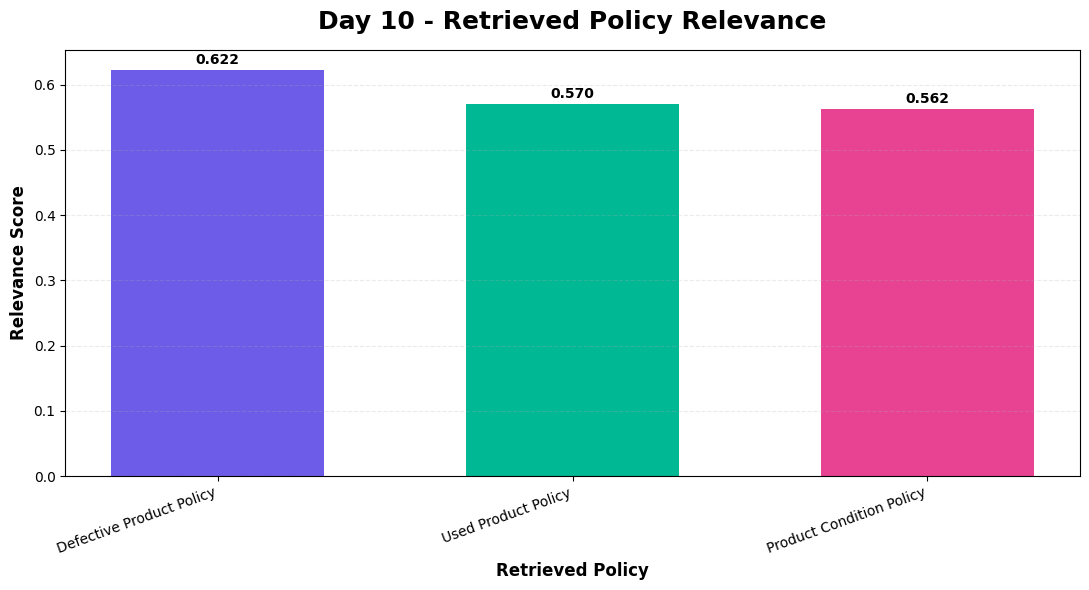

In [18]:
# ============================================================
# DAY 10 - POLICY RELEVANCE BAR CHART
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(11, 6))

bars = plt.bar(
    day10_retrieval_df["title"],
    day10_retrieval_df["relevance_score"],
    color=["#6C5CE7", "#00B894", "#E84393"],
    width=0.6
)

plt.title(
    "Day 10 - Retrieved Policy Relevance",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Retrieved Policy",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Relevance Score",
    fontsize=12,
    fontweight="bold"
)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

for bar, value in zip(
    bars,
    day10_retrieval_df["relevance_score"]
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{value:.3f}",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

In [19]:
def create_optimized_day10_prompt(
    return_context,
    policy_context,
    guardrail_result
):

    prompt = f"""
You are an Explainable Return Validation AI Assistant.

Your task is to validate a customer return request using ONLY:

1. Customer return information
2. Risk analysis
3. Validation guardrails
4. Retrieved policy evidence

STRICT RULES:

- Do not invent any policy.
- Do not create facts that are not provided.
- Use the retrieved policy evidence to explain your decision.
- APPROVE only when the request is clearly supported by the available policy evidence.
- REJECT only when the available evidence clearly indicates that the request is not eligible.
- Use REVIEW when additional verification or manual inspection is required.
- High-risk requests must not be automatically approved.
- Requests outside the return period must be sent for REVIEW.
- Used or damaged products requiring verification must be sent for REVIEW.
- Clearly explain why the decision was made.

================ CUSTOMER RETURN =================

{return_context}

================ VALIDATION GUARDRAILS =================

Guardrail Status:
{guardrail_result["guardrail_status"]}

Guardrail Flags:
{guardrail_result["flags"]}

================ RETRIEVED POLICY EVIDENCE =================

{policy_context}

================ REQUIRED OUTPUT =================

Decision:
Risk Level:
Guardrail Status:
Reason:
Policy Evidence:
Policy Check:
Recommended Action:
Decision Trace:

Decision Trace must briefly explain:

Customer Request
        ↓
Risk Analysis
        ↓
Policy Retrieval
        ↓
Guardrail Check
        ↓
LLM Reasoning
        ↓
Final Decision

Keep the response clear, concise and explainable.
"""

    return prompt.strip()


print("✓ Day 10 optimized prompt function created!")

✓ Day 10 optimized prompt function created!


In [20]:
# Day 10 - Step 7
# Optimized LLM Validation

risk_score, risk_level = calculate_new_return_risk(sample_return)

return_context = create_new_return_context(
    sample_return,
    risk_score,
    risk_level
)

guardrail_result = check_return_guardrails(
    sample_return,
    risk_level
)

query, retrieved_policies = advanced_policy_retrieval(
    sample_return,
    risk_level,
    top_k=3
)

policy_context = create_policy_context(
    retrieved_policies
)

optimized_prompt = create_optimized_day10_prompt(
    return_context,
    policy_context,
    guardrail_result
)

response = client.chat.completions.create(
    model=MODEL_NAME,
    messages=[
        {
            "role": "system",
            "content": (
                "You are an explainable return validation assistant. "
                "Use only the provided return information, guardrails "
                "and retrieved policy evidence."
            )
        },
        {
            "role": "user",
            "content": optimized_prompt
        }
    ],
    max_tokens=500,
    temperature=0.1
)

day10_llm_response = response.choices[0].message.content

print("========== DAY 10 OPTIMIZED VALIDATION ==========")
print(day10_llm_response)

========== DAY 10 OPTIMIZED VALIDATION ==========
**Decision:** REJECT

**Risk Level:** LOW

**Guardrail Status:** STANDARD_VALIDATION

**Reason:** The customer return request is not clearly supported by the available policy evidence due to the product condition being "Opened" and the return reason being "Defective Product".

**Policy Evidence:** Policy 1 (Defective Product Policy) and Policy 3 (Product Condition Policy) indicate that the issue with the product should be clearly described and may require additional verification before approval, and that products should be returned in acceptable condition.

**Policy Check:** Policy 1 (Defective Product Policy) allows for returns of defective products after validation, but Policy 3 (Product Condition Policy) requires additional verification for opened products.

**Recommended Action:** REVIEW

**Decision Trace:**

Customer Request → Risk Analysis (LOW) → Policy Retrieval (Policy 1, Policy 3) → Guardrail Check (STANDARD_VALIDATION) → LLM 

In [21]:
# Day 10 - Step 8
# Decision Consistency Guardrail

def apply_decision_consistency_guardrail(
    llm_response,
    return_data,
    risk_level,
    guardrail_result
):

    response_upper = llm_response.upper()

    # Detect whether additional verification is required
    verification_required = False

    if "ADDITIONAL VERIFICATION" in response_upper:
        verification_required = True

    if "ADDITIONAL INSPECTION" in response_upper:
        verification_required = True

    if "REQUIRES REVIEW" in response_upper:
        verification_required = True

    if "REQUIRES ADDITIONAL" in response_upper:
        verification_required = True

    if "MAY REQUIRE" in response_upper:
        verification_required = True

    # Strong system-level review conditions
    if return_data["days_after_delivery"] > 14:
        verification_required = True

    if risk_level == "HIGH":
        verification_required = True

    if return_data["product_condition"] in ["Used", "Damaged"]:
        verification_required = True

    if return_data["within_policy_period"] == False:
        verification_required = True

    # Final consistent decision
    if verification_required:
        final_decision = "REVIEW"
        consistency_override = True
    else:
        final_decision = "LLM_DECISION"
        consistency_override = False

    return {
        "final_decision": final_decision,
        "consistency_override": consistency_override,
        "verification_required": verification_required
    }


consistency_result = apply_decision_consistency_guardrail(
    day10_llm_response,
    sample_return,
    risk_level,
    guardrail_result
)

print("========== DECISION CONSISTENCY CHECK ==========")
print("Verification Required:",
      consistency_result["verification_required"])
print("Consistency Override:",
      consistency_result["consistency_override"])
print("Final Decision:",
      consistency_result["final_decision"])

========== DECISION CONSISTENCY CHECK ==========
Verification Required: True
Consistency Override: True
Final Decision: REVIEW


In [22]:
# Day 10 - Step 9
# Final Validation Result

final_decision = consistency_result["final_decision"]

if final_decision == "LLM_DECISION":
    final_decision = extract_decision(day10_llm_response)

day10_final_result = pd.DataFrame([{
    "Product Category": sample_return["product_category"],
    "Return Reason": sample_return["return_reason"],
    "Condition": sample_return["product_condition"],
    "Days After Delivery": sample_return["days_after_delivery"],
    "Risk Score": risk_score,
    "Risk Level": risk_level,
    "Guardrail Status": guardrail_result["guardrail_status"],
    "Retrieved Policies": len(retrieved_policies),
    "LLM Decision": extract_decision(day10_llm_response),
    "Consistency Override": consistency_result["consistency_override"],
    "Final Decision": final_decision
}])

print("========== DAY 10 FINAL RESULT ==========")
display(day10_final_result)

========== DAY 10 FINAL RESULT ==========


,Product Category,Return Reason,Condition,Days After Delivery,Risk Score,Risk Level,Guardrail Status,Retrieved Policies,LLM Decision,Consistency Override,Final Decision
0,Electronics,Defective Product,Opened,8,15,LOW,STANDARD_VALIDATION,3,UNKNOWN,True,REVIEW


In [23]:
# Day 10 - Fix Decision Extraction

def extract_decision_v2(response):
    response_upper = response.upper()

    # Look specifically near the Decision field
    match = re.search(
        r"\*{0,2}\s*DECISION\s*:\s*\*{0,2}\s*(APPROVE|REJECT|REVIEW)",
        response_upper
    )

    if match:
        return match.group(1)

    return "UNKNOWN"


llm_decision_fixed = extract_decision_v2(day10_llm_response)

print("========== FIXED LLM DECISION ==========")
print("LLM Decision:", llm_decision_fixed)

========== FIXED LLM DECISION ==========
LLM Decision: REJECT


In [24]:
# Day 10 - Corrected Final Result Table

day10_final_result = pd.DataFrame([{
    "Product Category": sample_return["product_category"],
    "Return Reason": sample_return["return_reason"],
    "Condition": sample_return["product_condition"],
    "Days After Delivery": sample_return["days_after_delivery"],
    "Risk Score": risk_score,
    "Risk Level": risk_level,
    "Guardrail Status": guardrail_result["guardrail_status"],
    "Retrieved Policies": len(retrieved_policies),
    "LLM Decision": llm_decision_fixed,
    "Consistency Override": consistency_result["consistency_override"],
    "Final Decision": consistency_result["final_decision"]
}])

print("========== DAY 10 CORRECTED FINAL RESULT ==========")
display(day10_final_result)

========== DAY 10 CORRECTED FINAL RESULT ==========


,Product Category,Return Reason,Condition,Days After Delivery,Risk Score,Risk Level,Guardrail Status,Retrieved Policies,LLM Decision,Consistency Override,Final Decision
0,Electronics,Defective Product,Opened,8,15,LOW,STANDARD_VALIDATION,3,REJECT,True,REVIEW


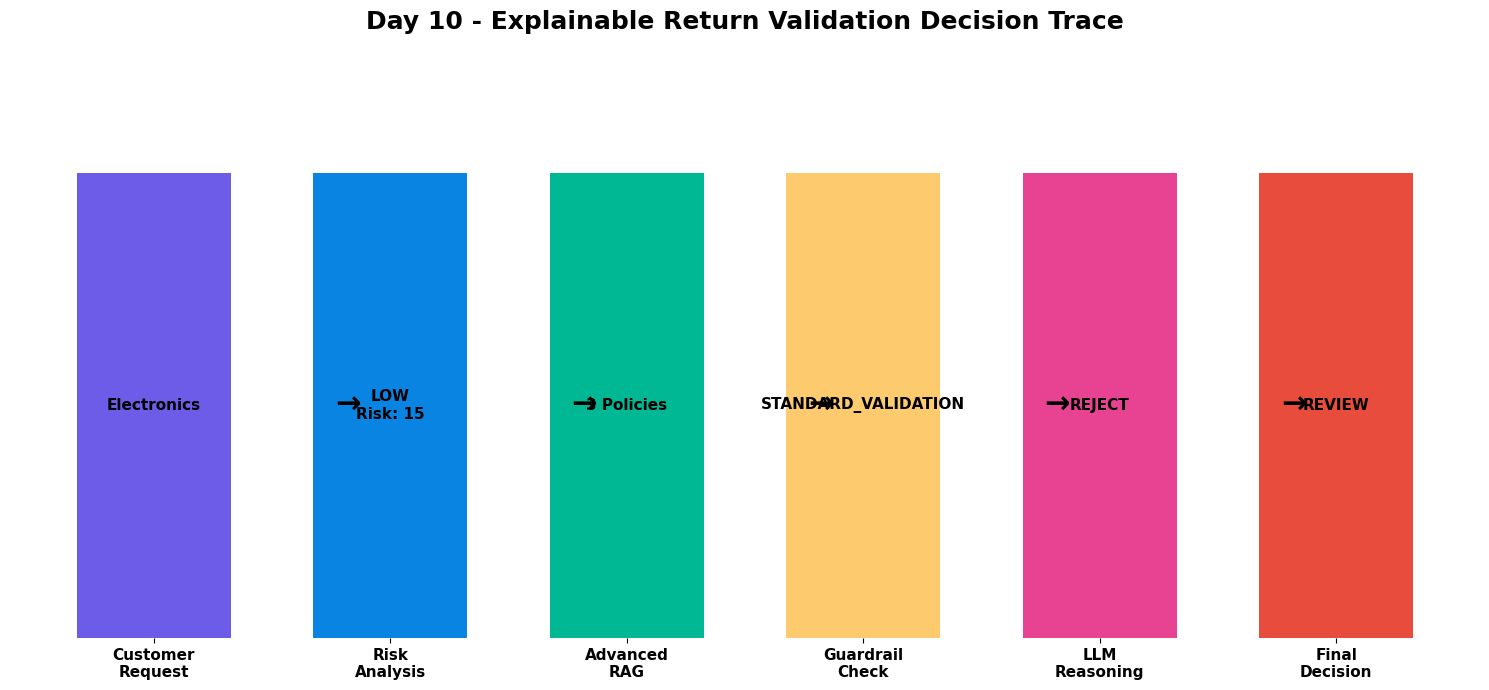

In [25]:
# Day 10 - Step 10
# Decision Trace Visualization

import matplotlib.pyplot as plt

steps = [
    "Customer\nRequest",
    "Risk\nAnalysis",
    "Advanced\nRAG",
    "Guardrail\nCheck",
    "LLM\nReasoning",
    "Final\nDecision"
]

values = [
    "Electronics",
    f"{risk_level}\nRisk: {risk_score}",
    f"{len(retrieved_policies)} Policies",
    guardrail_result["guardrail_status"],
    llm_decision_fixed,
    consistency_result["final_decision"]
]

plt.figure(figsize=(15, 7))

x_positions = range(len(steps))

bars = plt.bar(
    x_positions,
    [1] * len(steps),
    width=0.65,
    color=[
        "#6C5CE7",
        "#0984E3",
        "#00B894",
        "#FDCB6E",
        "#E84393",
        "#E74C3C"
    ]
)

plt.xticks(
    x_positions,
    steps,
    fontsize=11,
    fontweight="bold"
)

plt.yticks([])

plt.title(
    "Day 10 - Explainable Return Validation Decision Trace",
    fontsize=18,
    fontweight="bold",
    pad=20
)

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        0.5,
        str(value),
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold",
        wrap=True
    )

for i in range(len(steps) - 1):
    plt.annotate(
        "→",
        xy=(i + 0.82, 0.5),
        xytext=(i + 1 - 0.18, 0.5),
        ha="center",
        va="center",
        fontsize=22,
        fontweight="bold"
    )

plt.ylim(0, 1.25)
plt.box(False)
plt.tight_layout()
plt.show()

In [26]:
# Day 10 - Step 11
# Multiple Return Validation Test Cases

day10_test_cases = [
    {
        "test_case": "TC01",
        "product_category": "Electronics",
        "days_after_delivery": 5,
        "product_condition": "New",
        "return_reason": "Wrong Product",
        "product_price": 15000,
        "customer_rating": 5,
        "previous_returns": 0,
        "within_policy_period": True
    },
    {
        "test_case": "TC02",
        "product_category": "Electronics",
        "days_after_delivery": 8,
        "product_condition": "Opened",
        "return_reason": "Defective Product",
        "product_price": 25000,
        "customer_rating": 3,
        "previous_returns": 1,
        "within_policy_period": True
    },
    {
        "test_case": "TC03",
        "product_category": "Footwear",
        "days_after_delivery": 18,
        "product_condition": "New",
        "return_reason": "Size Issue",
        "product_price": 3000,
        "customer_rating": 4,
        "previous_returns": 1,
        "within_policy_period": False
    },
    {
        "test_case": "TC04",
        "product_category": "Home Appliances",
        "days_after_delivery": 12,
        "product_condition": "Used",
        "return_reason": "Quality Issue",
        "product_price": 18000,
        "customer_rating": 2,
        "previous_returns": 4,
        "within_policy_period": True
    },
    {
        "test_case": "TC05",
        "product_category": "Beauty",
        "days_after_delivery": 3,
        "product_condition": "New",
        "return_reason": "Changed Mind",
        "product_price": 2000,
        "customer_rating": 5,
        "previous_returns": 0,
        "within_policy_period": True
    }
]

print("✓ 5 Day 10 test cases created")
display(pd.DataFrame(day10_test_cases))

✓ 5 Day 10 test cases created


,test_case,product_category,days_after_delivery,product_condition,return_reason,product_price,customer_rating,previous_returns,within_policy_period
0,TC01,Electronics,5,New,Wrong Product,15000,5,0,True
1,TC02,Electronics,8,Opened,Defective Product,25000,3,1,True
2,TC03,Footwear,18,New,Size Issue,3000,4,1,False
3,TC04,Home Appliances,12,Used,Quality Issue,18000,2,4,True
4,TC05,Beauty,3,New,Changed Mind,2000,5,0,True


In [28]:
# Day 10 - Step 12
# Run Complete Advanced RAG Validation

day10_results = []

for case in day10_test_cases:

    # 1. Risk analysis
    risk_score_case, risk_level_case = calculate_new_return_risk(case)

    # 2. Return context
    return_context_case = create_new_return_context(
        case,
        risk_score_case,
        risk_level_case
    )

    # 3. Advanced RAG
    query_case, retrieved_case = advanced_policy_retrieval(
        case,
        risk_level_case,
        top_k=3
    )

    # 4. Policy context
    policy_context_case = create_policy_context(
        retrieved_case
    )

    # 5. Guardrails
    guardrail_case = check_return_guardrails(
        case,
        risk_level_case
    )

    # 6. Optimized prompt
    prompt_case = create_optimized_day10_prompt(
        return_context_case,
        policy_context_case,
        guardrail_case
    )

    # 7. LLM
    response_case = client.chat.completions.create(
        model=MODEL_NAME,
        messages=[
            {
                "role": "system",
                "content": (
                    "You are an explainable return validation assistant. "
                    "Use only the provided return information, guardrails "
                    "and retrieved policy evidence."
                )
            },
            {
                "role": "user",
                "content": prompt_case
            }
        ],
        max_tokens=500,
        temperature=0.1
    )

    llm_response_case = response_case.choices[0].message.content

    # 8. Extract LLM decision
    llm_decision_case = extract_decision_v2(
        llm_response_case
    )

    # 9. Final consistency guardrail
    consistency_case = apply_decision_consistency_guardrail(
        llm_response_case,
        case,
        risk_level_case,
        guardrail_case
    )

    final_decision_case = consistency_case["final_decision"]

    if final_decision_case == "LLM_DECISION":
        final_decision_case = llm_decision_case

    # 10. Store result
    day10_results.append({
        "test_case": case["test_case"],
        "product_category": case["product_category"],
        "return_reason": case["return_reason"],
        "condition": case["product_condition"],
        "days_after_delivery": case["days_after_delivery"],
        "risk_score": risk_score_case,
        "risk_level": risk_level_case,
        "guardrail_status": guardrail_case["guardrail_status"],
        "retrieved_policies": len(retrieved_case),
        "llm_decision": llm_decision_case,
        "consistency_override": consistency_case["consistency_override"],
        "final_decision": final_decision_case
    })

day10_results_df = pd.DataFrame(day10_results)

print("========== DAY 10 MULTI-CASE VALIDATION ==========")
display(day10_results_df)

========== DAY 10 MULTI-CASE VALIDATION ==========


,test_case,product_category,return_reason,condition,days_after_delivery,risk_score,risk_level,guardrail_status,retrieved_policies,llm_decision,consistency_override,final_decision
0,TC01,Electronics,Wrong Product,New,5,0,LOW,STANDARD_VALIDATION,3,APPROVE,False,APPROVE
1,TC02,Electronics,Defective Product,Opened,8,15,LOW,STANDARD_VALIDATION,3,REJECT,True,REVIEW
2,TC03,Footwear,Size Issue,New,18,40,MEDIUM,MANUAL_REVIEW_REQUIRED,3,REJECT,True,REVIEW
3,TC04,Home Appliances,Quality Issue,Used,12,70,HIGH,MANUAL_REVIEW_REQUIRED,3,REJECT,True,REVIEW
4,TC05,Beauty,Changed Mind,New,3,0,LOW,STANDARD_VALIDATION,3,APPROVE,False,APPROVE


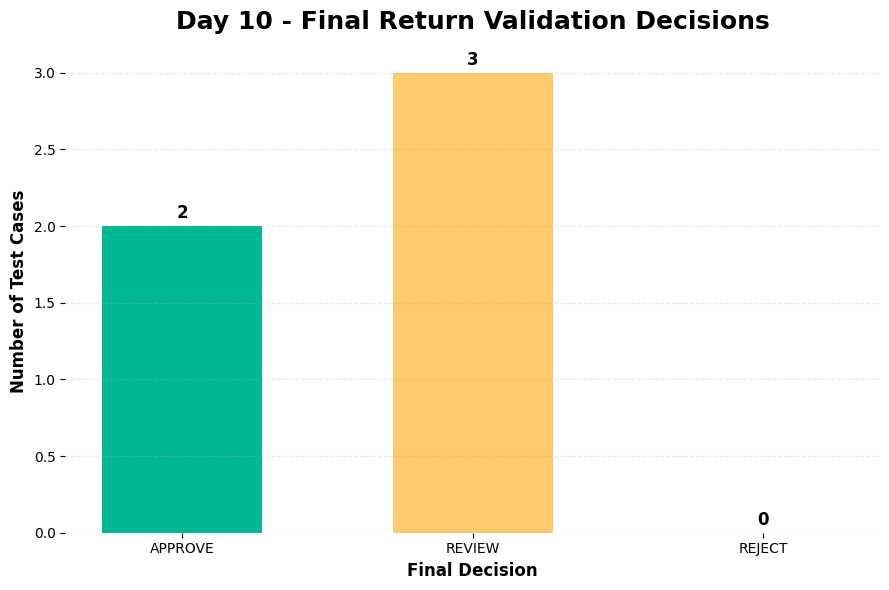

In [29]:
# Day 10 - Step 13
# Final Decision Distribution

decision_counts = (
    day10_results_df["final_decision"]
    .value_counts()
    .reindex(["APPROVE", "REVIEW", "REJECT"], fill_value=0)
)

plt.figure(figsize=(9, 6))

bars = plt.bar(
    decision_counts.index,
    decision_counts.values,
    color=["#00B894", "#FDCB6E", "#E74C3C"],
    width=0.55
)

plt.title(
    "Day 10 - Final Return Validation Decisions",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Final Decision",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Number of Test Cases",
    fontsize=12,
    fontweight="bold"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

for bar, value in zip(bars, decision_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.05,
        str(value),
        ha="center",
        fontweight="bold",
        fontsize=12
    )

plt.box(False)
plt.tight_layout()
plt.show()

In [30]:
# Day 10 - Step 14
# Risk Level vs Final Decision

risk_decision_table = pd.crosstab(
    day10_results_df["risk_level"],
    day10_results_df["final_decision"]
)

risk_decision_table = risk_decision_table.reindex(
    ["LOW", "MEDIUM", "HIGH"],
    fill_value=0
)

for decision in ["APPROVE", "REVIEW", "REJECT"]:
    if decision not in risk_decision_table.columns:
        risk_decision_table[decision] = 0

risk_decision_table = risk_decision_table[
    ["APPROVE", "REVIEW", "REJECT"]
]

print("========== RISK LEVEL VS FINAL DECISION ==========")
display(risk_decision_table)

========== RISK LEVEL VS FINAL DECISION ==========


final_decision,APPROVE,REVIEW,REJECT
risk_level,,,
LOW,2,1,0
MEDIUM,0,1,0
HIGH,0,1,0


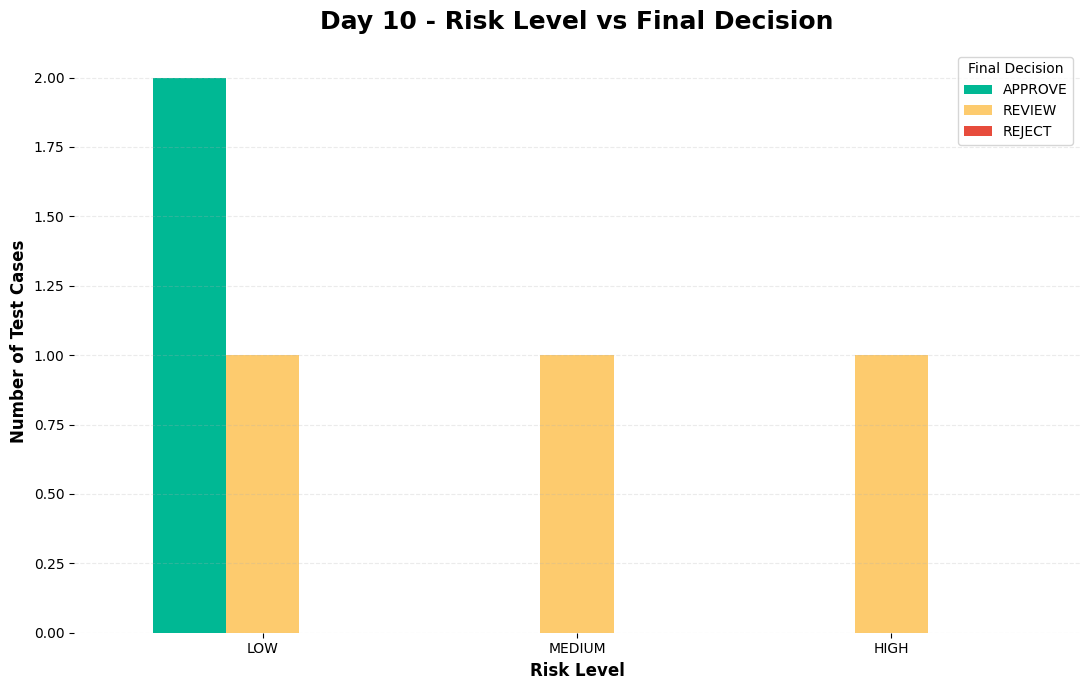

In [31]:
# Day 10 - Step 15
# Risk Level vs Final Decision Chart

risk_decision_table.plot(
    kind="bar",
    figsize=(11, 7),
    color=["#00B894", "#FDCB6E", "#E74C3C"],
    width=0.7
)

plt.title(
    "Day 10 - Risk Level vs Final Decision",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Risk Level",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Number of Test Cases",
    fontsize=12,
    fontweight="bold"
)

plt.xticks(rotation=0)

plt.legend(
    title="Final Decision",
    fontsize=10
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

plt.box(False)
plt.tight_layout()
plt.show()

In [33]:
# Day 10 - Step 16
# Recreate Project Folder and Save Results

import os

# Recreate project folder
project_folder = "DABA_Return_Validation_Project"
os.makedirs(project_folder, exist_ok=True)

print("✓ Project folder ready:", project_folder)

# 1. Save multi-case validation results
day10_results_path = f"{project_folder}/day10_advanced_rag_results.csv"
day10_results_df.to_csv(day10_results_path, index=False)

# 2. Save retrieval analysis
retrieval_analysis_path = f"{project_folder}/day10_retrieval_analysis.csv"
day10_retrieval_df.to_csv(retrieval_analysis_path, index=False)

# 3. Create retrieval evidence
retrieval_evidence = []

for rank, policy in enumerate(retrieved_policies, 1):
    retrieval_evidence.append({
        "rank": rank,
        "policy_id": policy["policy_id"],
        "title": policy["title"],
        "category": policy["category"],
        "distance": policy["distance"],
        "relevance_score": calculate_relevance_score(
            policy["distance"]
        )
    })

day10_retrieval_evidence_df = pd.DataFrame(
    retrieval_evidence
)

retrieval_evidence_path = (
    f"{project_folder}/day10_retrieval_evidence.csv"
)

day10_retrieval_evidence_df.to_csv(
    retrieval_evidence_path,
    index=False
)

# 4. Save final result
day10_final_path = f"{project_folder}/day10_final_result.csv"

day10_final_result.to_csv(
    day10_final_path,
    index=False
)

print()
print("========== DAY 10 FILES SAVED ==========")
print("✓ day10_advanced_rag_results.csv")
print("✓ day10_retrieval_analysis.csv")
print("✓ day10_retrieval_evidence.csv")
print("✓ day10_final_result.csv")
print()
print("🎉 DAY 10 FILES SAVED SUCCESSFULLY!")

✓ Project folder ready: DABA_Return_Validation_Project

========== DAY 10 FILES SAVED ==========
✓ day10_advanced_rag_results.csv
✓ day10_retrieval_analysis.csv
✓ day10_retrieval_evidence.csv
✓ day10_final_result.csv

🎉 DAY 10 FILES SAVED SUCCESSFULLY!


In [34]:
# Day 10 - Final Summary

print("=" * 60)
print("DAY 10 - ADVANCED RAG & PROMPT OPTIMIZATION")
print("=" * 60)

print("\n✓ Advanced RAG retrieval implemented")
print("✓ Semantic policy retrieval using FAISS")
print("✓ Optimized validation prompt created")
print("✓ Decision consistency guardrail added")
print("✓ Decision trace implemented")
print("✓ Multiple return cases tested")
print("✓ Final decision distribution analyzed")
print("✓ Risk level vs final decision analyzed")
print("✓ Day 10 result files saved")

print("\nPROJECT PIPELINE:")
print("""
Customer Return
      ↓
Risk Analysis
      ↓
Advanced RAG
      ↓
Policy Evidence
      ↓
Validation Guardrails
      ↓
Optimized LLM Reasoning
      ↓
Decision Consistency Check
      ↓
Final Decision
      ↓
Explanation + Decision Trace
""")

print("DAY 10 STATUS: COMPLETED ✓")

DAY 10 - ADVANCED RAG & PROMPT OPTIMIZATION

✓ Advanced RAG retrieval implemented
✓ Semantic policy retrieval using FAISS
✓ Optimized validation prompt created
✓ Decision consistency guardrail added
✓ Decision trace implemented
✓ Multiple return cases tested
✓ Final decision distribution analyzed
✓ Risk level vs final decision analyzed
✓ Day 10 result files saved

PROJECT PIPELINE:

Customer Return
      ↓
Risk Analysis
      ↓
Advanced RAG
      ↓
Policy Evidence
      ↓
Validation Guardrails
      ↓
Optimized LLM Reasoning
      ↓
Decision Consistency Check
      ↓
Final Decision
      ↓
Explanation + Decision Trace

DAY 10 STATUS: COMPLETED ✓
